# DES Y3 weak lensing: step-by-step calculation and validation

Follow the calculation in order: **set parameters → evaluate a fiducial cosmology → P(k) → Cℓ → correlation functions → Weyl on/off → χ²**. Each plot has its own cell, using `fig, axes` and explicit bin loops.

The second half contains **13 LCDM cosmologies and likelihood/full-observable timing comparisons between the original DES code, desilike JAX eager, and desilike JAX JIT**. Run from the top initially. To change only a plot, rerun its plotting cell; after changing fiducial parameters, recompute the fiducial prediction first.

The settings are NLA, standard cuts, Legendre transforms, non-Limber clustering, point-mass marginalization, and shear ratios. The reference numerical implementation is unchanged. Bundled data paths follow the package location; use `DES_Y3_REFERENCE` / `DES_Y3_REFERENCE_DATA` to specify the external reference.

Validation thresholds: maximum normalized P(k) error < 5×10⁻⁵; Cℓ/correlation error < 10⁻⁵; |Δχ²| < 10⁻³; residual-model Δχ² < 10⁻⁶. Local previous versions are retained in `bak/` (not included in the GitHub backup).

## 0. Environment and data paths

In [1]:
from pathlib import Path
import sys, os, json, hashlib, platform, time, gc

# Find the checkout from the notebook working directory, or the installed package.
ROOT = next(
    (p for p in (Path.cwd(), *Path.cwd().parents) if (p / "desilike" / "__init__.py").is_file()),
    None,
)
if ROOT is None:
    from importlib.util import find_spec

    spec = find_spec("desilike")
    if spec is None:
        raise RuntimeError(
            "Open this notebook in the desilike checkout, or install desilike first."
        )
    ROOT = Path(spec.origin).resolve().parent.parent
os.chdir(ROOT)
for name in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS"):
    os.environ.setdefault(name, "4")
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/desilike-mpl")
# Use installed dependencies by default; set environment variables explicitly to test other source copies.
for variable in ("DESILIKE_LSSTYPES_PATH", "DESILIKE_COSMOPRIMO_PATH"):
    if variable in os.environ:
        candidate = Path(os.environ[variable]).expanduser().resolve()
        if not candidate.is_dir():
            raise FileNotFoundError(f"{variable} is not a directory: {candidate}")
        sys.path.insert(0, str(candidate))

sys.path.insert(0, str(ROOT))
import cosmoprimo  # Select the test dependency before Installer.setenv().
import numpy as np, pandas as pd, scipy, jax, jax.numpy as jnp
from matplotlib import pyplot as plt
from IPython.display import display
from desilike import Calculator, build
from desilike.parameter import VariableCollection
from desilike.theories.primordial_cosmology import CosmoprimoCosmology
from desilike.theories.weak_lensing.des import DESWeakLensing3x2pt, _parameters, spline
from desilike.likelihoods.weak_lensing import BaseDESY3Likelihood

OUT = ROOT / "diagnostics/weak_lensing_consistency"
OUT.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 16)
print("Python:", sys.executable)
print("cosmoprimo:", cosmoprimo.__file__)
print("JAX:", jax.__version__, "x64:", jax.config.jax_enable_x64, "path:", jax.__file__)
from importlib.metadata import version

VERSIONS = {
    name: version(name)
    for name in ("jax", "jaxlib", "interpax", "equinox", "numpy", "scipy", "camb")
}
print("Versions:", VERSIONS)


Python: /opt/anaconda3/bin/python
cosmoprimo: /Users/illyasviel/.local/lib/python3.12/site-packages/cosmoprimo/__init__.py
JAX: 0.6.2 x64: True path: /Users/illyasviel/.local/lib/python3.12/site-packages/jax/__init__.py
Versions: {'jax': '0.6.2', 'jaxlib': '0.6.2', 'interpax': '0.3.15', 'equinox': '0.13.8', 'numpy': '1.26.4', 'scipy': '1.14.0', 'camb': '1.5.8'}


### Reference interface setup

These cells load the original reference implementation and extract its outputs. Physical parameters are set in the next section.

In [2]:
from pathlib import Path

import ast, sys, types, hashlib, os

import numpy as np

import pandas as pd

import camb

from getdist import IniFile

REFERENCE = (
    Path(
        os.environ.get(
            "DES_Y3_REFERENCE", str(ROOT.parent / "des-y3" / "des-y3" / "des_y3" / "des.py")
        )
    )
    .expanduser()
    .resolve()
)

DATA = (
    Path(os.environ.get("DES_Y3_REFERENCE_DATA", str(REFERENCE.parent.parent / "des3")))
    .expanduser()
    .resolve()
)

SOURCE = REFERENCE.read_text()

tree = ast.parse(SOURCE, filename=str(REFERENCE))

tree.body = [
    n
    for n in tree.body
    if not (isinstance(n, ast.Import) and any(a.name.startswith("fastpt") for a in n.names))
]

reference_module = types.ModuleType("des_y3_reference_nla")

reference_module.__file__ = str(REFERENCE)

exec(compile(tree, str(REFERENCE), "exec"), reference_module.__dict__)

reference_module.numba = None  # use the source's original NumPy path

DES = reference_module.DES


#### Create the original NumPy/SciPy likelihood

In [3]:
def make_reference(weyl=False, sr=True):
    ref = object.__new__(DES)
    for name, value in dict(
        acc=1.0,
        l_max=40000,
        use_hankel=False,
        use_legendre=True,
        binned_bessels=False,
        use_Weyl=weyl,
        use_TATT=False,
        use_sr=sr,
    ).items():
        setattr(ref, name, value)
    ref.init_params(IniFile(str(DATA / "DES_3YR_final.dataset")))
    ref.initialize_postload()
    return ref


#### Supply independent CAMB results to the reference likelihood

In [4]:
class CAMBProvider:
    def __init__(self, results):
        self.results = results
        self.pk = {}
        for nl, pair in [
            (False, ("delta_tot", "delta_tot")),
            (True, ("delta_tot", "delta_tot")),
            (False, ("Weyl", "Weyl")),
            (False, ("delta_tot", "Weyl")),
        ]:
            from cobaya.theories.cosmo.boltzmannbase import PowerSpectrumInterpolator

            k, z, pk = results.get_linear_matter_power_spectrum(
                var1=pair[0],
                var2=pair[1],
                hubble_units=False,
                k_hunit=False,
                have_power_spectra=True,
                nonlinear=nl,
            )
            sign = -1 if np.all(pk < 0) else 1
            self.pk[nl, pair] = PowerSpectrumInterpolator(
                z, k, np.log(sign * pk), logP=True, logsign=sign, extrap_kmax=8000.0
            )

    def get_param(self, name):
        if name == "H0":
            return self.results.Params.H0
        if name == "omegam":
            return sum(self.results.get_Omega(x) for x in ["baryon", "cdm", "nu"])
        raise KeyError(name)

    def get_comoving_radial_distance(self, z):
        return self.results.comoving_radial_distance(z)

    def get_Hubble(self, z, units="1/Mpc"):
        return self.results.h_of_z(z)

    def get_Pk_interpolator(self, pair, nonlinear=False, **kwargs):
        return self.pk[nonlinear, tuple(pair)]


#### Extract reference Cℓ, correlation functions, and χ²

In [5]:
def evaluate_reference(ref, provider, nuisance):
    ref.provider = provider
    # Observe original function locals only: do not rewrite any numerical formula.
    spectra = {name: {} for name in ["xip", "xim", "gammat", "wtheta"]}
    record_lines = {}
    for i, line in enumerate(SOURCE.splitlines(), 1):
        for short, name in [("p", "xip"), ("m", "xim"), ("t", "gammat"), ("w", "wtheta")]:
            if f"corrs_th_{short}[f1, f2] = np.dot(cl," in line:
                record_lines[i] = name
    captured = {}
    code = DES.get_theory.__code__

    def trace(frame, event, arg):
        if frame.f_code is not code:
            return None
        if event == "line" and frame.f_lineno in record_lines:
            loc = frame.f_locals
            spectra[record_lines[frame.f_lineno]][int(loc["f1"]), int(loc["f2"])] = np.array(
                loc["cl"], copy=True
            )
        if event == "return":
            captured["corrs"] = arg
            for name in ["D_growth", "nz_lens", "nz_source", "qs", "qsw", "qgal"]:
                captured[name] = np.array(frame.f_locals[name], copy=True)
        return trace

    old = sys.gettrace()
    try:
        sys.settrace(trace)
        logp = ref.logp(**nuisance)
    finally:
        sys.settrace(old)
    captured.update(
        logp=float(logp),
        chi2=-2 * float(logp),
        cls=spectra,
        precision=ref.covinv.copy(),
        sigma_crit_inv=ref.sigma_crit_inv.copy(),
    )
    captured["vector"] = ref.make_vector(captured["corrs"])
    return captured


#### Error definitions

In [6]:
def relative_metrics(a, b):
    a, b = np.asarray(a), np.asarray(b)
    scale = max(float(np.max(np.abs(b))), 1e-300)
    valid = np.abs(b) > scale * 1e-6
    return dict(
        max_scaled=float(np.max(np.abs(a - b)) / scale),
        rms_scaled=float(np.linalg.norm(a - b) / max(np.linalg.norm(b), 1e-300)),
        max_relative=float(np.max(np.abs((a - b)[valid] / b[valid]))) if valid.any() else 0.0,
        finite=bool(np.isfinite(a).all() and np.isfinite(b).all()),
    )


In [7]:
print("Reference SHA256:", hashlib.sha256(REFERENCE.read_bytes()).hexdigest())

print("CAMB:", camb.__version__)

data_checks = []

for path in sorted(DATA.glob("DES_3YR_final*.dat")):
    from desilike.theories.weak_lensing.data import resolve_data_dir

    bundled = resolve_data_dir() / path.name
    equal = np.array_equal(np.loadtxt(path, dtype=str), np.loadtxt(bundled, dtype=str))
    data_checks.append({"file": path.name, "identical": equal})

display(pd.DataFrame(data_checks))

assert all(row["identical"] for row in data_checks)

ref_no, ref_yes = make_reference(False), make_reference(True)

a = [item[1] for item in ref_no.used_items if item[0] == 2]

print("Original reference bin type:", type(a[0]), "Shape returned by the list comparison:", np.shape(a == a[0]))


Reference SHA256: d997f6a7d49ac677fd8b687e362e18e0e241c56f807f31002a7836659a9efeeb
CAMB: 1.5.8


,file,identical
0,DES_3YR_final_aggressive_cut.dat,True
1,DES_3YR_final_cov.dat,True
2,DES_3YR_final_gammat.dat,True
3,DES_3YR_final_nz_lens.dat,True
4,DES_3YR_final_nz_source.dat,True
5,DES_3YR_final_soft_cut.dat,True
6,DES_3YR_final_standard_cut.dat,True
7,DES_3YR_final_theta_bins.dat,True
8,DES_3YR_final_wtheta.dat,True
9,DES_3YR_final_xim.dat,True


Original reference bin type: <class 'numpy.int64'> Shape returned by the list comparison: (105,)


## 1. Cosmological and nuisance parameters

Start here to change parameters. The batch scan varies only the six LCDM parameters; other physical settings remain fixed.

In [8]:
BASE = dict(h=0.6736, omega_b=0.02237, omega_cdm=0.12, logA=3.036394, n_s=0.9649, tau_reio=0.0544)

SCAN = dict(
    h=(0.64, 0.71),
    omega_b=(0.0218, 0.0230),
    omega_cdm=(0.112, 0.128),
    logA=(2.96, 3.12),
    n_s=(0.94, 0.99),
    tau_reio=(0.04, 0.07),
)

CASES = [("fiducial", BASE.copy())]

for name, values in SCAN.items():
    for label, value in zip(("low", "high"), values):
        CASES.append((f"{name}_{label}", {**BASE, name: value}))

case_table = pd.DataFrame([dict(case=name, **params) for name, params in CASES])

display(case_table)

FIXED = dict(m_ncdm=0.06, N_eff=3.046, Omega_k=0.0, w0_fld=-1.0, wa_fld=0.0)

print("Fixed cosmological parameters:", FIXED)

NUISANCE = {p.name: float(p.value) for p in _parameters() if p.name.startswith("DES_")}

print("Fixed nuisance parameters:", NUISANCE)

PRECISION = {
    "calc_params": {"non_linear": "takahashi", "kmax_pk": 150.0, "z_pk": np.linspace(0.0, 3.0, 100)}
}

FD_STEPS = dict(h=1e-4, omega_b=1e-5, omega_cdm=1e-4, logA=1e-4, n_s=1e-4, tau_reio=1e-4)


,case,h,omega_b,omega_cdm,logA,n_s,tau_reio
0,fiducial,0.6736,0.02237,0.120,3.036394,0.9649,0.0544
1,h_low,0.6400,0.02237,0.120,3.036394,0.9649,0.0544
2,h_high,0.7100,0.02237,0.120,3.036394,0.9649,0.0544
3,omega_b_low,0.6736,0.02180,0.120,3.036394,0.9649,0.0544
4,omega_b_high,0.6736,0.02300,0.120,3.036394,0.9649,0.0544
5,omega_cdm_low,0.6736,0.02237,0.112,3.036394,0.9649,0.0544
6,omega_cdm_high,0.6736,0.02237,0.128,3.036394,0.9649,0.0544
7,logA_low,0.6736,0.02237,0.120,2.960000,0.9649,0.0544
8,logA_high,0.6736,0.02237,0.120,3.120000,0.9649,0.0544
9,n_s_low,0.6736,0.02237,0.120,3.036394,0.9400,0.0544


Fixed cosmological parameters: {'m_ncdm': 0.06, 'N_eff': 3.046, 'Omega_k': 0.0, 'w0_fld': -1.0, 'wa_fld': 0.0}
Fixed nuisance parameters: {'DES_DzL1': -0.035, 'DES_DzL2': -0.005, 'DES_DzL3': -0.007, 'DES_DzL4': 0.0, 'DES_DzL5': 0.0, 'DES_DzL6': 0.0, 'DES_szL1': 1.0, 'DES_szL2': 1.0, 'DES_szL3': 1.0, 'DES_szL4': 1.0, 'DES_szL5': 1.0, 'DES_szL6': 1.0, 'DES_b1': 1.5, 'DES_b2': 1.8, 'DES_b3': 1.8, 'DES_b4': 1.9, 'DES_b5': 2.3, 'DES_b6': 2.3, 'DES_DzS1': 0.0, 'DES_DzS2': 0.0, 'DES_DzS3': 0.0, 'DES_DzS4': 0.0, 'DES_m1': -0.006, 'DES_m2': -0.02, 'DES_m3': -0.024, 'DES_m4': -0.037, 'DES_AIA1': 0.7, 'DES_alphaIA1': -1.7, 'DES_z0IA': 0.62}


#### Configure CAMB for desilike

In [9]:
def make_cosmo(values):
    pars = VariableCollection(
        [
            p.clone(value=values.get(p.name, p.value), fd={"eps": FD_STEPS.get(p.name, 1e-4)})
            for p in _parameters()
            if not p.name.startswith("DES_")
        ]
    )
    return CosmoprimoCosmology(engine="camb", fiducial="DESI", params=pars, precision=PRECISION)


#### Evaluate Weyl off and on with a shared cosmology node

In [10]:
class WeylPair(Calculator):
    def __init__(self, cosmo):
        self.cosmo = cosmo
        self.no = BaseDESY3Likelihood(
            theory=DESWeakLensing3x2pt(cosmo=cosmo, Weyl=False), use_sr=True
        )
        self.yes = BaseDESY3Likelihood(
            theory=DESWeakLensing3x2pt(cosmo=cosmo, Weyl=True), use_sr=True
        )

    def __post_init__(self, *args, **kwargs):
        pass

    def __call__(self):
        self.result = {}
        for mode, like in [("density", self.no), ("weyl", self.yes)]:
            th = like.theory
            self.result[mode] = {name: getattr(th, name) for name in th._outputs}
            self.result[mode].update(
                chi2=-2 * like.logpdf,
                chi2_3x2pt=like.chi2_3x2pt,
                chi2_sr=like.chi2_sr,
                vector=like.flattheory,
                precision=like.precision,
                sigma_crit_inv=like.sigma_crit_inv,
            )
        return self.result

    def tree_flatten(self):
        return [self.result], None

    @classmethod
    def tree_unflatten(cls, aux, children):
        obj = object.__new__(cls)
        obj.result = children[0]
        return obj


In [11]:
TYPES = ["xip", "xim", "gammat", "wtheta"]


#### Error statistics for batch validation

In [12]:
def compare_predictions(case, mode, prediction, ref, target):
    angular, correlation = [], []
    for index, name in enumerate(TYPES):
        pairs = ref.bin_pairs[index]
        a = np.array([prediction["cl_" + name][i, j] for i, j in pairs])
        b = np.array([target["cls"][name][int(i), int(j)] for i, j in pairs])
        angular.append(dict(case=case, mode=mode, observable=name, **relative_metrics(a, b)))
        a = np.array([prediction[name][i, j] for i, j in pairs])
        b = np.array([target["corrs"][index][i, j] for i, j in pairs])
        correlation.append(dict(case=case, mode=mode, observable=name, **relative_metrics(a, b)))
    residual = np.asarray(prediction["vector"]) - target["vector"]
    ref_3x2 = ref.chi_squared(target["corrs"])
    likelihood = dict(
        case=case,
        mode=mode,
        chi2_des=float(prediction["chi2"]),
        chi2_ref=target["chi2"],
        delta_chi2=float(prediction["chi2"]) - target["chi2"],
        des_3x2=float(prediction["chi2_3x2pt"]),
        ref_3x2=float(ref_3x2),
        des_sr=float(prediction["chi2_sr"]),
        ref_sr=target["chi2"] - float(ref_3x2),
        model_delta_chi2=float(residual @ target["precision"] @ residual),
        precision_relative_norm=float(
            np.linalg.norm(np.asarray(prediction["precision"]) - target["precision"])
            / np.linalg.norm(target["precision"])
        ),
        sigma_crit_relative_norm=relative_metrics(
            prediction["sigma_crit_inv"], target["sigma_crit_inv"]
        )["rms_scaled"],
    )
    return angular, correlation, likelihood


## 2. Evaluate one fiducial cosmology

Keep these variables in the notebook for direct array inspection. This section evaluates only `BASE`; the 13-cosmology scan comes later.

In [13]:
case = "fiducial"
values = BASE.copy()
power_rows, angular_rows, correlation_rows, chi2_rows, switch_rows = [], [], [], [], []
camb_template = None


### 2.1 desilike: both Weyl modes

In [14]:
pair = WeylPair(make_cosmo(values))
pipe = build(pair)
predictions = jax.tree_util.tree_map(np.asarray, pair.result)  # build has evaluated the complete graph at the current parameters.
if camb_template is None:
    camb_template = pair.cosmo._cosmo.engine._camb_params.copy()

# Inspect theory-object outputs directly, as in the original notebook.
twopt = pair.no.theory
twopt_weyl = pair.yes.theory
ell = np.asarray(twopt.ell)
theta_bins = ref_no.theta_bins


### 2.2 Independent CAMB: recompute the same cosmology

Do not reuse desilike’s CAMBdata. Use the validated matching settings for BBN-derived YHe and the physical extrapolation limit.

In [15]:
cp = camb_template.copy()
cp.H0 = 100 * values["h"]
cp.ombh2 = values["omega_b"]
cp.omch2 = values["omega_cdm"]
cp.InitPower.set_params(As=np.exp(values["logA"]) * 1e-10, ns=values["n_s"])
cp.Reion.optical_depth = values["tau_reio"]
cp.Transfer.kmax = 150 * values["h"]
# YHe is a BBN-derived quantity and must follow omega_b, not remain at the template value.
cp.YHe = camb.bbn.get_predictor().Y_He(
    values["omega_b"] * (camb.constants.COBE_CMBTemp / cp.TCMB) ** 3,
    FIXED["N_eff"] - camb.constants.default_nnu,
)
results = camb.get_results(cp)  # Independent calculation; do not reuse cosmoprimo CAMBdata.
provider = CAMBProvider(results)


### 2.3 Extract four power spectra

Each `power_curves` entry is `(desilike, CAMB)`; k is in physical units of 1/Mpc.

In [16]:
kernels = pair.yes.theory.kernels
iz = np.array([0, 1, 50, 100, 200, len(kernels.z_pk) - 1])
redshifts = kernels.z_pk[iz]
physical_k = np.geomspace(1e-4, 7999.0, 501)
power_curves = {}
for label, of, nl, camb_pair in [
    ("matter_linear", "delta_m", False, ("delta_tot", "delta_tot")),
    ("matter_nonlinear", "delta_m", True, ("delta_tot", "delta_tot")),
    ("weyl_linear", "phi_plus_psi", False, ("Weyl", "Weyl")),
    ("matter_weyl", ("delta_m", "phi_plus_psi"), False, ("delta_tot", "Weyl")),
]:
    table = kernels.spectrum(of, nl)[iz]
    power = (
        np.asarray(
            jnp.exp(spline(jnp.log(physical_k / values["h"]), jnp.log(kernels.k), jnp.log(table).T))
        ).T
        / values["h"] ** 3
    )
    if label == "weyl_linear":
        power = power * physical_k**4 / 4
    if label == "matter_weyl":
        power = -power * physical_k**2 / 2
    target = provider.pk[nl, camb_pair].P(redshifts, physical_k)
    for region, mask in [("sampled", physical_k <= 100), ("extrapolated", physical_k > 100)]:
        power_rows.append(
            dict(
                case=case,
                spectrum=label,
                region=region,
                **relative_metrics(power[:, mask], target[:, mask])
            )
        )
    power_curves[label] = (power, target)


### 2.4 Original reference: Cℓ, correlation functions, and χ²

In [17]:
references = {}
for mode, ref in [("density", ref_no), ("weyl", ref_yes)]:
    target = evaluate_reference(ref, provider, NUISANCE)
    references[mode] = target
    aa, xx, cc = compare_predictions(case, mode, predictions[mode], ref, target)
    angular_rows.extend(aa)
    correlation_rows.extend(xx)
    chi2_rows.append(cc)


### 2.5 Save fiducial results and compare the Weyl response

In [18]:
for index, name in enumerate(TYPES):
    pairs = ref_no.bin_pairs[index]
    for space, key in [("Cl", "cl_" + name), ("xi", name)]:
        no = np.array([predictions["density"][key][i, j] for i, j in pairs])
        yes = np.array([predictions["weyl"][key][i, j] for i, j in pairs])
        if space == "Cl":
            rn = np.array([references["density"]["cls"][name][int(i), int(j)] for i, j in pairs])
            ry = np.array([references["weyl"]["cls"][name][int(i), int(j)] for i, j in pairs])
        else:
            rn = np.array([references["density"]["corrs"][index][i, j] for i, j in pairs])
            ry = np.array([references["weyl"]["corrs"][index][i, j] for i, j in pairs])
        switch_rows.append(
            dict(
                case=case,
                space=space,
                observable=name,
                des_switch=relative_metrics(yes, no)["max_scaled"],
                ref_switch=relative_metrics(ry, rn)["max_scaled"],
                switch_residual=float(np.max(np.abs((yes - no) - (ry - rn))) / np.max(np.abs(rn))),
            )
        )
if case == "fiducial":
    fiducial = dict(
        predictions=predictions,
        references=references,
        power=power_curves,
        k=physical_k,
        z=redshifts,
    )


In [19]:
power_df = pd.DataFrame(power_rows)
angular_df = pd.DataFrame(angular_rows)
correlation_df = pd.DataFrame(correlation_rows)
chi2_df = pd.DataFrame(chi2_rows)
switch_df = pd.DataFrame(switch_rows)
display(
    power_df.groupby(["spectrum", "region"])[["max_scaled", "rms_scaled", "max_relative"]].max()
)
assert power_df.finite.all()
assert power_df.max_scaled.max() < 5e-5


max_scaled    rms_scaled  max_relative
spectrum         region                                                
matter_linear    extrapolated  7.078800e-11  3.046342e-11  1.655585e-09
                 sampled       8.999243e-09  1.617888e-09  1.258728e-07
matter_nonlinear extrapolated  4.645908e-11  2.271461e-11  2.067176e-09
                 sampled       9.236643e-09  1.671447e-09  1.118064e-07
matter_weyl      extrapolated  7.079043e-11  3.060126e-11  5.875246e-09
                 sampled       8.999764e-09  1.678244e-09  1.244665e-07
weyl_linear      extrapolated  7.469235e-11  3.105412e-11  7.643995e-09
                 sampled       9.035798e-09  1.742746e-09  1.240712e-07

In [20]:
# Plot only pairs that enter the likelihood after scale cuts.
PLOT_PAIRS = {
    name: sorted({(int(i), int(j)) for typ, i, j, _ in ref_no.used_items if typ == index})
    for index, name in enumerate(TYPES)
}
print("Plotted bin pairs:", {name: len(pairs) for name, pairs in PLOT_PAIRS.items()})


Plotted bin pairs: {'xip': 10, 'xim': 2, 'gammat': 16, 'wtheta': 4}


## 3. P(k): prediction and residual panels for each spectrum

### matter_linear

/var/folders/f6/3xg83pv93rd82_jd1m8pv17r0000gn/T/ipykernel_16263/3129911166.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


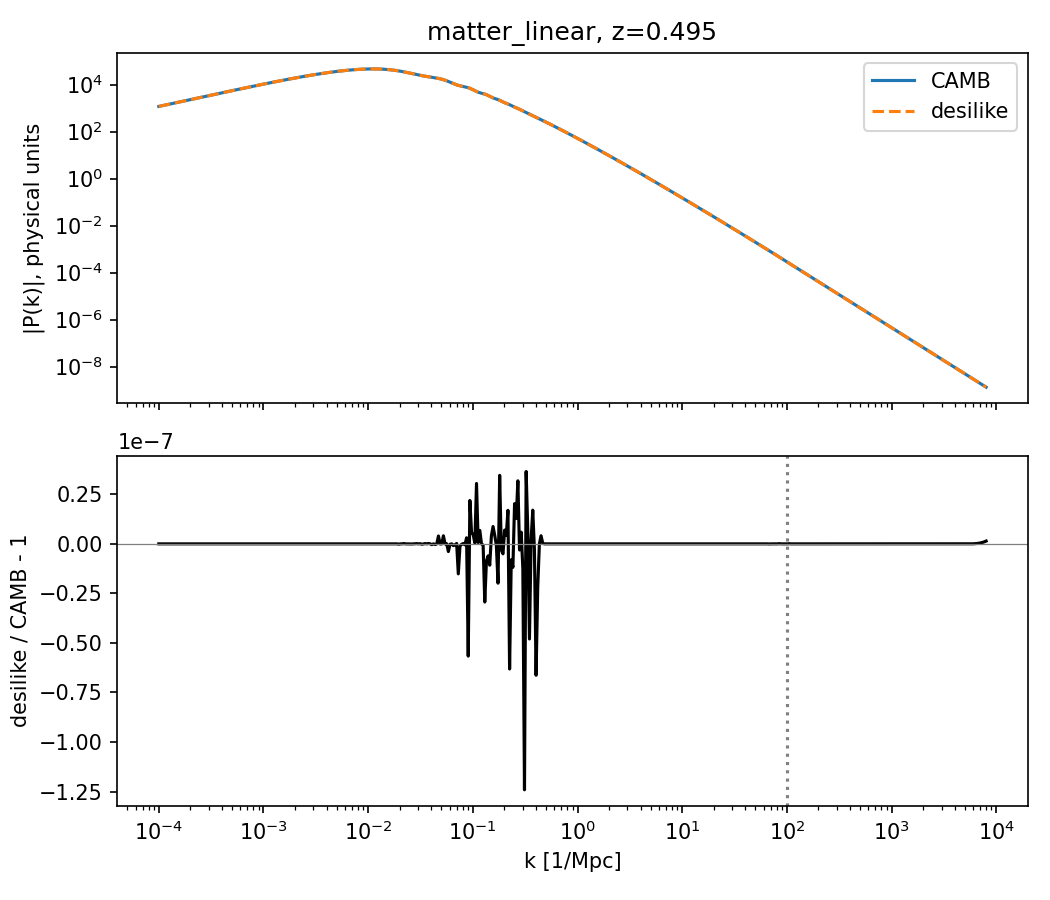

In [21]:
k = fiducial["k"]
iz = 2  # Change this to select another computed redshift.
P_desilike, P_camb = fiducial["power"]["matter_linear"]
fig, axes = plt.subplots(2, 1, figsize=(7, 6), sharex=True)
axes[0].loglog(k, np.abs(P_camb[iz]), label="CAMB")
axes[0].loglog(k, np.abs(P_desilike[iz]), "--", label="desilike")
axes[0].set_ylabel("|P(k)|, physical units")
axes[0].set_title("matter_linear" + f", z={fiducial['z'][iz]:.3f}")
axes[0].legend()
axes[1].semilogx(k, P_desilike[iz] / P_camb[iz] - 1, color="black")
axes[1].axhline(0, color="gray", lw=0.6)
axes[1].axvline(100, color="gray", ls=":")
axes[1].set_xlabel("k [1/Mpc]")
axes[1].set_ylabel("desilike / CAMB - 1")
fig.tight_layout()
fig.savefig(OUT / "power_matter_linear.png", dpi=150)
plt.show()
plt.close(fig)


### matter_nonlinear

/var/folders/f6/3xg83pv93rd82_jd1m8pv17r0000gn/T/ipykernel_16263/242233043.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


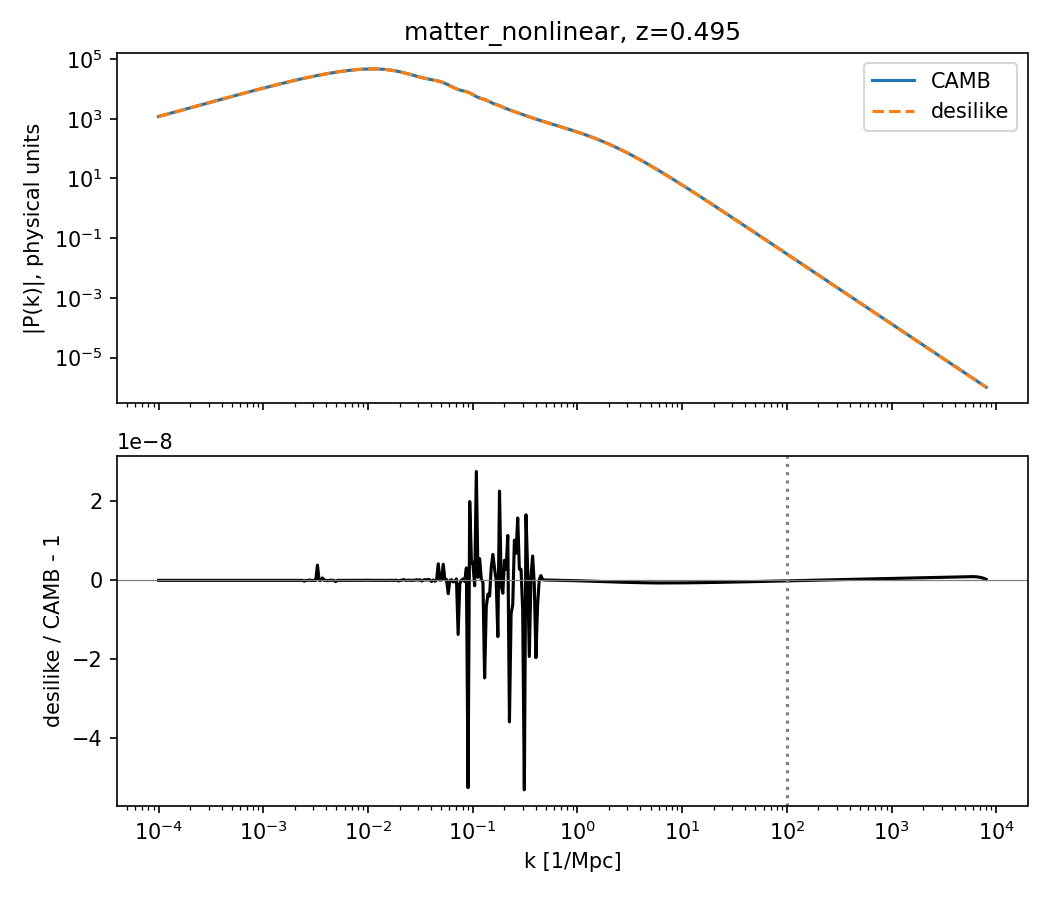

In [22]:
k = fiducial["k"]
iz = 2  # Change this to select another computed redshift.
P_desilike, P_camb = fiducial["power"]["matter_nonlinear"]
fig, axes = plt.subplots(2, 1, figsize=(7, 6), sharex=True)
axes[0].loglog(k, np.abs(P_camb[iz]), label="CAMB")
axes[0].loglog(k, np.abs(P_desilike[iz]), "--", label="desilike")
axes[0].set_ylabel("|P(k)|, physical units")
axes[0].set_title("matter_nonlinear" + f", z={fiducial['z'][iz]:.3f}")
axes[0].legend()
axes[1].semilogx(k, P_desilike[iz] / P_camb[iz] - 1, color="black")
axes[1].axhline(0, color="gray", lw=0.6)
axes[1].axvline(100, color="gray", ls=":")
axes[1].set_xlabel("k [1/Mpc]")
axes[1].set_ylabel("desilike / CAMB - 1")
fig.tight_layout()
fig.savefig(OUT / "power_matter_nonlinear.png", dpi=150)
plt.show()
plt.close(fig)


### weyl_linear

/var/folders/f6/3xg83pv93rd82_jd1m8pv17r0000gn/T/ipykernel_16263/791998520.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


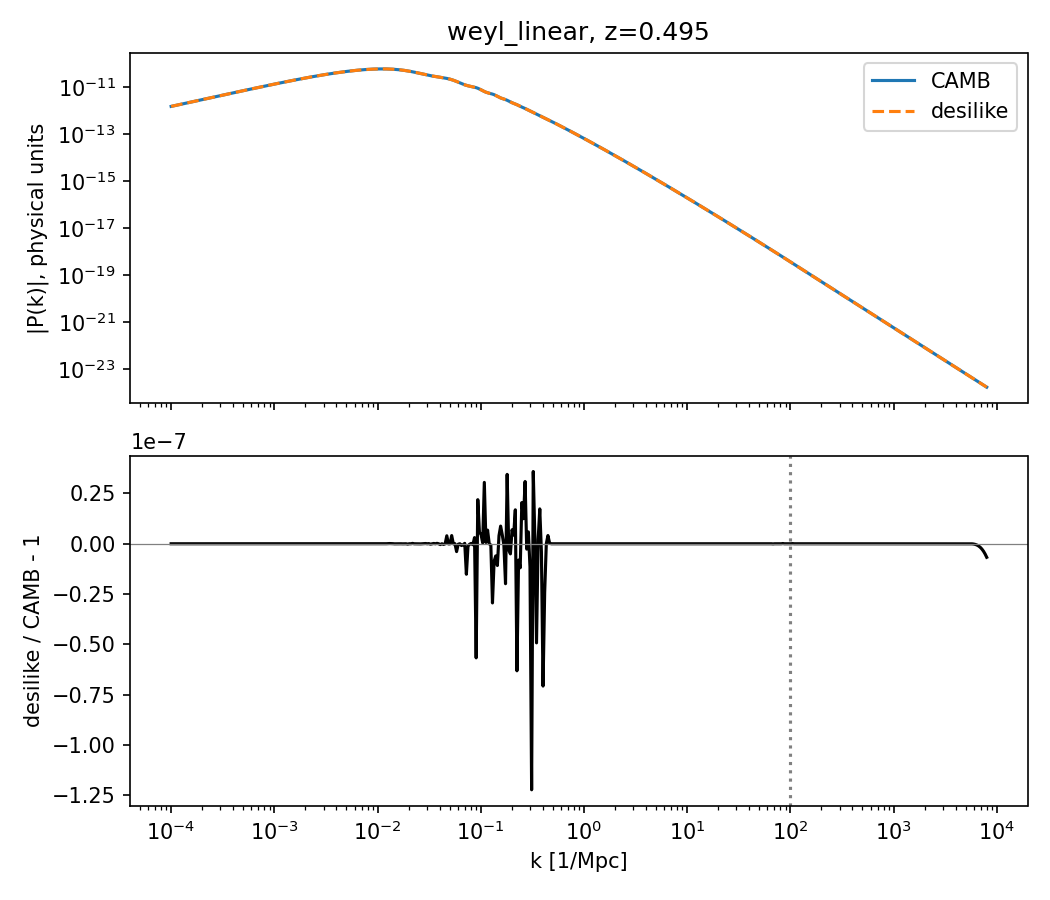

In [23]:
k = fiducial["k"]
iz = 2  # Change this to select another computed redshift.
P_desilike, P_camb = fiducial["power"]["weyl_linear"]
fig, axes = plt.subplots(2, 1, figsize=(7, 6), sharex=True)
axes[0].loglog(k, np.abs(P_camb[iz]), label="CAMB")
axes[0].loglog(k, np.abs(P_desilike[iz]), "--", label="desilike")
axes[0].set_ylabel("|P(k)|, physical units")
axes[0].set_title("weyl_linear" + f", z={fiducial['z'][iz]:.3f}")
axes[0].legend()
axes[1].semilogx(k, P_desilike[iz] / P_camb[iz] - 1, color="black")
axes[1].axhline(0, color="gray", lw=0.6)
axes[1].axvline(100, color="gray", ls=":")
axes[1].set_xlabel("k [1/Mpc]")
axes[1].set_ylabel("desilike / CAMB - 1")
fig.tight_layout()
fig.savefig(OUT / "power_weyl_linear.png", dpi=150)
plt.show()
plt.close(fig)


### matter_weyl

/var/folders/f6/3xg83pv93rd82_jd1m8pv17r0000gn/T/ipykernel_16263/3963564441.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


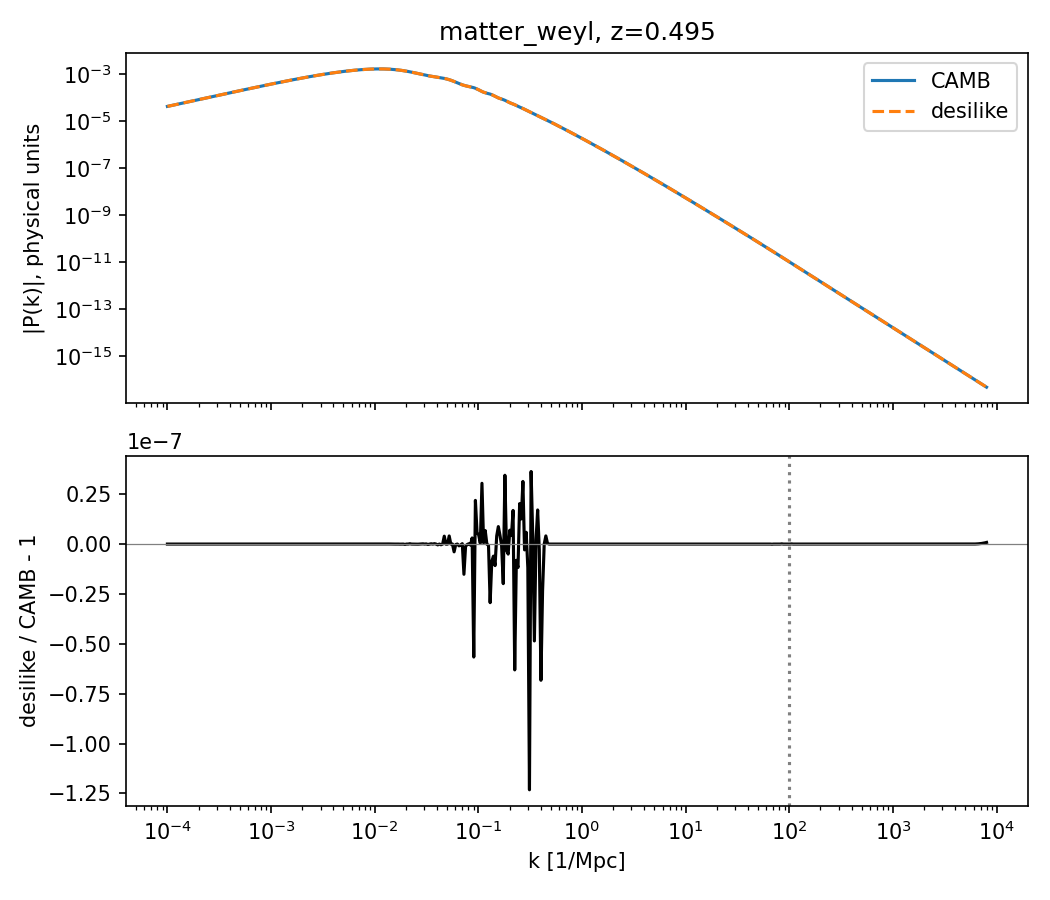

In [24]:
k = fiducial["k"]
iz = 2  # Change this to select another computed redshift.
P_desilike, P_camb = fiducial["power"]["matter_weyl"]
fig, axes = plt.subplots(2, 1, figsize=(7, 6), sharex=True)
axes[0].loglog(k, np.abs(P_camb[iz]), label="CAMB")
axes[0].loglog(k, np.abs(P_desilike[iz]), "--", label="desilike")
axes[0].set_ylabel("|P(k)|, physical units")
axes[0].set_title("matter_weyl" + f", z={fiducial['z'][iz]:.3f}")
axes[0].legend()
axes[1].semilogx(k, P_desilike[iz] / P_camb[iz] - 1, color="black")
axes[1].axhline(0, color="gray", lw=0.6)
axes[1].axvline(100, color="gray", ls=":")
axes[1].set_xlabel("k [1/Mpc]")
axes[1].set_ylabel("desilike / CAMB - 1")
fig.tight_layout()
fig.savefig(OUT / "power_matter_weyl.png", dpi=150)
plt.show()
plt.close(fig)


## 4. Angular power spectra Cℓ

Each panel pair corresponds to one bin pair: predictions above and pointwise relative differences below. The plotting code appears immediately above its output.

### wtheta — Cl — Weyl off:desilike / reference

/var/folders/f6/3xg83pv93rd82_jd1m8pv17r0000gn/T/ipykernel_16263/1504010615.py:41: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


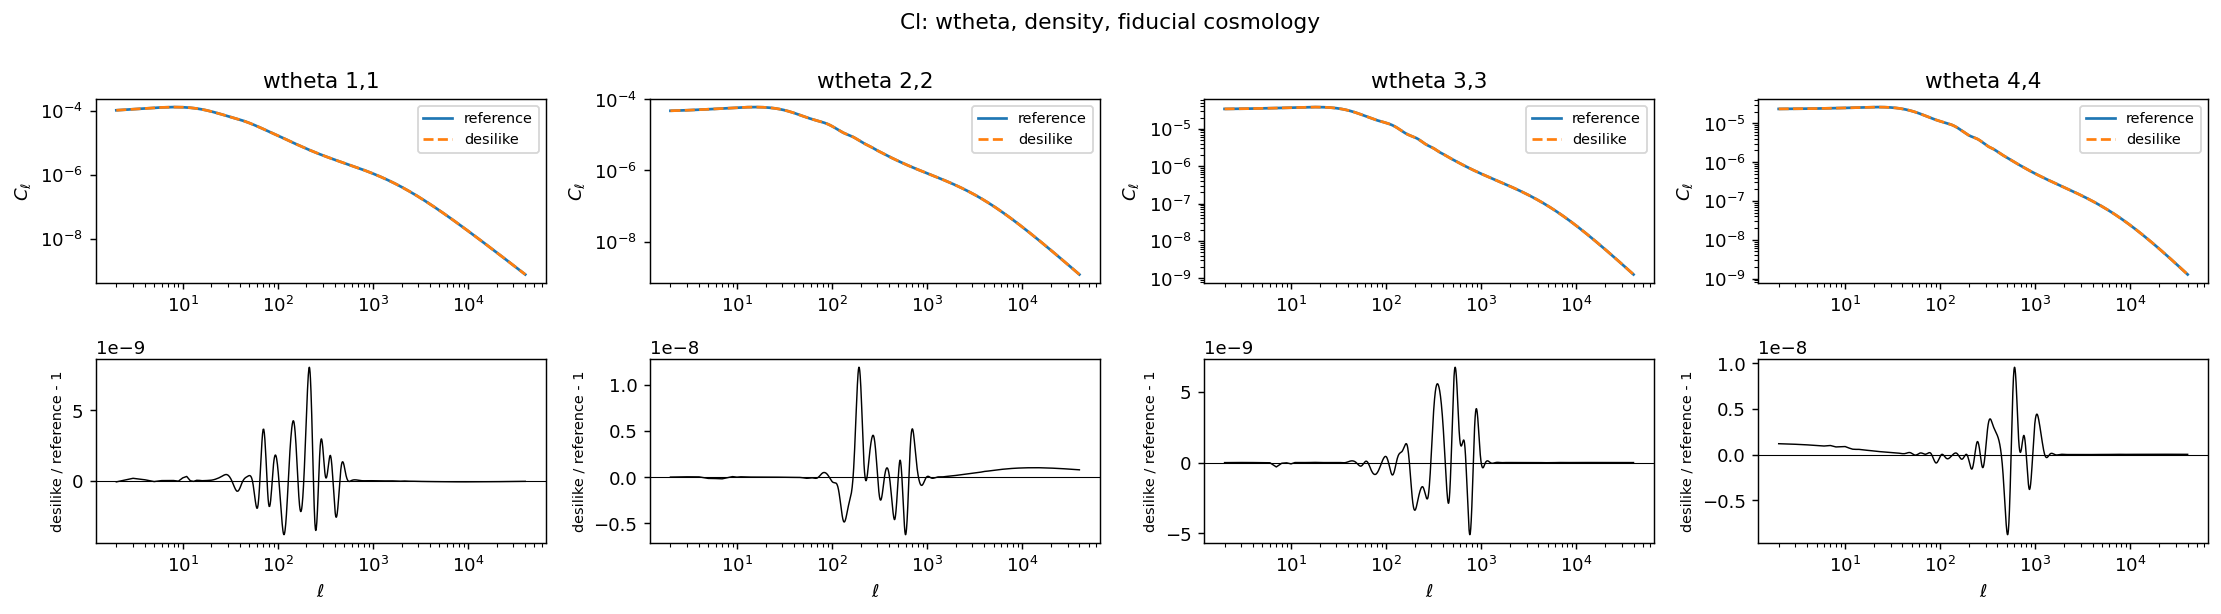

In [25]:
x = np.asarray(fiducial["predictions"]["density"]["ell"])
first = fiducial["predictions"]["density"]["cl_wtheta"]
second = fiducial["references"]["density"]["cls"]["wtheta"]
pairs = PLOT_PAIRS["wtheta"]
fig, axes = plt.subplots(2, 4, figsize=(17.2, 4.7), squeeze=False)
for ax in axes.flat:
    ax.set_visible(False)

for count, (i, j) in enumerate(pairs):
    row, col = (0, count)
    top, bottom = axes[2 * row, col], axes[2 * row + 1, col]
    top.set_visible(True)
    bottom.set_visible(True)
    a = np.asarray(first[i, j])
    b = np.asarray(second[i, j])
    mask = x >= 2
    top.plot(x[mask], b[mask], label="reference")
    top.plot(x[mask], a[mask], "--", label="desilike")
    top.set_xscale("log")
    # Preserve negative values; use log-log axes when every value is positive.
    if np.any(a[mask] < 0) or np.any(b[mask] < 0):
        top.set_yscale("symlog", linthresh=max(np.max(np.abs(b)) * 1e-5, 1e-300))
    else:
        top.set_yscale("log")
    top.set_title(f"wtheta {i+1},{j+1}")
    top.set_ylabel(r"$C_\ell$")
    top.legend(fontsize=8)

    valid = mask & (np.abs(b) > max(np.max(np.abs(b)) * 1e-12, 1e-300))
    delta = np.full_like(b, np.nan, dtype=float)
    np.divide(a - b, b, out=delta, where=valid)  # Do not plot ratios where the denominator crosses zero.
    axes[2 * row + 1, col].semilogx(x[valid], delta[valid], color="black", lw=0.8)
    bottom.axhline(0, color="black", lw=0.6)
    bottom.set_xlabel(r"$\ell$")
    bottom.set_ylabel("desilike / reference - 1", fontsize=8)
    bottom.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

fig.suptitle("Cl: wtheta, density, fiducial cosmology", y=1.002)
fig.tight_layout()
fig.savefig(OUT / "Cl_density_wtheta.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)


### gammat — Cl — Weyl off:desilike / reference

/var/folders/f6/3xg83pv93rd82_jd1m8pv17r0000gn/T/ipykernel_16263/4001925945.py:41: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


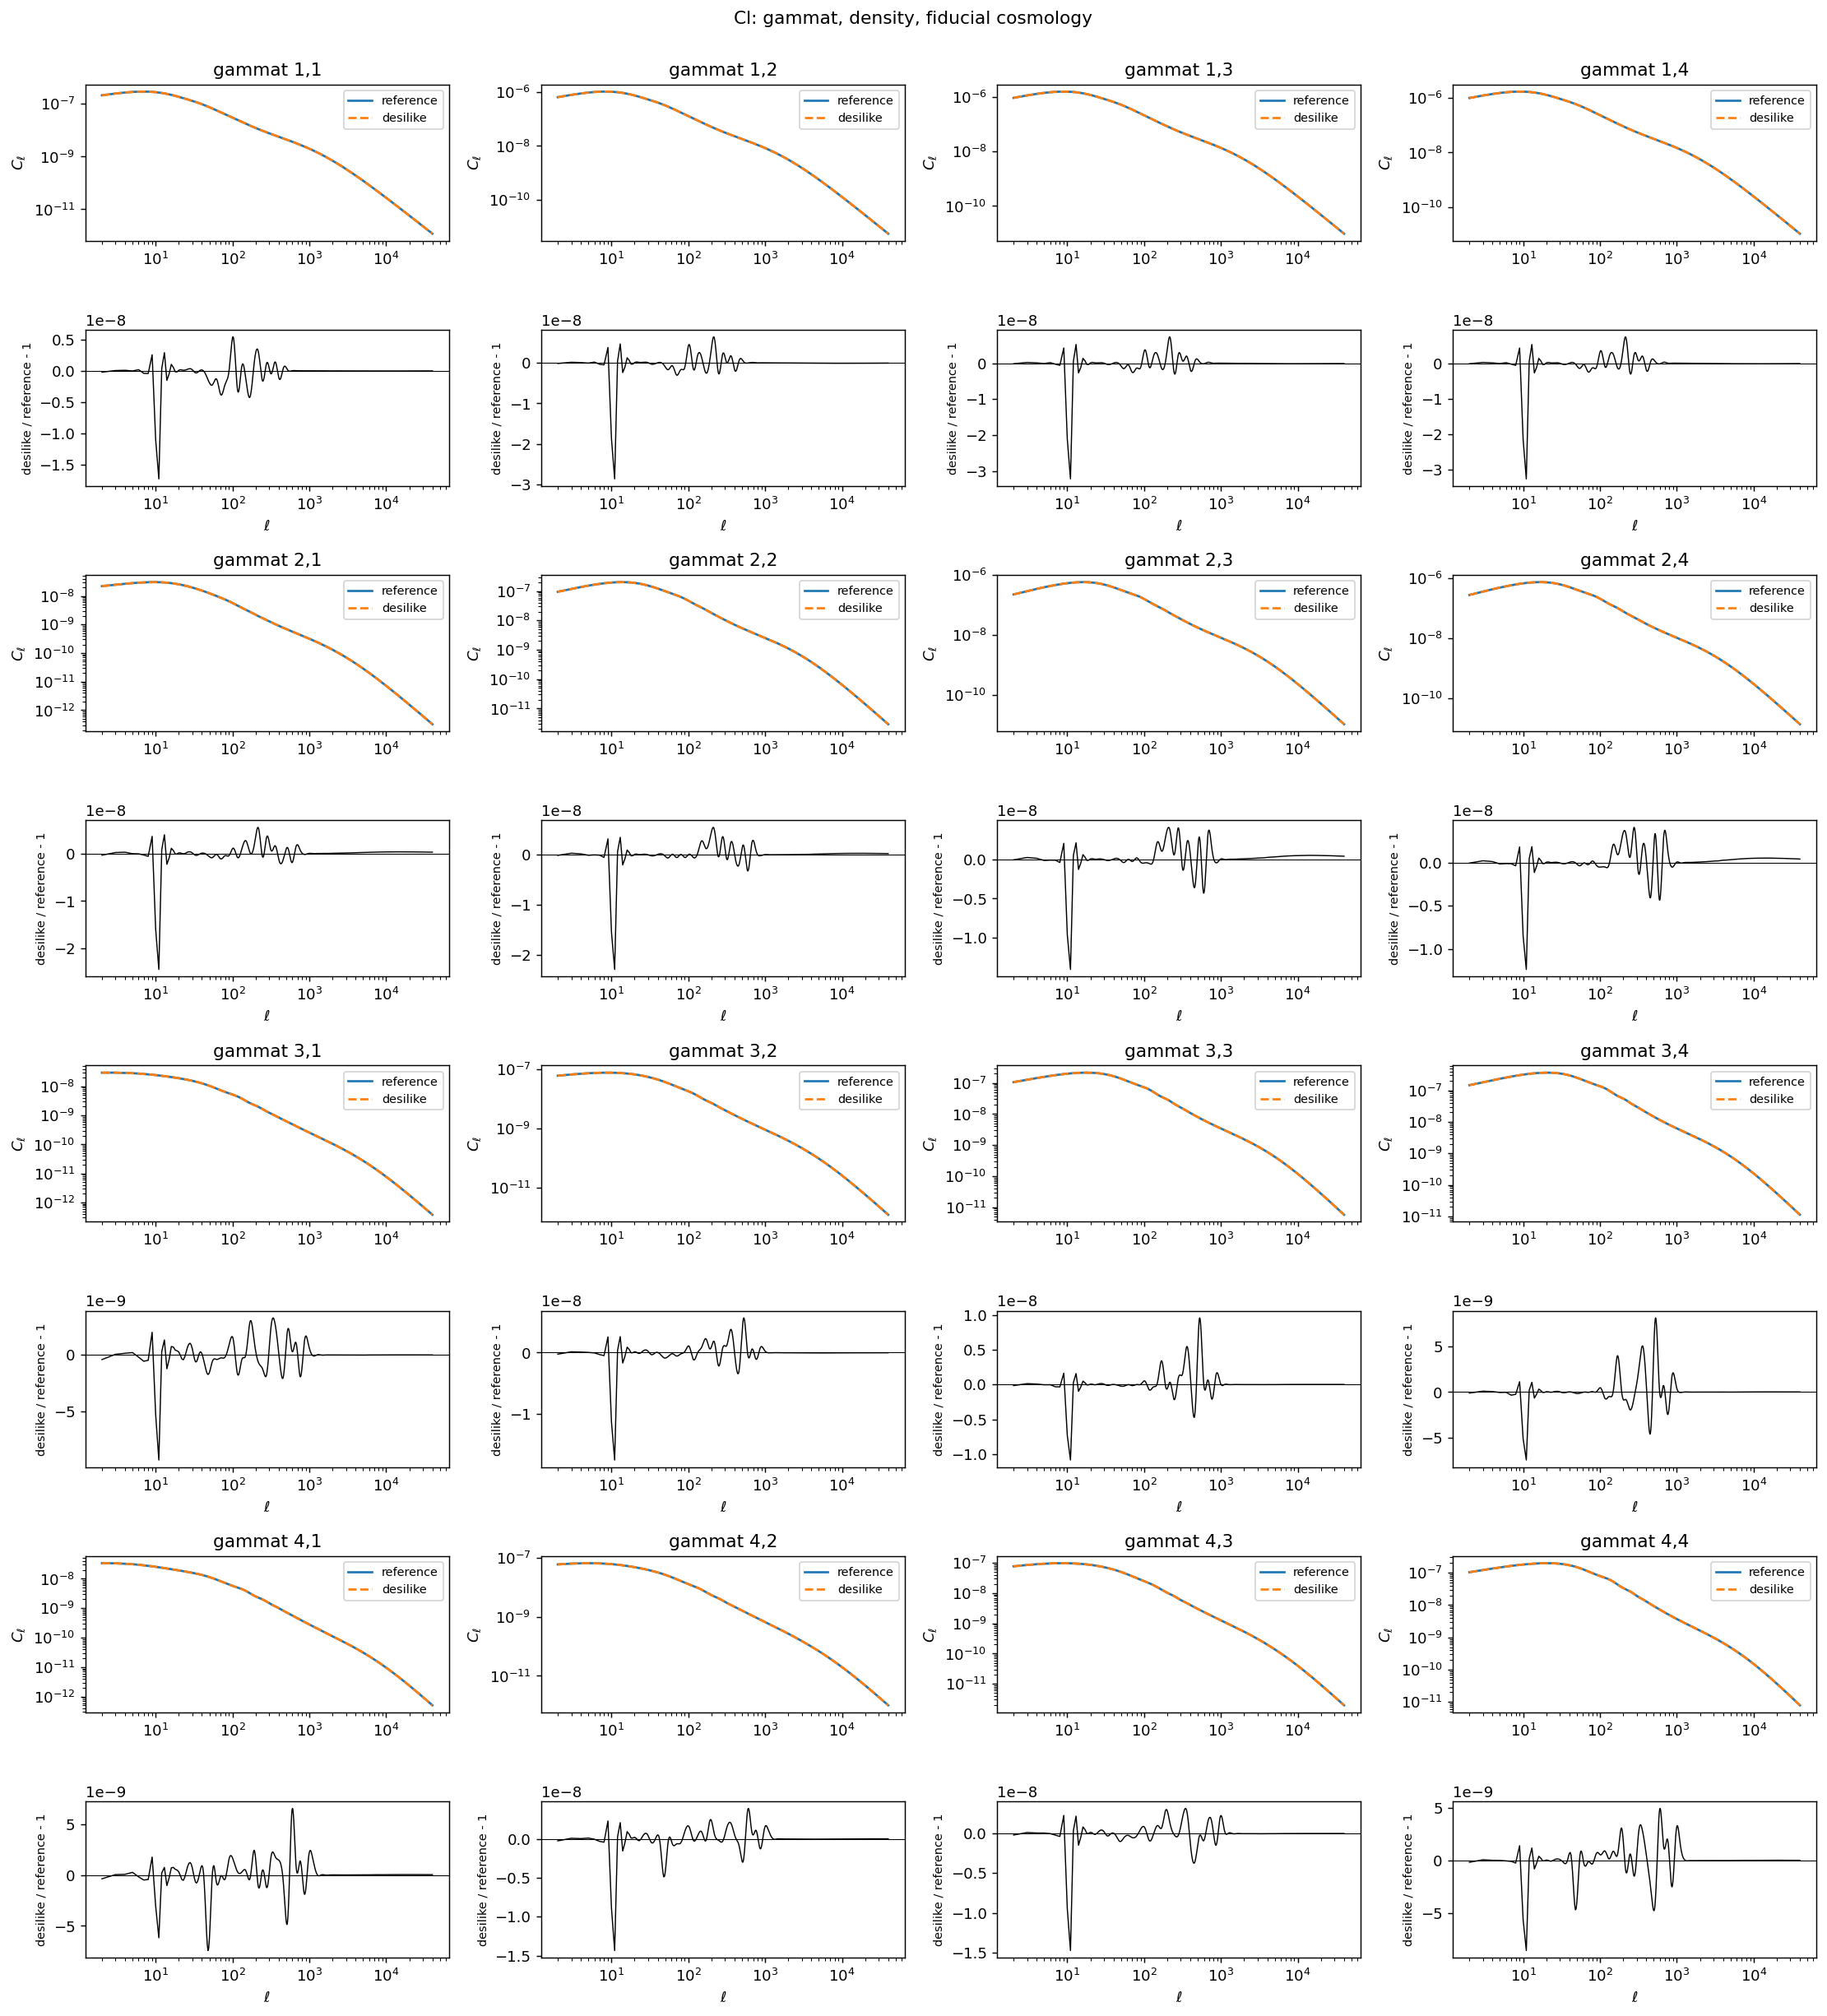

In [26]:
x = np.asarray(fiducial["predictions"]["density"]["ell"])
first = fiducial["predictions"]["density"]["cl_gammat"]
second = fiducial["references"]["density"]["cls"]["gammat"]
pairs = PLOT_PAIRS["gammat"]
fig, axes = plt.subplots(8, 4, figsize=(17.2, 18.8), squeeze=False)
for ax in axes.flat:
    ax.set_visible(False)

for count, (i, j) in enumerate(pairs):
    row, col = (i, j)
    top, bottom = axes[2 * row, col], axes[2 * row + 1, col]
    top.set_visible(True)
    bottom.set_visible(True)
    a = np.asarray(first[i, j])
    b = np.asarray(second[i, j])
    mask = x >= 2
    top.plot(x[mask], b[mask], label="reference")
    top.plot(x[mask], a[mask], "--", label="desilike")
    top.set_xscale("log")
    # Preserve negative values; use log-log axes when every value is positive.
    if np.any(a[mask] < 0) or np.any(b[mask] < 0):
        top.set_yscale("symlog", linthresh=max(np.max(np.abs(b)) * 1e-5, 1e-300))
    else:
        top.set_yscale("log")
    top.set_title(f"gammat {i+1},{j+1}")
    top.set_ylabel(r"$C_\ell$")
    top.legend(fontsize=8)

    valid = mask & (np.abs(b) > max(np.max(np.abs(b)) * 1e-12, 1e-300))
    delta = np.full_like(b, np.nan, dtype=float)
    np.divide(a - b, b, out=delta, where=valid)  # Do not plot ratios where the denominator crosses zero.
    axes[2 * row + 1, col].semilogx(x[valid], delta[valid], color="black", lw=0.8)
    bottom.axhline(0, color="black", lw=0.6)
    bottom.set_xlabel(r"$\ell$")
    bottom.set_ylabel("desilike / reference - 1", fontsize=8)
    bottom.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

fig.suptitle("Cl: gammat, density, fiducial cosmology", y=1.002)
fig.tight_layout()
fig.savefig(OUT / "Cl_density_gammat.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)


### xip — Cl — Weyl off:desilike / reference

/var/folders/f6/3xg83pv93rd82_jd1m8pv17r0000gn/T/ipykernel_16263/297518230.py:41: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


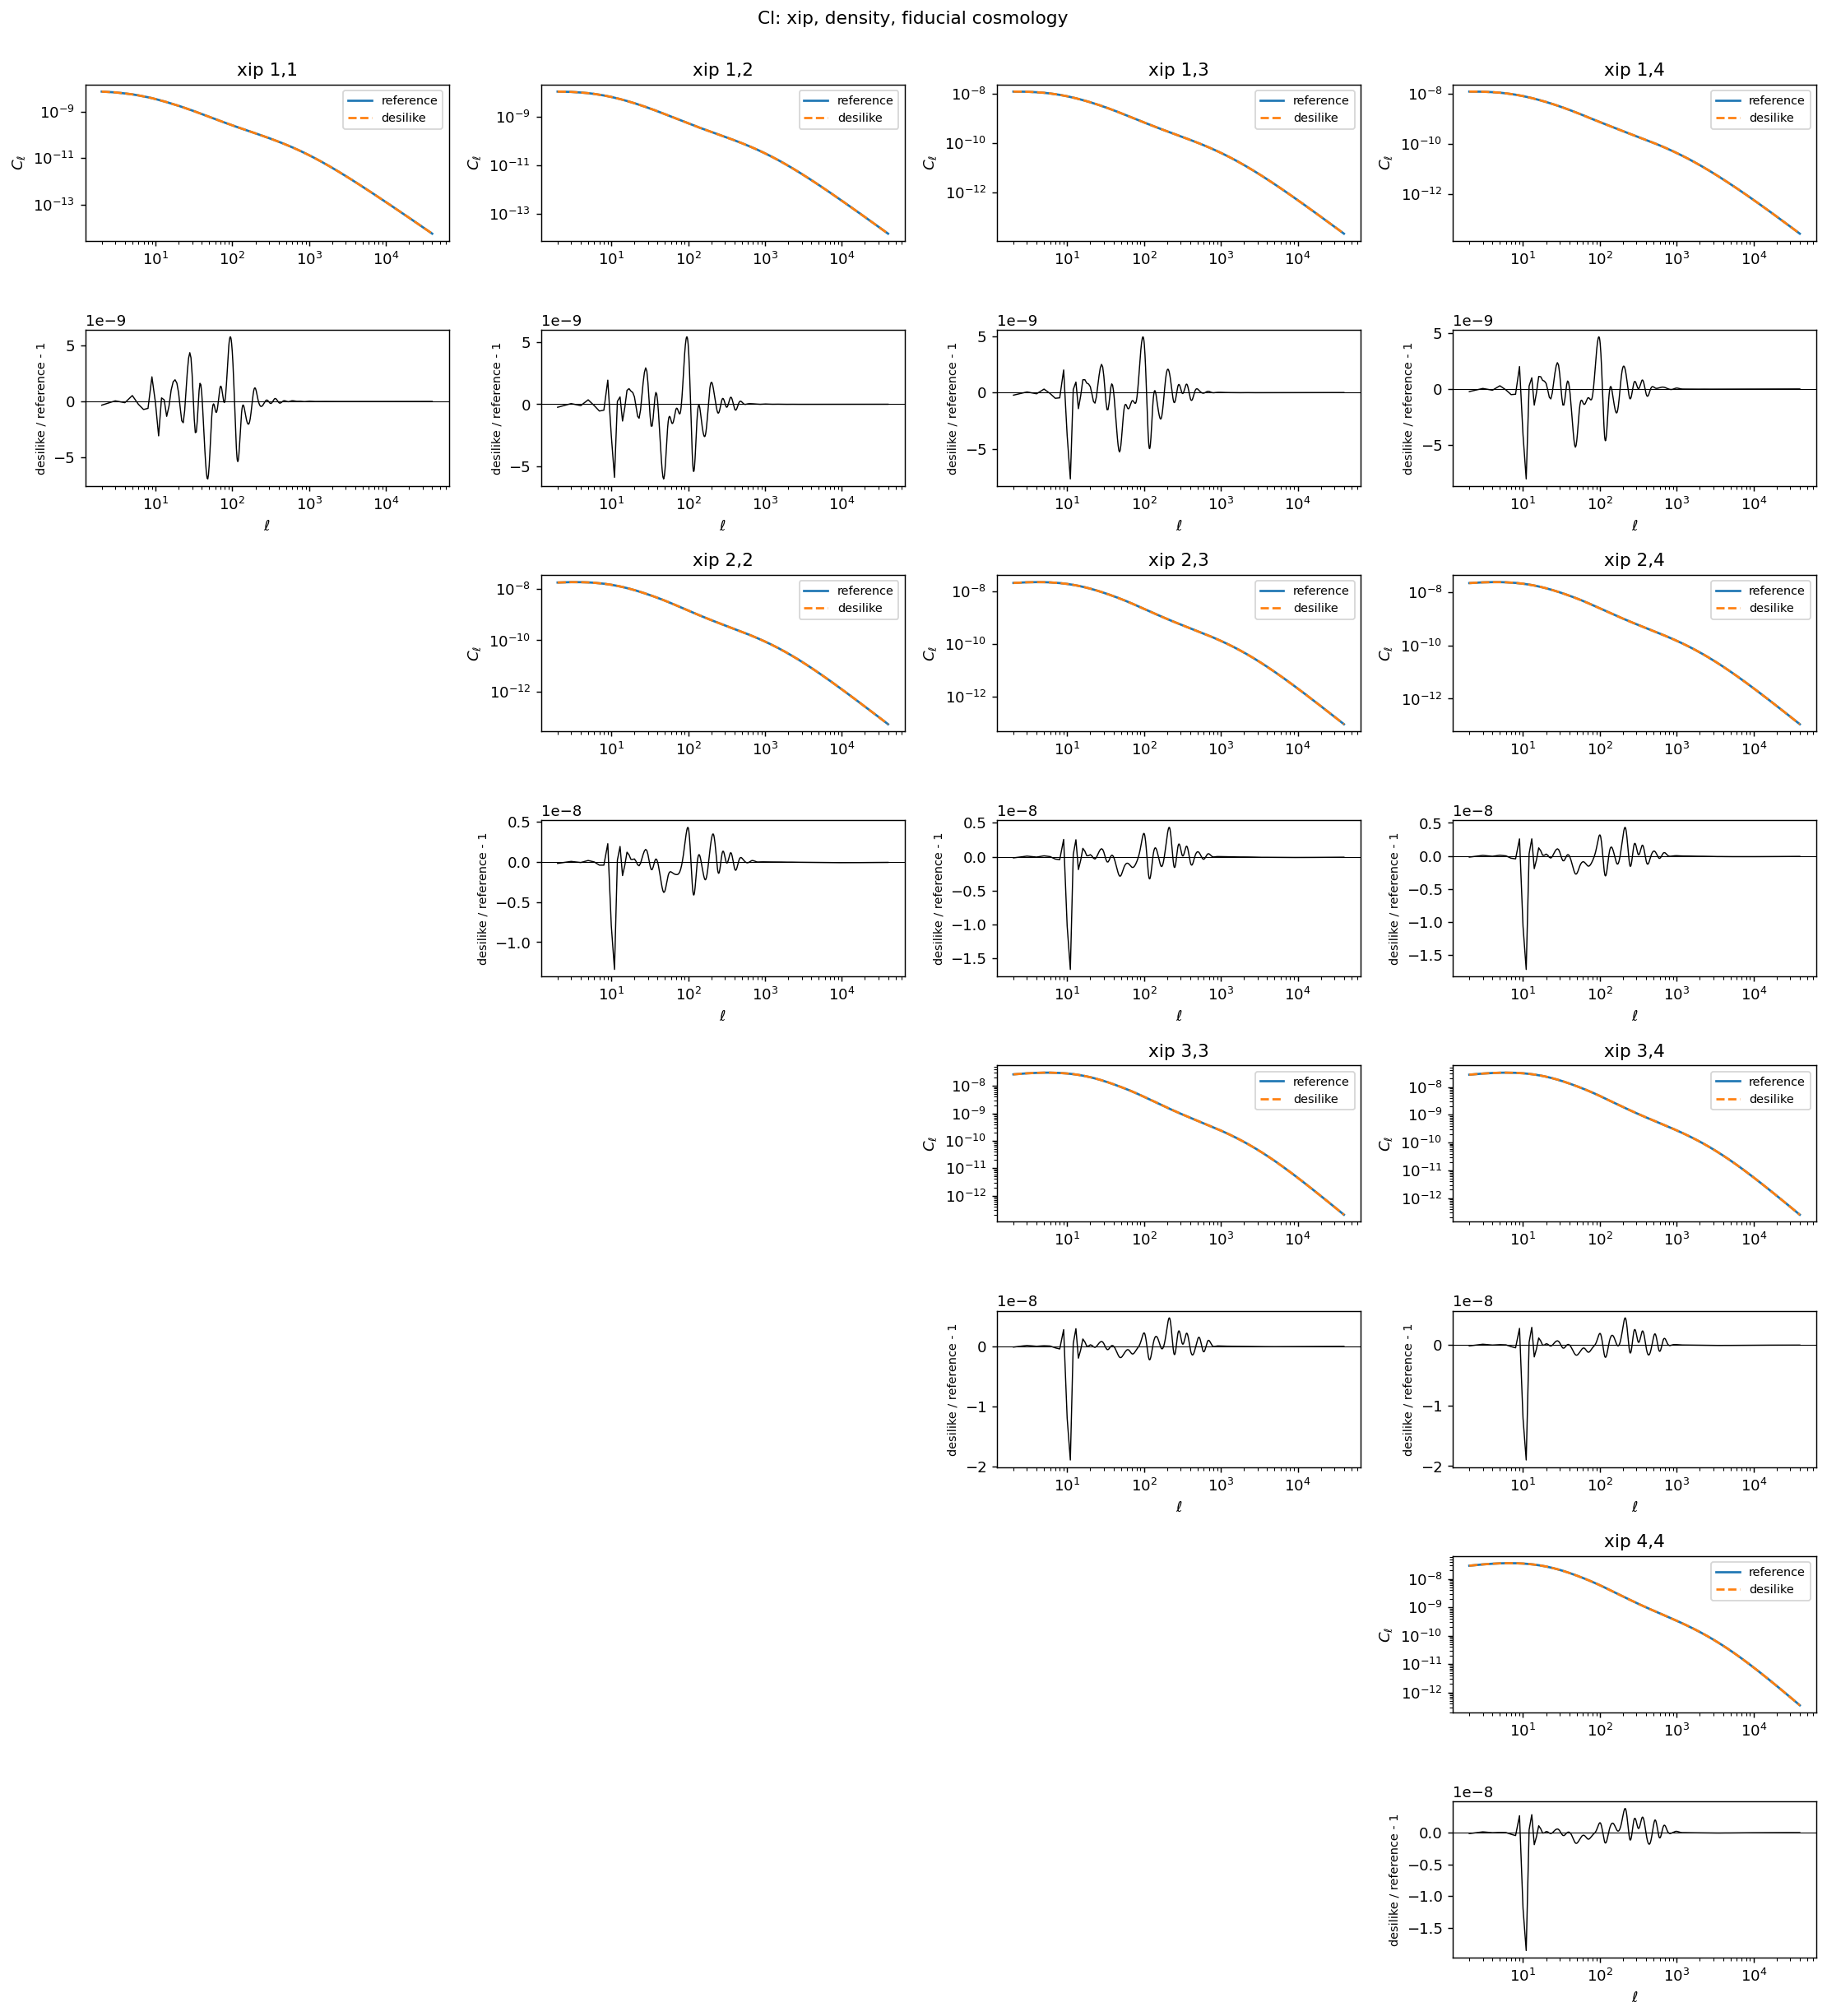

In [27]:
x = np.asarray(fiducial["predictions"]["density"]["ell"])
first = fiducial["predictions"]["density"]["cl_xip"]
second = fiducial["references"]["density"]["cls"]["xip"]
pairs = PLOT_PAIRS["xip"]
fig, axes = plt.subplots(8, 4, figsize=(17.2, 18.8), squeeze=False)
for ax in axes.flat:
    ax.set_visible(False)

for count, (i, j) in enumerate(pairs):
    row, col = (i, j)
    top, bottom = axes[2 * row, col], axes[2 * row + 1, col]
    top.set_visible(True)
    bottom.set_visible(True)
    a = np.asarray(first[i, j])
    b = np.asarray(second[i, j])
    mask = x >= 2
    top.plot(x[mask], b[mask], label="reference")
    top.plot(x[mask], a[mask], "--", label="desilike")
    top.set_xscale("log")
    # Preserve negative values; use log-log axes when every value is positive.
    if np.any(a[mask] < 0) or np.any(b[mask] < 0):
        top.set_yscale("symlog", linthresh=max(np.max(np.abs(b)) * 1e-5, 1e-300))
    else:
        top.set_yscale("log")
    top.set_title(f"xip {i+1},{j+1}")
    top.set_ylabel(r"$C_\ell$")
    top.legend(fontsize=8)

    valid = mask & (np.abs(b) > max(np.max(np.abs(b)) * 1e-12, 1e-300))
    delta = np.full_like(b, np.nan, dtype=float)
    np.divide(a - b, b, out=delta, where=valid)  # Do not plot ratios where the denominator crosses zero.
    axes[2 * row + 1, col].semilogx(x[valid], delta[valid], color="black", lw=0.8)
    bottom.axhline(0, color="black", lw=0.6)
    bottom.set_xlabel(r"$\ell$")
    bottom.set_ylabel("desilike / reference - 1", fontsize=8)
    bottom.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

fig.suptitle("Cl: xip, density, fiducial cosmology", y=1.002)
fig.tight_layout()
fig.savefig(OUT / "Cl_density_xip.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)


### xim — Cl — Weyl off:desilike / reference

/var/folders/f6/3xg83pv93rd82_jd1m8pv17r0000gn/T/ipykernel_16263/591239112.py:41: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


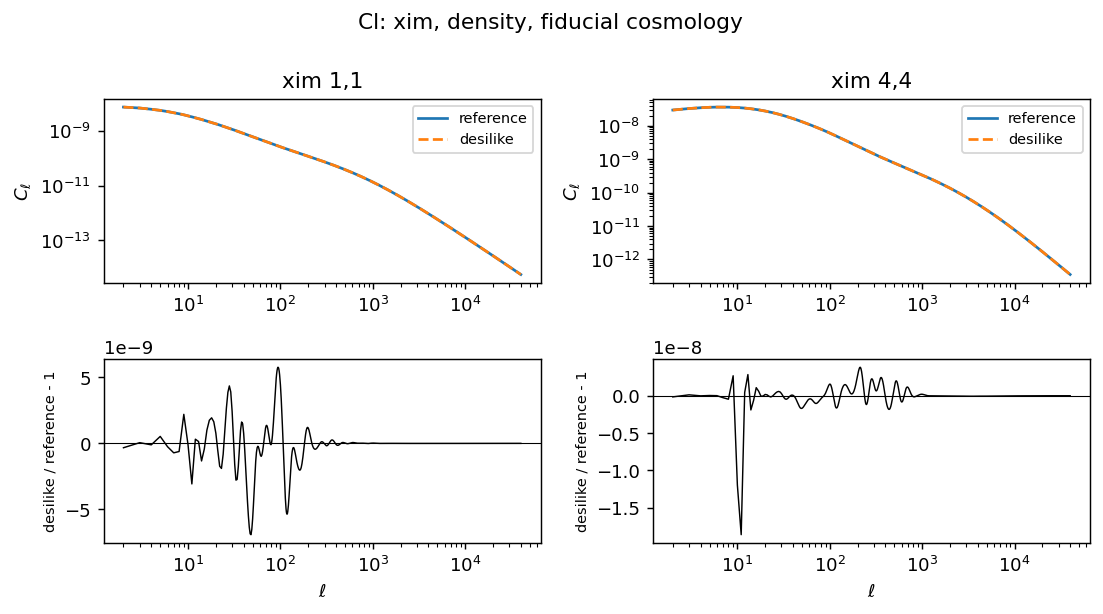

In [28]:
x = np.asarray(fiducial["predictions"]["density"]["ell"])
first = fiducial["predictions"]["density"]["cl_xim"]
second = fiducial["references"]["density"]["cls"]["xim"]
pairs = PLOT_PAIRS["xim"]
fig, axes = plt.subplots(2, 2, figsize=(8.6, 4.7), squeeze=False)
for ax in axes.flat:
    ax.set_visible(False)

for count, (i, j) in enumerate(pairs):
    row, col = (0, count)
    top, bottom = axes[2 * row, col], axes[2 * row + 1, col]
    top.set_visible(True)
    bottom.set_visible(True)
    a = np.asarray(first[i, j])
    b = np.asarray(second[i, j])
    mask = x >= 2
    top.plot(x[mask], b[mask], label="reference")
    top.plot(x[mask], a[mask], "--", label="desilike")
    top.set_xscale("log")
    # Preserve negative values; use log-log axes when every value is positive.
    if np.any(a[mask] < 0) or np.any(b[mask] < 0):
        top.set_yscale("symlog", linthresh=max(np.max(np.abs(b)) * 1e-5, 1e-300))
    else:
        top.set_yscale("log")
    top.set_title(f"xim {i+1},{j+1}")
    top.set_ylabel(r"$C_\ell$")
    top.legend(fontsize=8)

    valid = mask & (np.abs(b) > max(np.max(np.abs(b)) * 1e-12, 1e-300))
    delta = np.full_like(b, np.nan, dtype=float)
    np.divide(a - b, b, out=delta, where=valid)  # Do not plot ratios where the denominator crosses zero.
    axes[2 * row + 1, col].semilogx(x[valid], delta[valid], color="black", lw=0.8)
    bottom.axhline(0, color="black", lw=0.6)
    bottom.set_xlabel(r"$\ell$")
    bottom.set_ylabel("desilike / reference - 1", fontsize=8)
    bottom.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

fig.suptitle("Cl: xim, density, fiducial cosmology", y=1.002)
fig.tight_layout()
fig.savefig(OUT / "Cl_density_xim.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)


### wtheta — Cl — Weyl on:desilike / reference

/var/folders/f6/3xg83pv93rd82_jd1m8pv17r0000gn/T/ipykernel_16263/1027212994.py:41: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


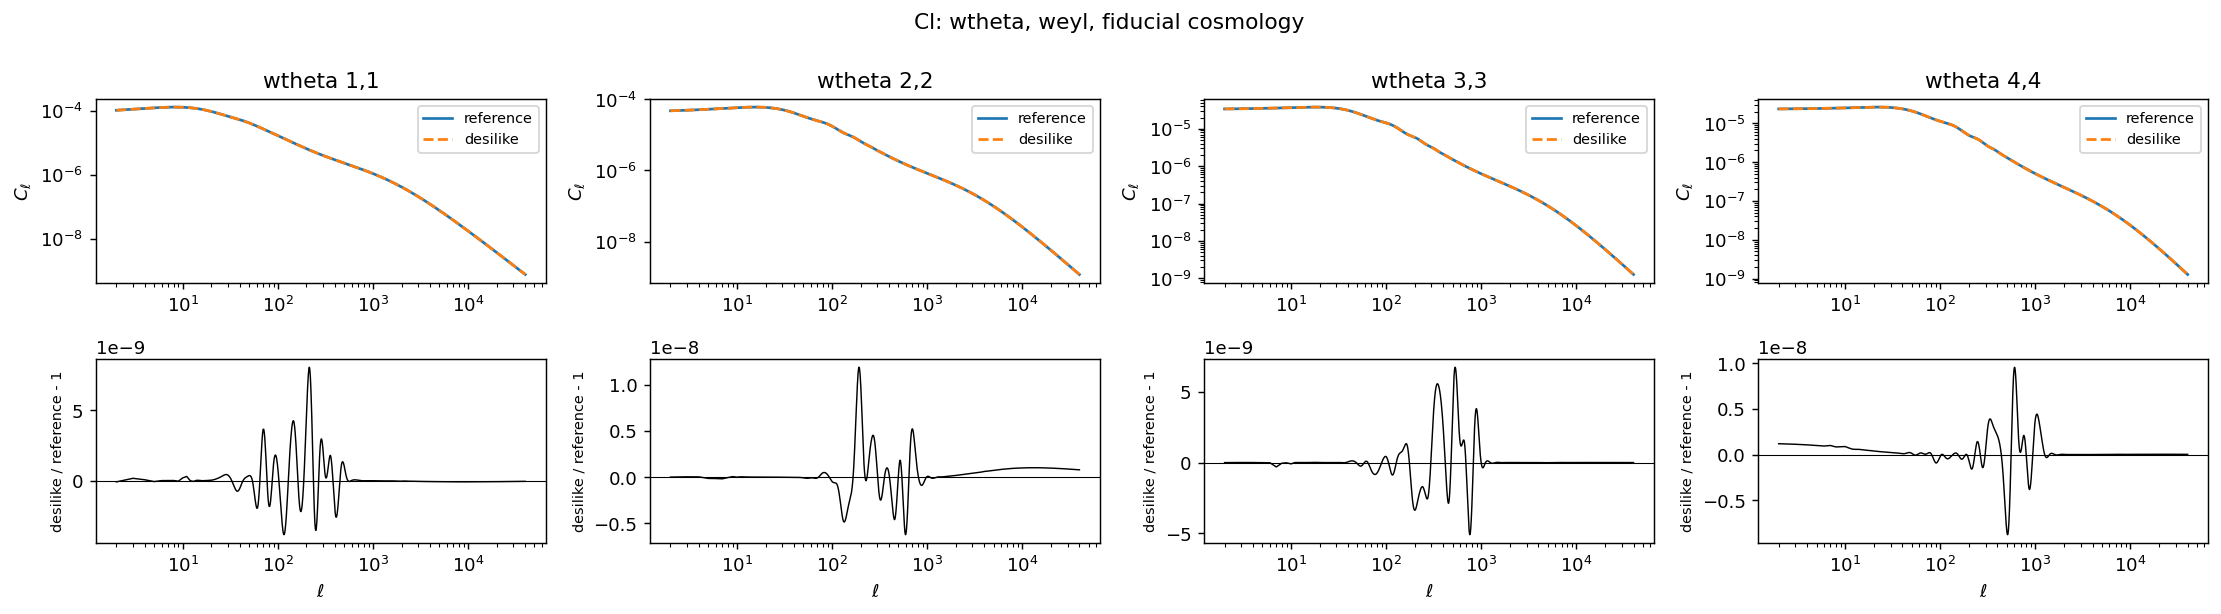

In [29]:
x = np.asarray(fiducial["predictions"]["density"]["ell"])
first = fiducial["predictions"]["weyl"]["cl_wtheta"]
second = fiducial["references"]["weyl"]["cls"]["wtheta"]
pairs = PLOT_PAIRS["wtheta"]
fig, axes = plt.subplots(2, 4, figsize=(17.2, 4.7), squeeze=False)
for ax in axes.flat:
    ax.set_visible(False)

for count, (i, j) in enumerate(pairs):
    row, col = (0, count)
    top, bottom = axes[2 * row, col], axes[2 * row + 1, col]
    top.set_visible(True)
    bottom.set_visible(True)
    a = np.asarray(first[i, j])
    b = np.asarray(second[i, j])
    mask = x >= 2
    top.plot(x[mask], b[mask], label="reference")
    top.plot(x[mask], a[mask], "--", label="desilike")
    top.set_xscale("log")
    # Preserve negative values; use log-log axes when every value is positive.
    if np.any(a[mask] < 0) or np.any(b[mask] < 0):
        top.set_yscale("symlog", linthresh=max(np.max(np.abs(b)) * 1e-5, 1e-300))
    else:
        top.set_yscale("log")
    top.set_title(f"wtheta {i+1},{j+1}")
    top.set_ylabel(r"$C_\ell$")
    top.legend(fontsize=8)

    valid = mask & (np.abs(b) > max(np.max(np.abs(b)) * 1e-12, 1e-300))
    delta = np.full_like(b, np.nan, dtype=float)
    np.divide(a - b, b, out=delta, where=valid)  # Do not plot ratios where the denominator crosses zero.
    axes[2 * row + 1, col].semilogx(x[valid], delta[valid], color="black", lw=0.8)
    bottom.axhline(0, color="black", lw=0.6)
    bottom.set_xlabel(r"$\ell$")
    bottom.set_ylabel("desilike / reference - 1", fontsize=8)
    bottom.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

fig.suptitle("Cl: wtheta, weyl, fiducial cosmology", y=1.002)
fig.tight_layout()
fig.savefig(OUT / "Cl_weyl_wtheta.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)


### gammat — Cl — Weyl on:desilike / reference

/var/folders/f6/3xg83pv93rd82_jd1m8pv17r0000gn/T/ipykernel_16263/1023481075.py:41: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


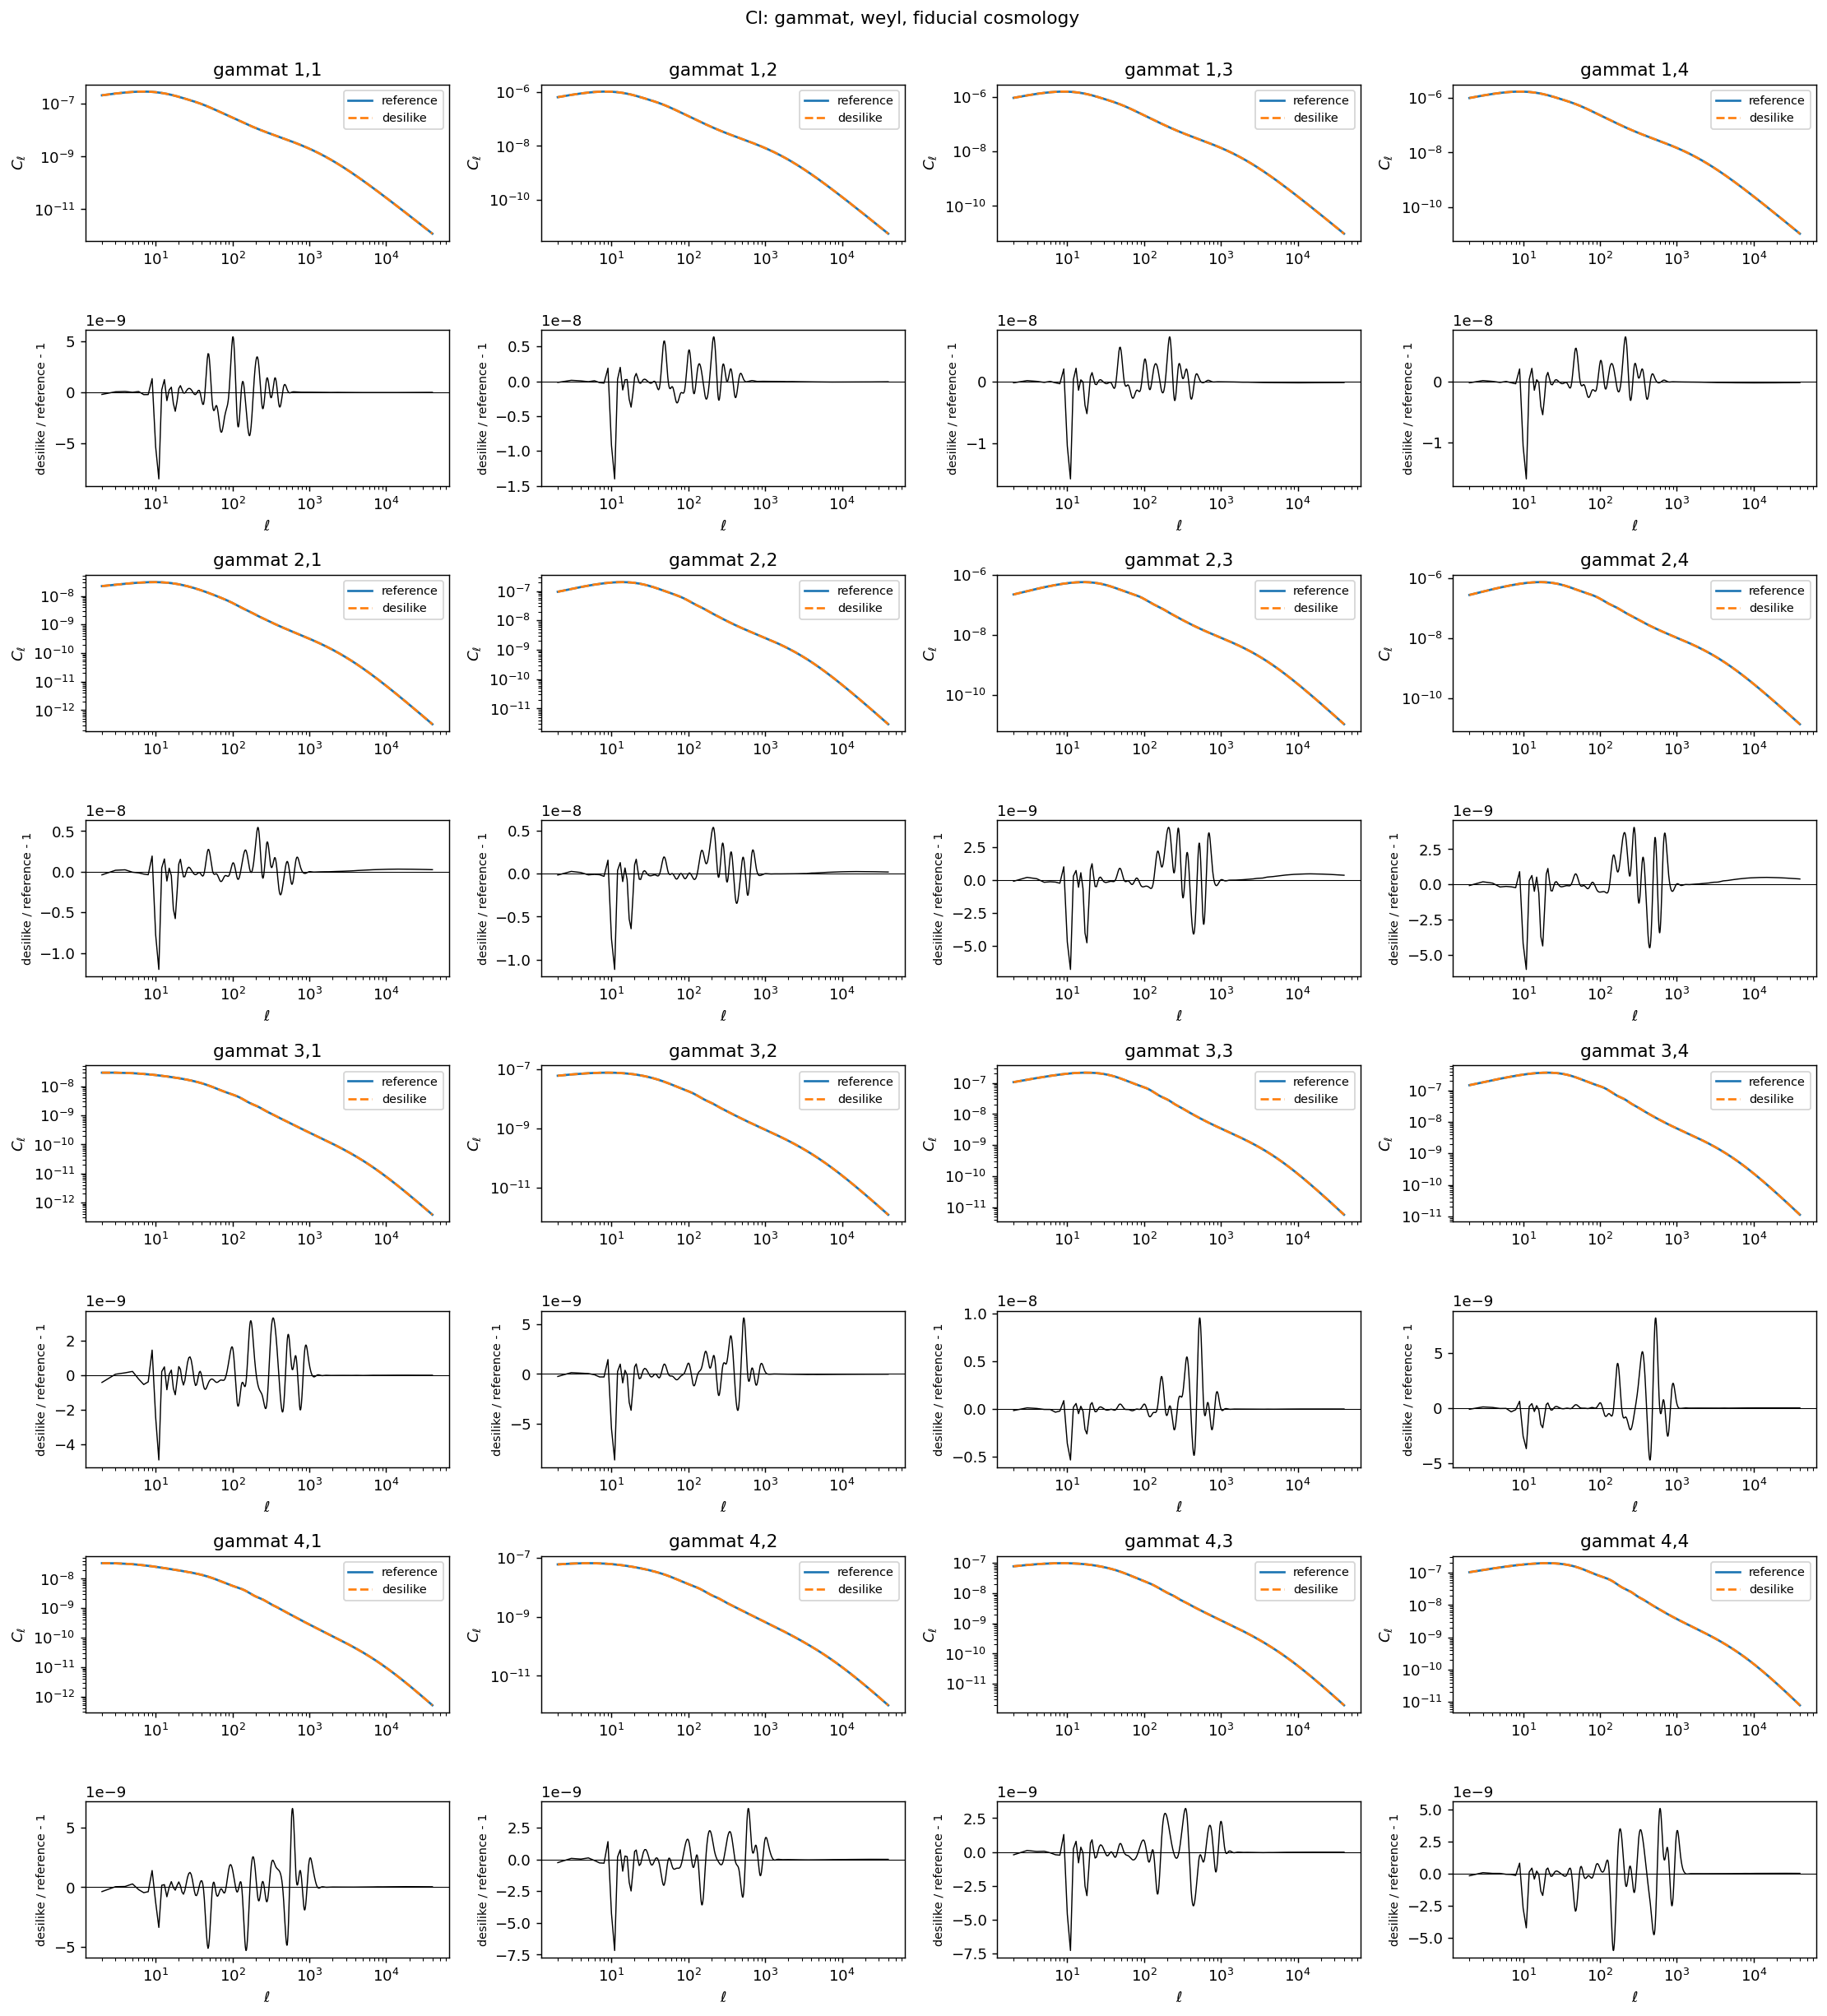

In [30]:
x = np.asarray(fiducial["predictions"]["density"]["ell"])
first = fiducial["predictions"]["weyl"]["cl_gammat"]
second = fiducial["references"]["weyl"]["cls"]["gammat"]
pairs = PLOT_PAIRS["gammat"]
fig, axes = plt.subplots(8, 4, figsize=(17.2, 18.8), squeeze=False)
for ax in axes.flat:
    ax.set_visible(False)

for count, (i, j) in enumerate(pairs):
    row, col = (i, j)
    top, bottom = axes[2 * row, col], axes[2 * row + 1, col]
    top.set_visible(True)
    bottom.set_visible(True)
    a = np.asarray(first[i, j])
    b = np.asarray(second[i, j])
    mask = x >= 2
    top.plot(x[mask], b[mask], label="reference")
    top.plot(x[mask], a[mask], "--", label="desilike")
    top.set_xscale("log")
    # Preserve negative values; use log-log axes when every value is positive.
    if np.any(a[mask] < 0) or np.any(b[mask] < 0):
        top.set_yscale("symlog", linthresh=max(np.max(np.abs(b)) * 1e-5, 1e-300))
    else:
        top.set_yscale("log")
    top.set_title(f"gammat {i+1},{j+1}")
    top.set_ylabel(r"$C_\ell$")
    top.legend(fontsize=8)

    valid = mask & (np.abs(b) > max(np.max(np.abs(b)) * 1e-12, 1e-300))
    delta = np.full_like(b, np.nan, dtype=float)
    np.divide(a - b, b, out=delta, where=valid)  # Do not plot ratios where the denominator crosses zero.
    axes[2 * row + 1, col].semilogx(x[valid], delta[valid], color="black", lw=0.8)
    bottom.axhline(0, color="black", lw=0.6)
    bottom.set_xlabel(r"$\ell$")
    bottom.set_ylabel("desilike / reference - 1", fontsize=8)
    bottom.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

fig.suptitle("Cl: gammat, weyl, fiducial cosmology", y=1.002)
fig.tight_layout()
fig.savefig(OUT / "Cl_weyl_gammat.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)


### xip — Cl — Weyl on:desilike / reference

/var/folders/f6/3xg83pv93rd82_jd1m8pv17r0000gn/T/ipykernel_16263/1541879002.py:41: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


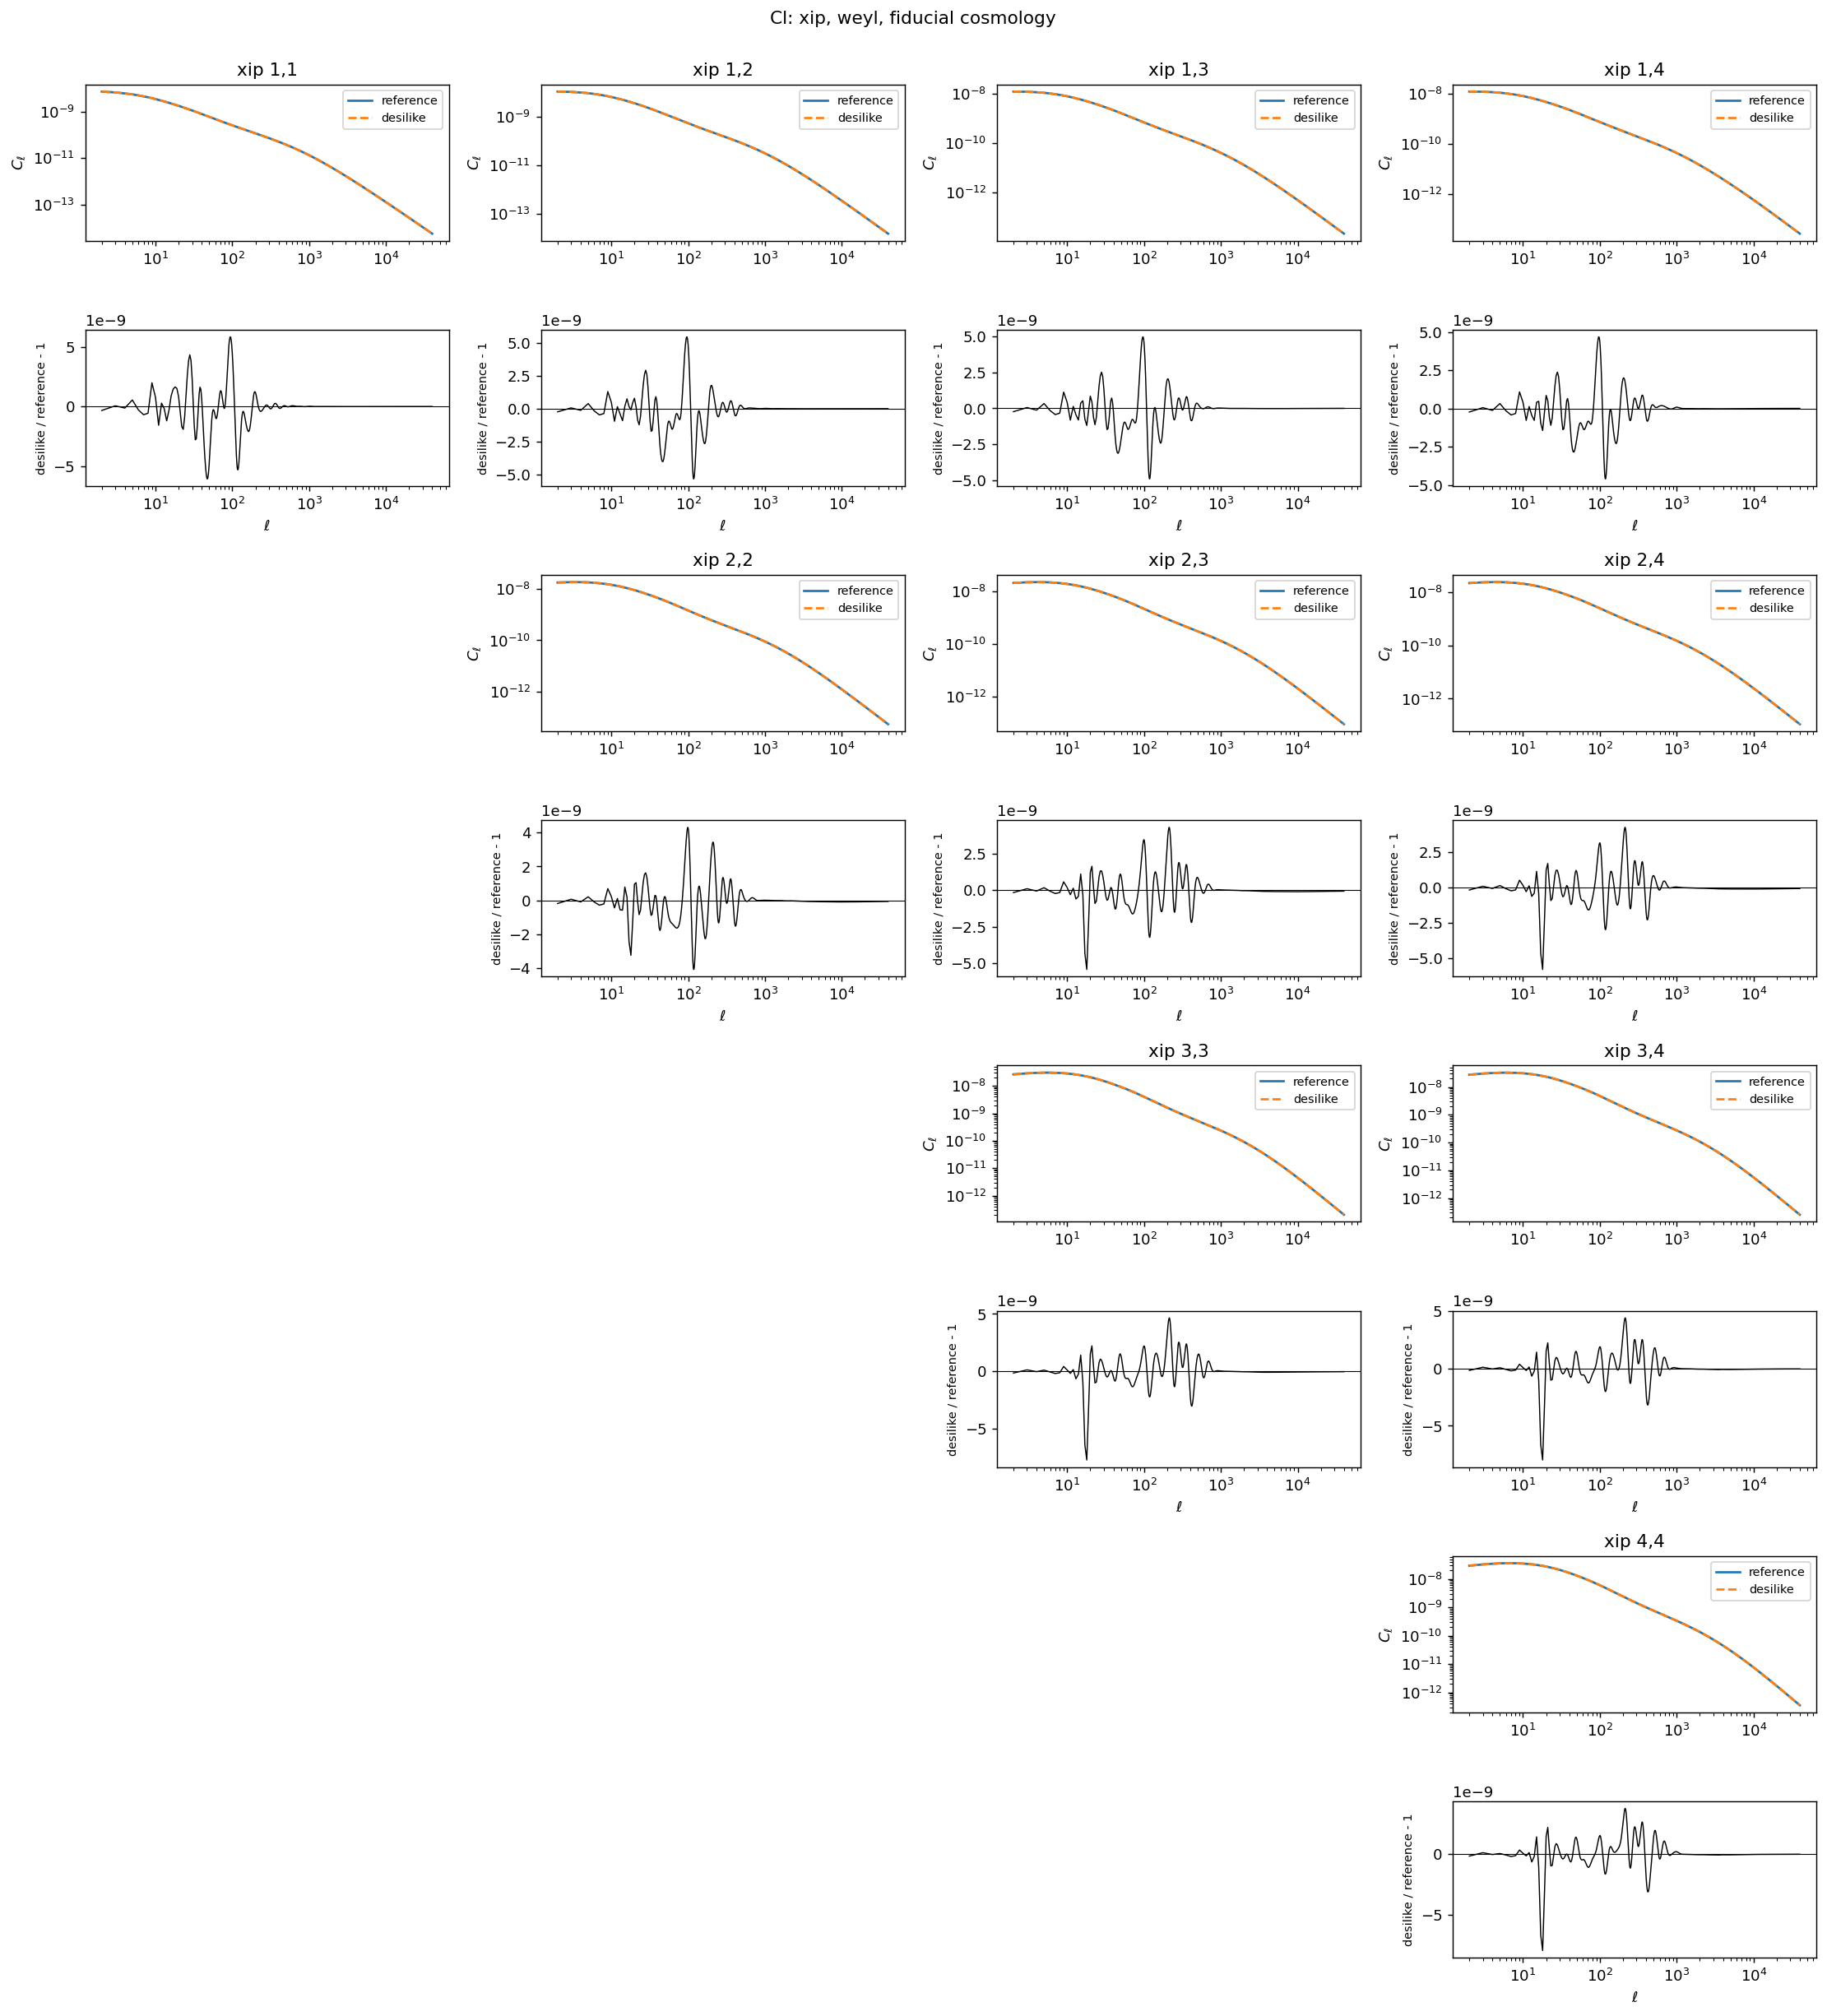

In [31]:
x = np.asarray(fiducial["predictions"]["density"]["ell"])
first = fiducial["predictions"]["weyl"]["cl_xip"]
second = fiducial["references"]["weyl"]["cls"]["xip"]
pairs = PLOT_PAIRS["xip"]
fig, axes = plt.subplots(8, 4, figsize=(17.2, 18.8), squeeze=False)
for ax in axes.flat:
    ax.set_visible(False)

for count, (i, j) in enumerate(pairs):
    row, col = (i, j)
    top, bottom = axes[2 * row, col], axes[2 * row + 1, col]
    top.set_visible(True)
    bottom.set_visible(True)
    a = np.asarray(first[i, j])
    b = np.asarray(second[i, j])
    mask = x >= 2
    top.plot(x[mask], b[mask], label="reference")
    top.plot(x[mask], a[mask], "--", label="desilike")
    top.set_xscale("log")
    # Preserve negative values; use log-log axes when every value is positive.
    if np.any(a[mask] < 0) or np.any(b[mask] < 0):
        top.set_yscale("symlog", linthresh=max(np.max(np.abs(b)) * 1e-5, 1e-300))
    else:
        top.set_yscale("log")
    top.set_title(f"xip {i+1},{j+1}")
    top.set_ylabel(r"$C_\ell$")
    top.legend(fontsize=8)

    valid = mask & (np.abs(b) > max(np.max(np.abs(b)) * 1e-12, 1e-300))
    delta = np.full_like(b, np.nan, dtype=float)
    np.divide(a - b, b, out=delta, where=valid)  # Do not plot ratios where the denominator crosses zero.
    axes[2 * row + 1, col].semilogx(x[valid], delta[valid], color="black", lw=0.8)
    bottom.axhline(0, color="black", lw=0.6)
    bottom.set_xlabel(r"$\ell$")
    bottom.set_ylabel("desilike / reference - 1", fontsize=8)
    bottom.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

fig.suptitle("Cl: xip, weyl, fiducial cosmology", y=1.002)
fig.tight_layout()
fig.savefig(OUT / "Cl_weyl_xip.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)


### xim — Cl — Weyl on:desilike / reference

/var/folders/f6/3xg83pv93rd82_jd1m8pv17r0000gn/T/ipykernel_16263/257359805.py:41: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


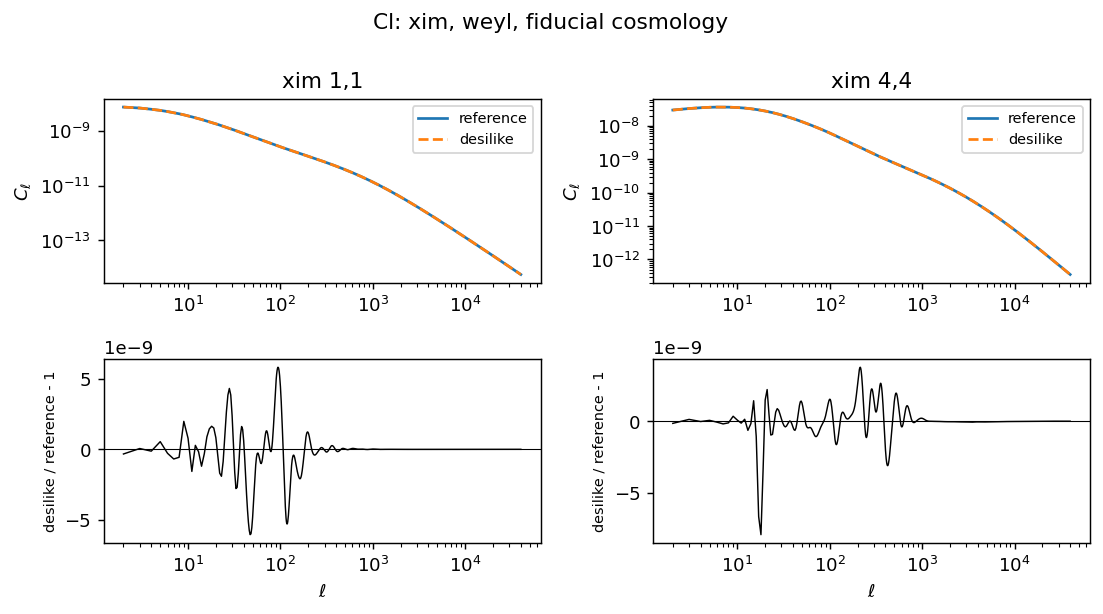

In [32]:
x = np.asarray(fiducial["predictions"]["density"]["ell"])
first = fiducial["predictions"]["weyl"]["cl_xim"]
second = fiducial["references"]["weyl"]["cls"]["xim"]
pairs = PLOT_PAIRS["xim"]
fig, axes = plt.subplots(2, 2, figsize=(8.6, 4.7), squeeze=False)
for ax in axes.flat:
    ax.set_visible(False)

for count, (i, j) in enumerate(pairs):
    row, col = (0, count)
    top, bottom = axes[2 * row, col], axes[2 * row + 1, col]
    top.set_visible(True)
    bottom.set_visible(True)
    a = np.asarray(first[i, j])
    b = np.asarray(second[i, j])
    mask = x >= 2
    top.plot(x[mask], b[mask], label="reference")
    top.plot(x[mask], a[mask], "--", label="desilike")
    top.set_xscale("log")
    # Preserve negative values; use log-log axes when every value is positive.
    if np.any(a[mask] < 0) or np.any(b[mask] < 0):
        top.set_yscale("symlog", linthresh=max(np.max(np.abs(b)) * 1e-5, 1e-300))
    else:
        top.set_yscale("log")
    top.set_title(f"xim {i+1},{j+1}")
    top.set_ylabel(r"$C_\ell$")
    top.legend(fontsize=8)

    valid = mask & (np.abs(b) > max(np.max(np.abs(b)) * 1e-12, 1e-300))
    delta = np.full_like(b, np.nan, dtype=float)
    np.divide(a - b, b, out=delta, where=valid)  # Do not plot ratios where the denominator crosses zero.
    axes[2 * row + 1, col].semilogx(x[valid], delta[valid], color="black", lw=0.8)
    bottom.axhline(0, color="black", lw=0.6)
    bottom.set_xlabel(r"$\ell$")
    bottom.set_ylabel("desilike / reference - 1", fontsize=8)
    bottom.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

fig.suptitle("Cl: xim, weyl, fiducial cosmology", y=1.002)
fig.tight_layout()
fig.savefig(OUT / "Cl_weyl_xim.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)


## 5. Correlation functions

Show every bin pair used by the likelihood, with 20 angular points per curve. The likelihood subsequently applies angular scale cuts.

### wtheta — xi — Weyl off:desilike / reference

/var/folders/f6/3xg83pv93rd82_jd1m8pv17r0000gn/T/ipykernel_16263/2094234567.py:41: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


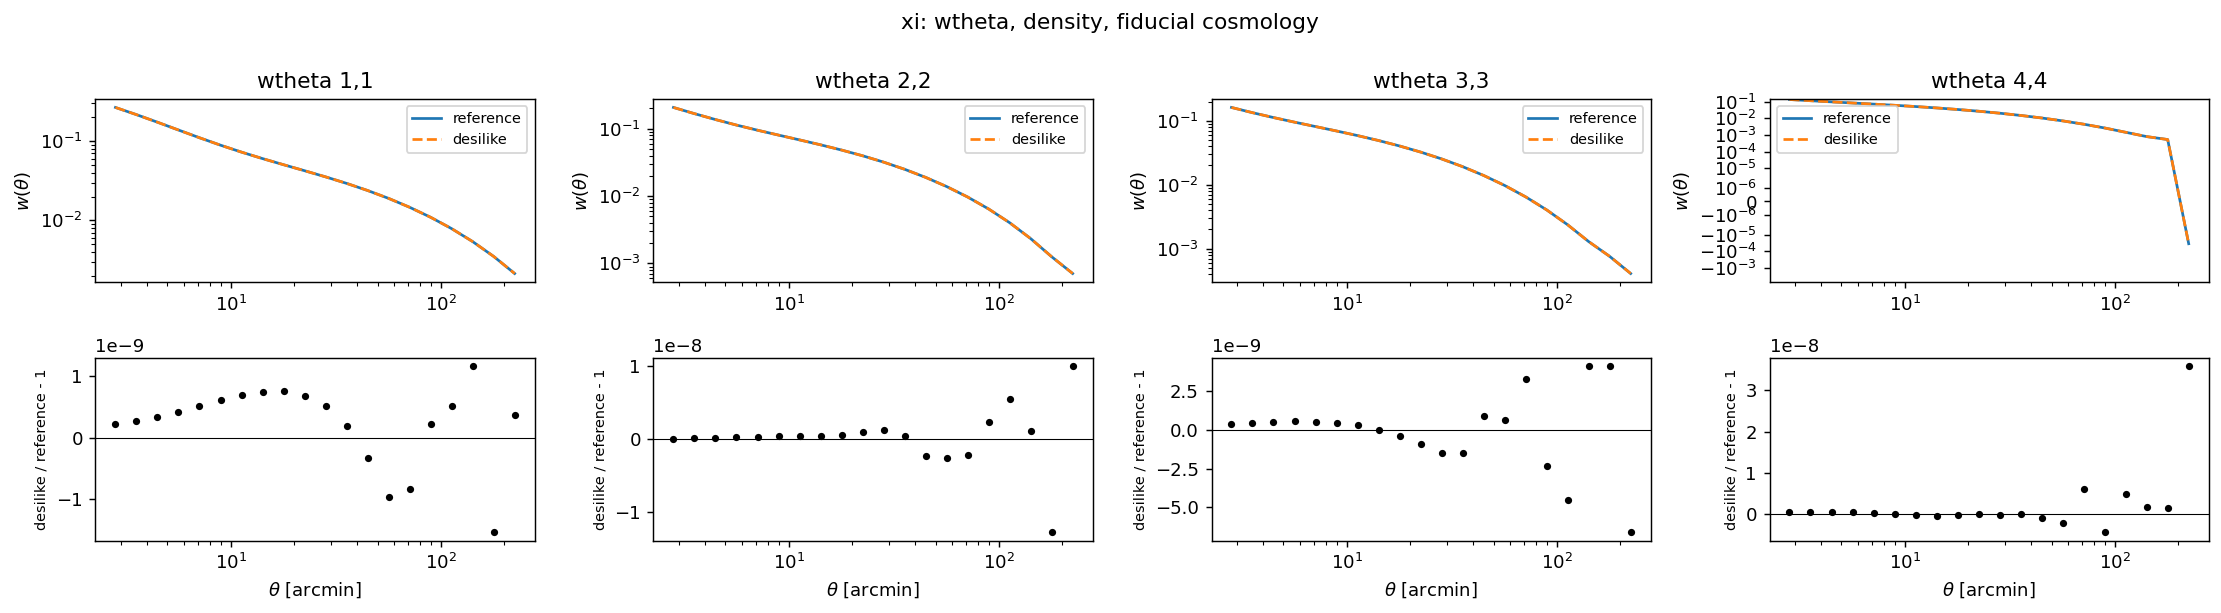

In [33]:
x = np.asarray(theta_bins)
first = fiducial["predictions"]["density"]["wtheta"]
second = fiducial["references"]["density"]["corrs"][3]
pairs = PLOT_PAIRS["wtheta"]
fig, axes = plt.subplots(2, 4, figsize=(17.2, 4.7), squeeze=False)
for ax in axes.flat:
    ax.set_visible(False)

for count, (i, j) in enumerate(pairs):
    row, col = (0, count)
    top, bottom = axes[2 * row, col], axes[2 * row + 1, col]
    top.set_visible(True)
    bottom.set_visible(True)
    a = np.asarray(first[i, j])
    b = np.asarray(second[i, j])
    mask = np.ones(x.size, dtype=bool)
    top.plot(x[mask], b[mask], label="reference")
    top.plot(x[mask], a[mask], "--", label="desilike")
    top.set_xscale("log")
    # Preserve negative values; use log-log axes when every value is positive.
    if np.any(a[mask] < 0) or np.any(b[mask] < 0):
        top.set_yscale("symlog", linthresh=max(np.max(np.abs(b)) * 1e-5, 1e-300))
    else:
        top.set_yscale("log")
    top.set_title(f"wtheta {i+1},{j+1}")
    top.set_ylabel(r"$w(\theta)$")
    top.legend(fontsize=8)

    valid = mask & (np.abs(b) > max(np.max(np.abs(b)) * 1e-12, 1e-300))
    delta = np.full_like(b, np.nan, dtype=float)
    np.divide(a - b, b, out=delta, where=valid)  # Do not plot ratios where the denominator crosses zero.
    axes[2 * row + 1, col].semilogx(x[valid], delta[valid], "ko", ms=3)
    bottom.axhline(0, color="black", lw=0.6)
    bottom.set_xlabel(r"$\theta$ [arcmin]")
    bottom.set_ylabel("desilike / reference - 1", fontsize=8)
    bottom.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

fig.suptitle("xi: wtheta, density, fiducial cosmology", y=1.002)
fig.tight_layout()
fig.savefig(OUT / "xi_density_wtheta.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)


### gammat — xi — Weyl off:desilike / reference

/var/folders/f6/3xg83pv93rd82_jd1m8pv17r0000gn/T/ipykernel_16263/1793513374.py:41: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


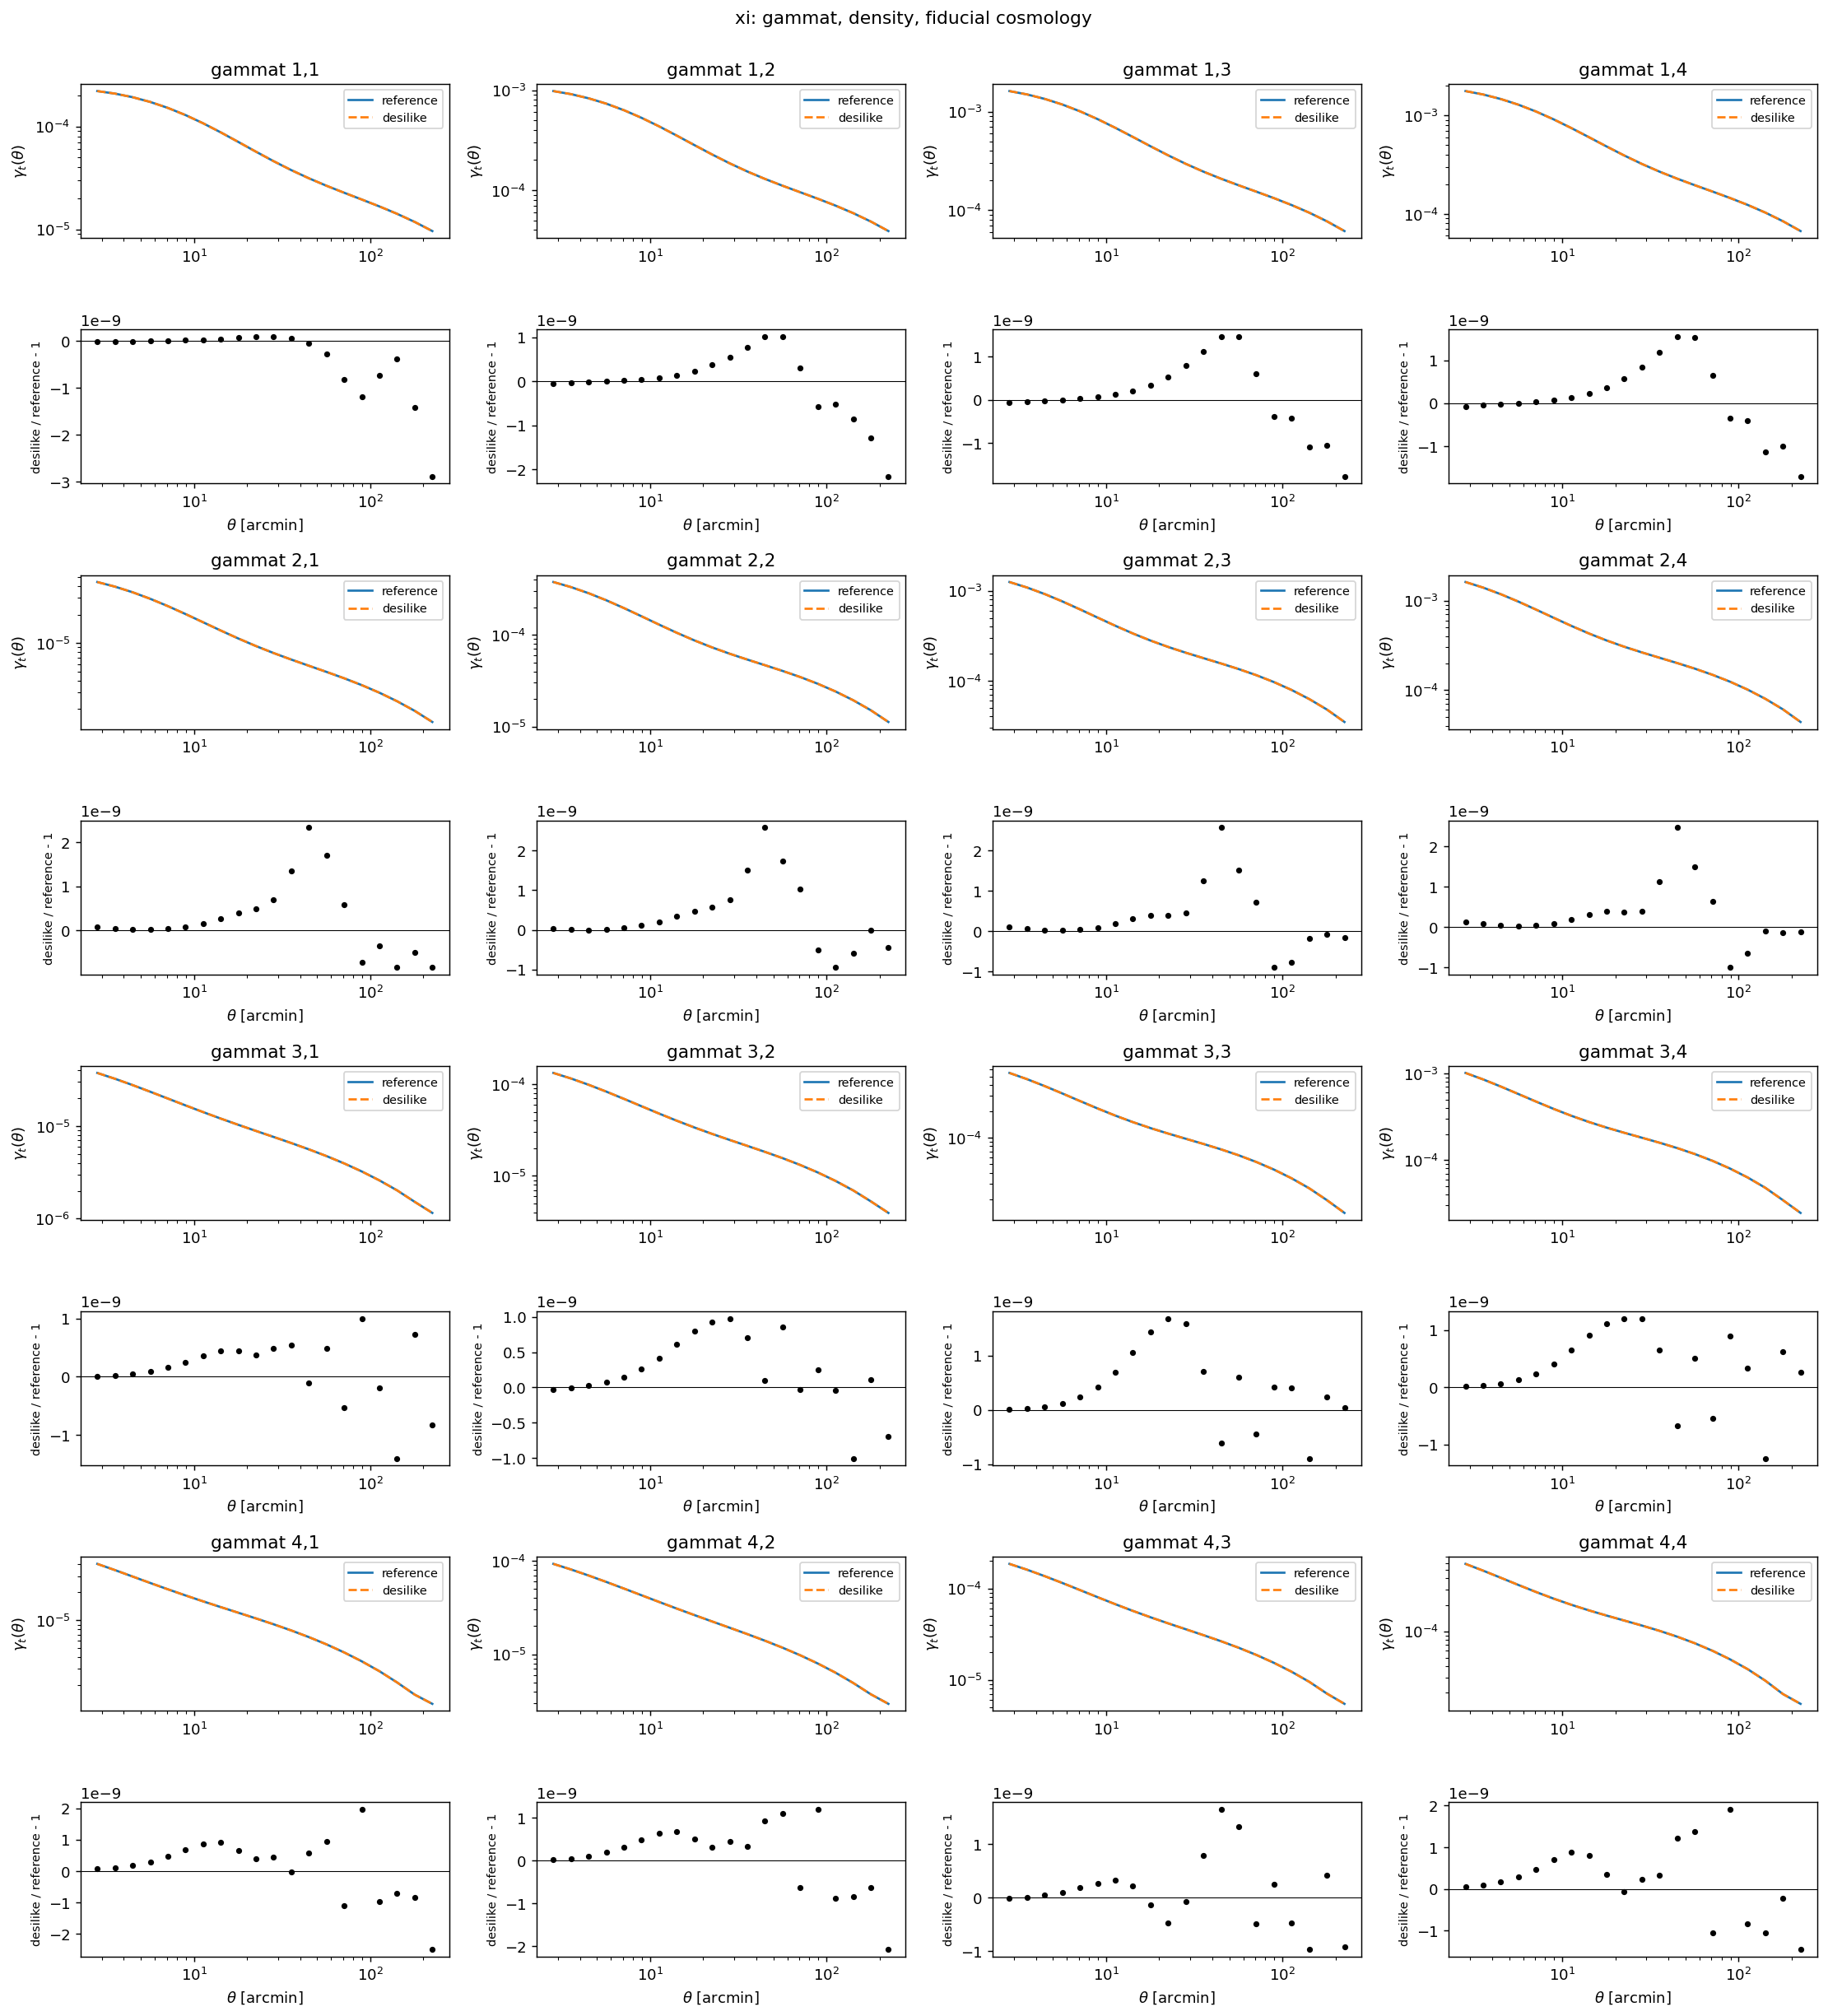

In [34]:
x = np.asarray(theta_bins)
first = fiducial["predictions"]["density"]["gammat"]
second = fiducial["references"]["density"]["corrs"][2]
pairs = PLOT_PAIRS["gammat"]
fig, axes = plt.subplots(8, 4, figsize=(17.2, 18.8), squeeze=False)
for ax in axes.flat:
    ax.set_visible(False)

for count, (i, j) in enumerate(pairs):
    row, col = (i, j)
    top, bottom = axes[2 * row, col], axes[2 * row + 1, col]
    top.set_visible(True)
    bottom.set_visible(True)
    a = np.asarray(first[i, j])
    b = np.asarray(second[i, j])
    mask = np.ones(x.size, dtype=bool)
    top.plot(x[mask], b[mask], label="reference")
    top.plot(x[mask], a[mask], "--", label="desilike")
    top.set_xscale("log")
    # Preserve negative values; use log-log axes when every value is positive.
    if np.any(a[mask] < 0) or np.any(b[mask] < 0):
        top.set_yscale("symlog", linthresh=max(np.max(np.abs(b)) * 1e-5, 1e-300))
    else:
        top.set_yscale("log")
    top.set_title(f"gammat {i+1},{j+1}")
    top.set_ylabel(r"$\gamma_t(\theta)$")
    top.legend(fontsize=8)

    valid = mask & (np.abs(b) > max(np.max(np.abs(b)) * 1e-12, 1e-300))
    delta = np.full_like(b, np.nan, dtype=float)
    np.divide(a - b, b, out=delta, where=valid)  # Do not plot ratios where the denominator crosses zero.
    axes[2 * row + 1, col].semilogx(x[valid], delta[valid], "ko", ms=3)
    bottom.axhline(0, color="black", lw=0.6)
    bottom.set_xlabel(r"$\theta$ [arcmin]")
    bottom.set_ylabel("desilike / reference - 1", fontsize=8)
    bottom.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

fig.suptitle("xi: gammat, density, fiducial cosmology", y=1.002)
fig.tight_layout()
fig.savefig(OUT / "xi_density_gammat.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)


### xip — xi — Weyl off:desilike / reference

/var/folders/f6/3xg83pv93rd82_jd1m8pv17r0000gn/T/ipykernel_16263/191078214.py:41: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


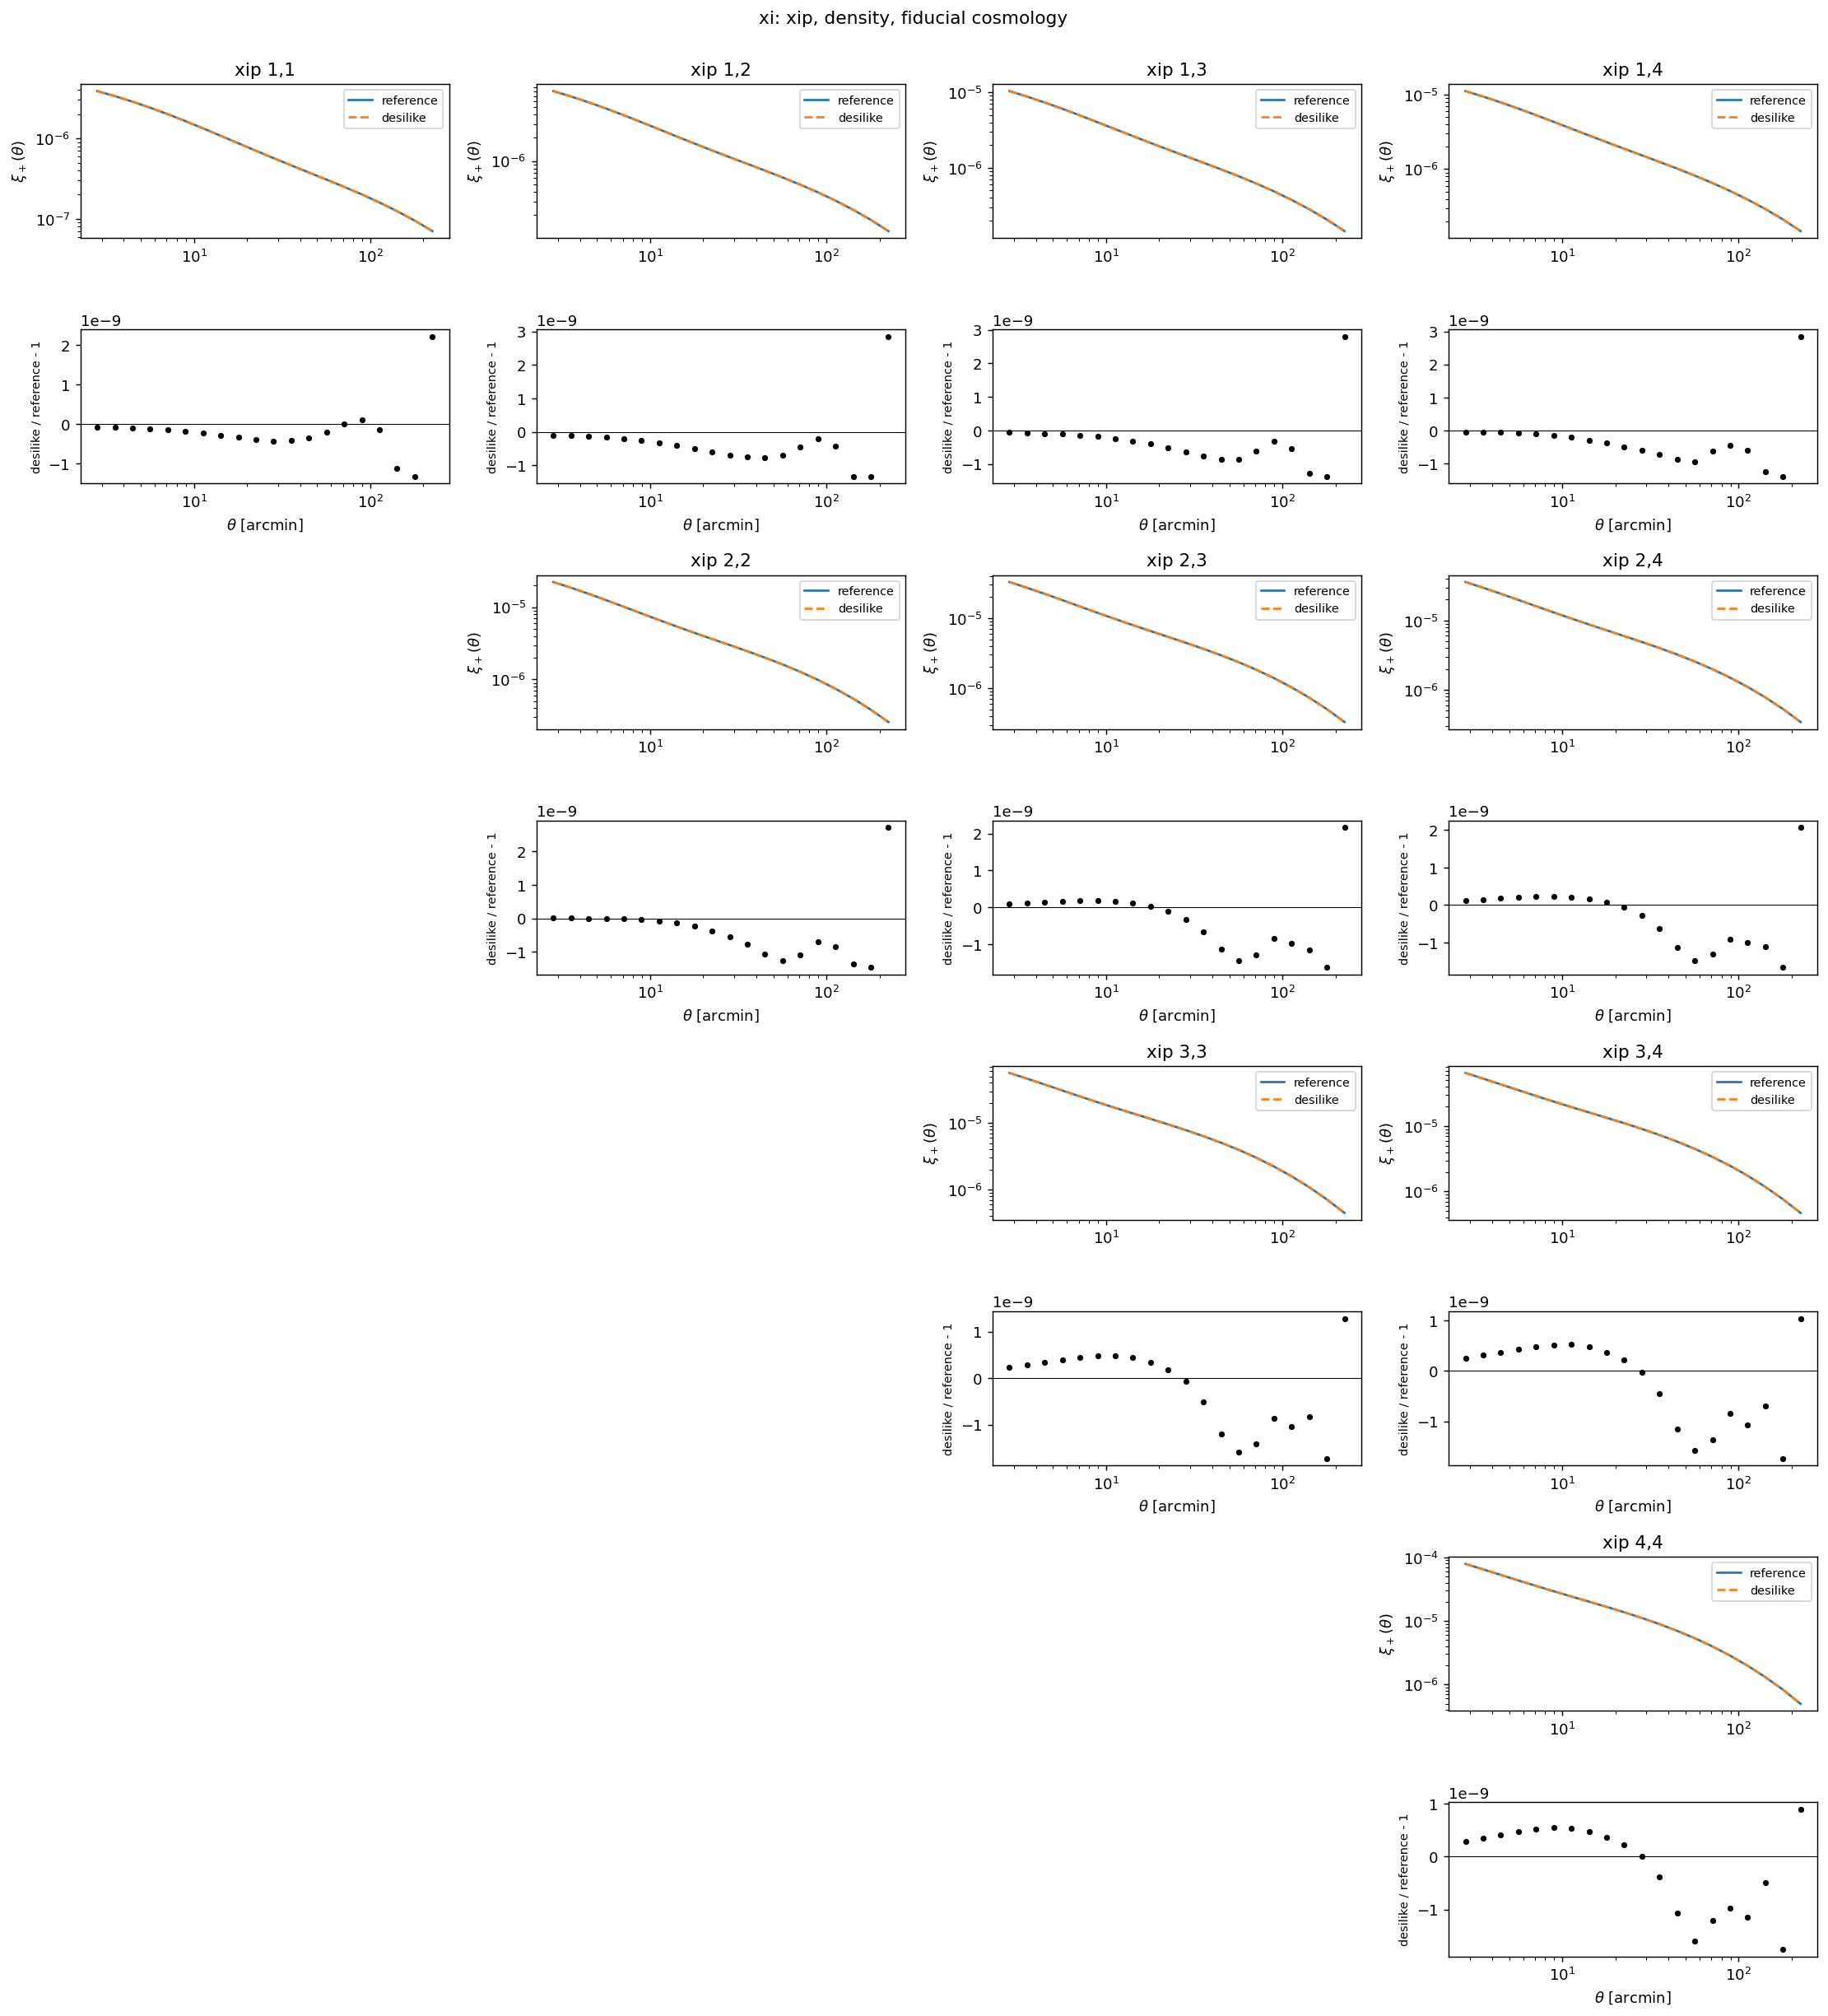

In [35]:
x = np.asarray(theta_bins)
first = fiducial["predictions"]["density"]["xip"]
second = fiducial["references"]["density"]["corrs"][0]
pairs = PLOT_PAIRS["xip"]
fig, axes = plt.subplots(8, 4, figsize=(17.2, 18.8), squeeze=False)
for ax in axes.flat:
    ax.set_visible(False)

for count, (i, j) in enumerate(pairs):
    row, col = (i, j)
    top, bottom = axes[2 * row, col], axes[2 * row + 1, col]
    top.set_visible(True)
    bottom.set_visible(True)
    a = np.asarray(first[i, j])
    b = np.asarray(second[i, j])
    mask = np.ones(x.size, dtype=bool)
    top.plot(x[mask], b[mask], label="reference")
    top.plot(x[mask], a[mask], "--", label="desilike")
    top.set_xscale("log")
    # Preserve negative values; use log-log axes when every value is positive.
    if np.any(a[mask] < 0) or np.any(b[mask] < 0):
        top.set_yscale("symlog", linthresh=max(np.max(np.abs(b)) * 1e-5, 1e-300))
    else:
        top.set_yscale("log")
    top.set_title(f"xip {i+1},{j+1}")
    top.set_ylabel(r"$\xi_+(\theta)$")
    top.legend(fontsize=8)

    valid = mask & (np.abs(b) > max(np.max(np.abs(b)) * 1e-12, 1e-300))
    delta = np.full_like(b, np.nan, dtype=float)
    np.divide(a - b, b, out=delta, where=valid)  # Do not plot ratios where the denominator crosses zero.
    axes[2 * row + 1, col].semilogx(x[valid], delta[valid], "ko", ms=3)
    bottom.axhline(0, color="black", lw=0.6)
    bottom.set_xlabel(r"$\theta$ [arcmin]")
    bottom.set_ylabel("desilike / reference - 1", fontsize=8)
    bottom.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

fig.suptitle("xi: xip, density, fiducial cosmology", y=1.002)
fig.tight_layout()
fig.savefig(OUT / "xi_density_xip.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)


### xim — xi — Weyl off:desilike / reference

/var/folders/f6/3xg83pv93rd82_jd1m8pv17r0000gn/T/ipykernel_16263/1902327094.py:41: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


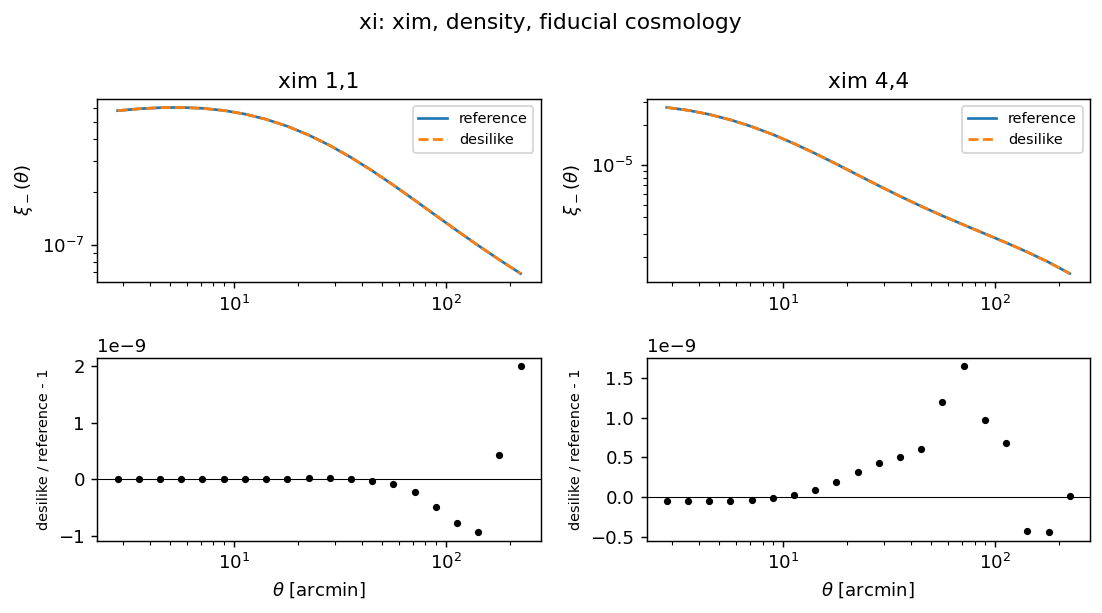

In [36]:
x = np.asarray(theta_bins)
first = fiducial["predictions"]["density"]["xim"]
second = fiducial["references"]["density"]["corrs"][1]
pairs = PLOT_PAIRS["xim"]
fig, axes = plt.subplots(2, 2, figsize=(8.6, 4.7), squeeze=False)
for ax in axes.flat:
    ax.set_visible(False)

for count, (i, j) in enumerate(pairs):
    row, col = (0, count)
    top, bottom = axes[2 * row, col], axes[2 * row + 1, col]
    top.set_visible(True)
    bottom.set_visible(True)
    a = np.asarray(first[i, j])
    b = np.asarray(second[i, j])
    mask = np.ones(x.size, dtype=bool)
    top.plot(x[mask], b[mask], label="reference")
    top.plot(x[mask], a[mask], "--", label="desilike")
    top.set_xscale("log")
    # Preserve negative values; use log-log axes when every value is positive.
    if np.any(a[mask] < 0) or np.any(b[mask] < 0):
        top.set_yscale("symlog", linthresh=max(np.max(np.abs(b)) * 1e-5, 1e-300))
    else:
        top.set_yscale("log")
    top.set_title(f"xim {i+1},{j+1}")
    top.set_ylabel(r"$\xi_-(\theta)$")
    top.legend(fontsize=8)

    valid = mask & (np.abs(b) > max(np.max(np.abs(b)) * 1e-12, 1e-300))
    delta = np.full_like(b, np.nan, dtype=float)
    np.divide(a - b, b, out=delta, where=valid)  # Do not plot ratios where the denominator crosses zero.
    axes[2 * row + 1, col].semilogx(x[valid], delta[valid], "ko", ms=3)
    bottom.axhline(0, color="black", lw=0.6)
    bottom.set_xlabel(r"$\theta$ [arcmin]")
    bottom.set_ylabel("desilike / reference - 1", fontsize=8)
    bottom.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

fig.suptitle("xi: xim, density, fiducial cosmology", y=1.002)
fig.tight_layout()
fig.savefig(OUT / "xi_density_xim.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)


### wtheta — xi — Weyl on:desilike / reference

/var/folders/f6/3xg83pv93rd82_jd1m8pv17r0000gn/T/ipykernel_16263/2788574844.py:41: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


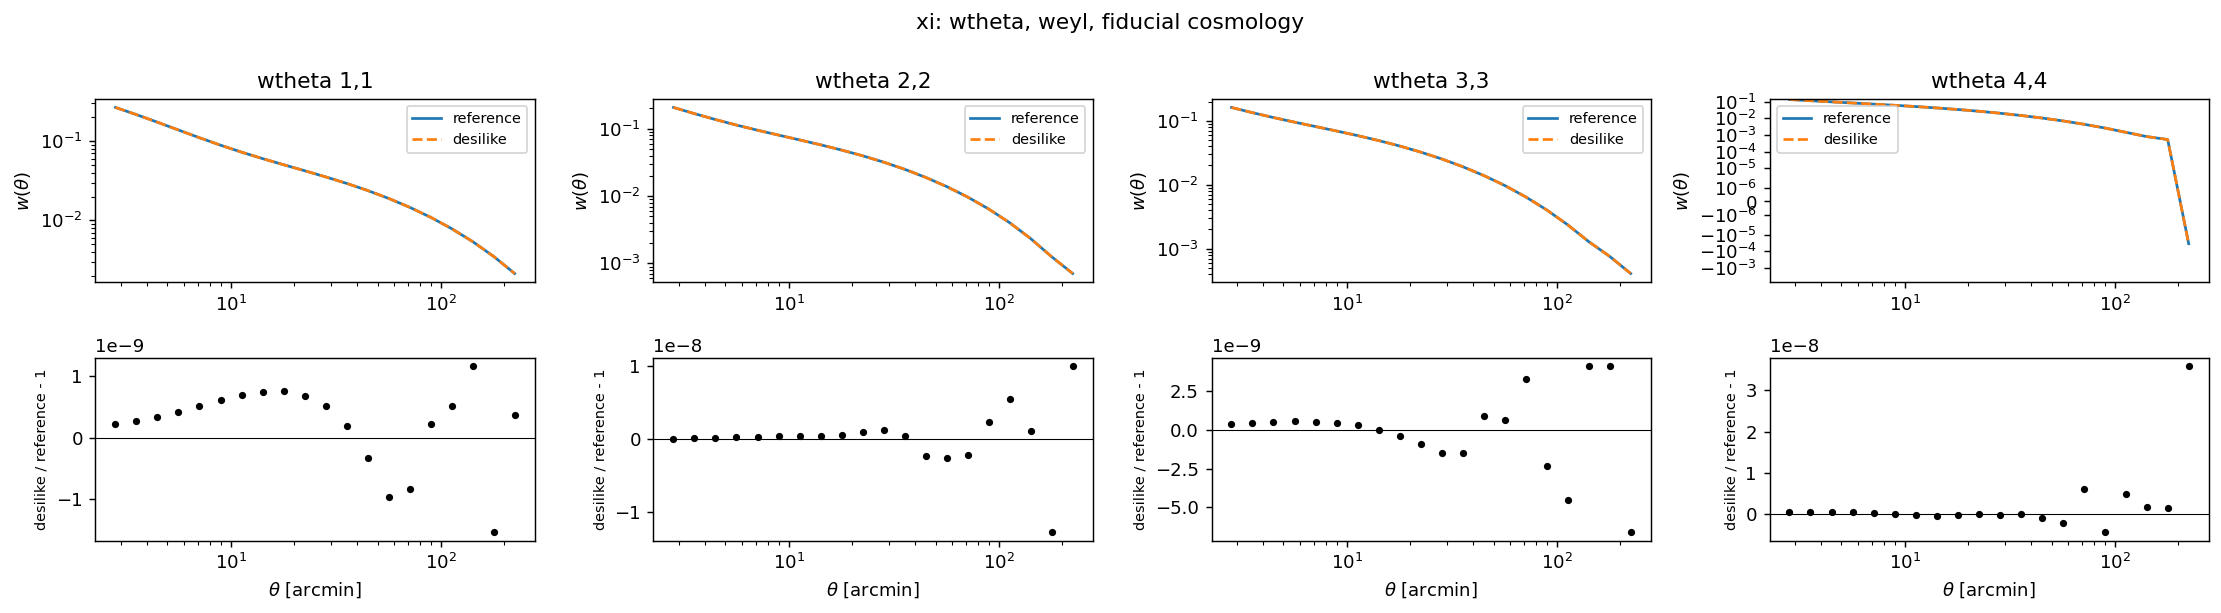

In [37]:
x = np.asarray(theta_bins)
first = fiducial["predictions"]["weyl"]["wtheta"]
second = fiducial["references"]["weyl"]["corrs"][3]
pairs = PLOT_PAIRS["wtheta"]
fig, axes = plt.subplots(2, 4, figsize=(17.2, 4.7), squeeze=False)
for ax in axes.flat:
    ax.set_visible(False)

for count, (i, j) in enumerate(pairs):
    row, col = (0, count)
    top, bottom = axes[2 * row, col], axes[2 * row + 1, col]
    top.set_visible(True)
    bottom.set_visible(True)
    a = np.asarray(first[i, j])
    b = np.asarray(second[i, j])
    mask = np.ones(x.size, dtype=bool)
    top.plot(x[mask], b[mask], label="reference")
    top.plot(x[mask], a[mask], "--", label="desilike")
    top.set_xscale("log")
    # Preserve negative values; use log-log axes when every value is positive.
    if np.any(a[mask] < 0) or np.any(b[mask] < 0):
        top.set_yscale("symlog", linthresh=max(np.max(np.abs(b)) * 1e-5, 1e-300))
    else:
        top.set_yscale("log")
    top.set_title(f"wtheta {i+1},{j+1}")
    top.set_ylabel(r"$w(\theta)$")
    top.legend(fontsize=8)

    valid = mask & (np.abs(b) > max(np.max(np.abs(b)) * 1e-12, 1e-300))
    delta = np.full_like(b, np.nan, dtype=float)
    np.divide(a - b, b, out=delta, where=valid)  # Do not plot ratios where the denominator crosses zero.
    axes[2 * row + 1, col].semilogx(x[valid], delta[valid], "ko", ms=3)
    bottom.axhline(0, color="black", lw=0.6)
    bottom.set_xlabel(r"$\theta$ [arcmin]")
    bottom.set_ylabel("desilike / reference - 1", fontsize=8)
    bottom.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

fig.suptitle("xi: wtheta, weyl, fiducial cosmology", y=1.002)
fig.tight_layout()
fig.savefig(OUT / "xi_weyl_wtheta.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)


### gammat — xi — Weyl on:desilike / reference

/var/folders/f6/3xg83pv93rd82_jd1m8pv17r0000gn/T/ipykernel_16263/578988335.py:41: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


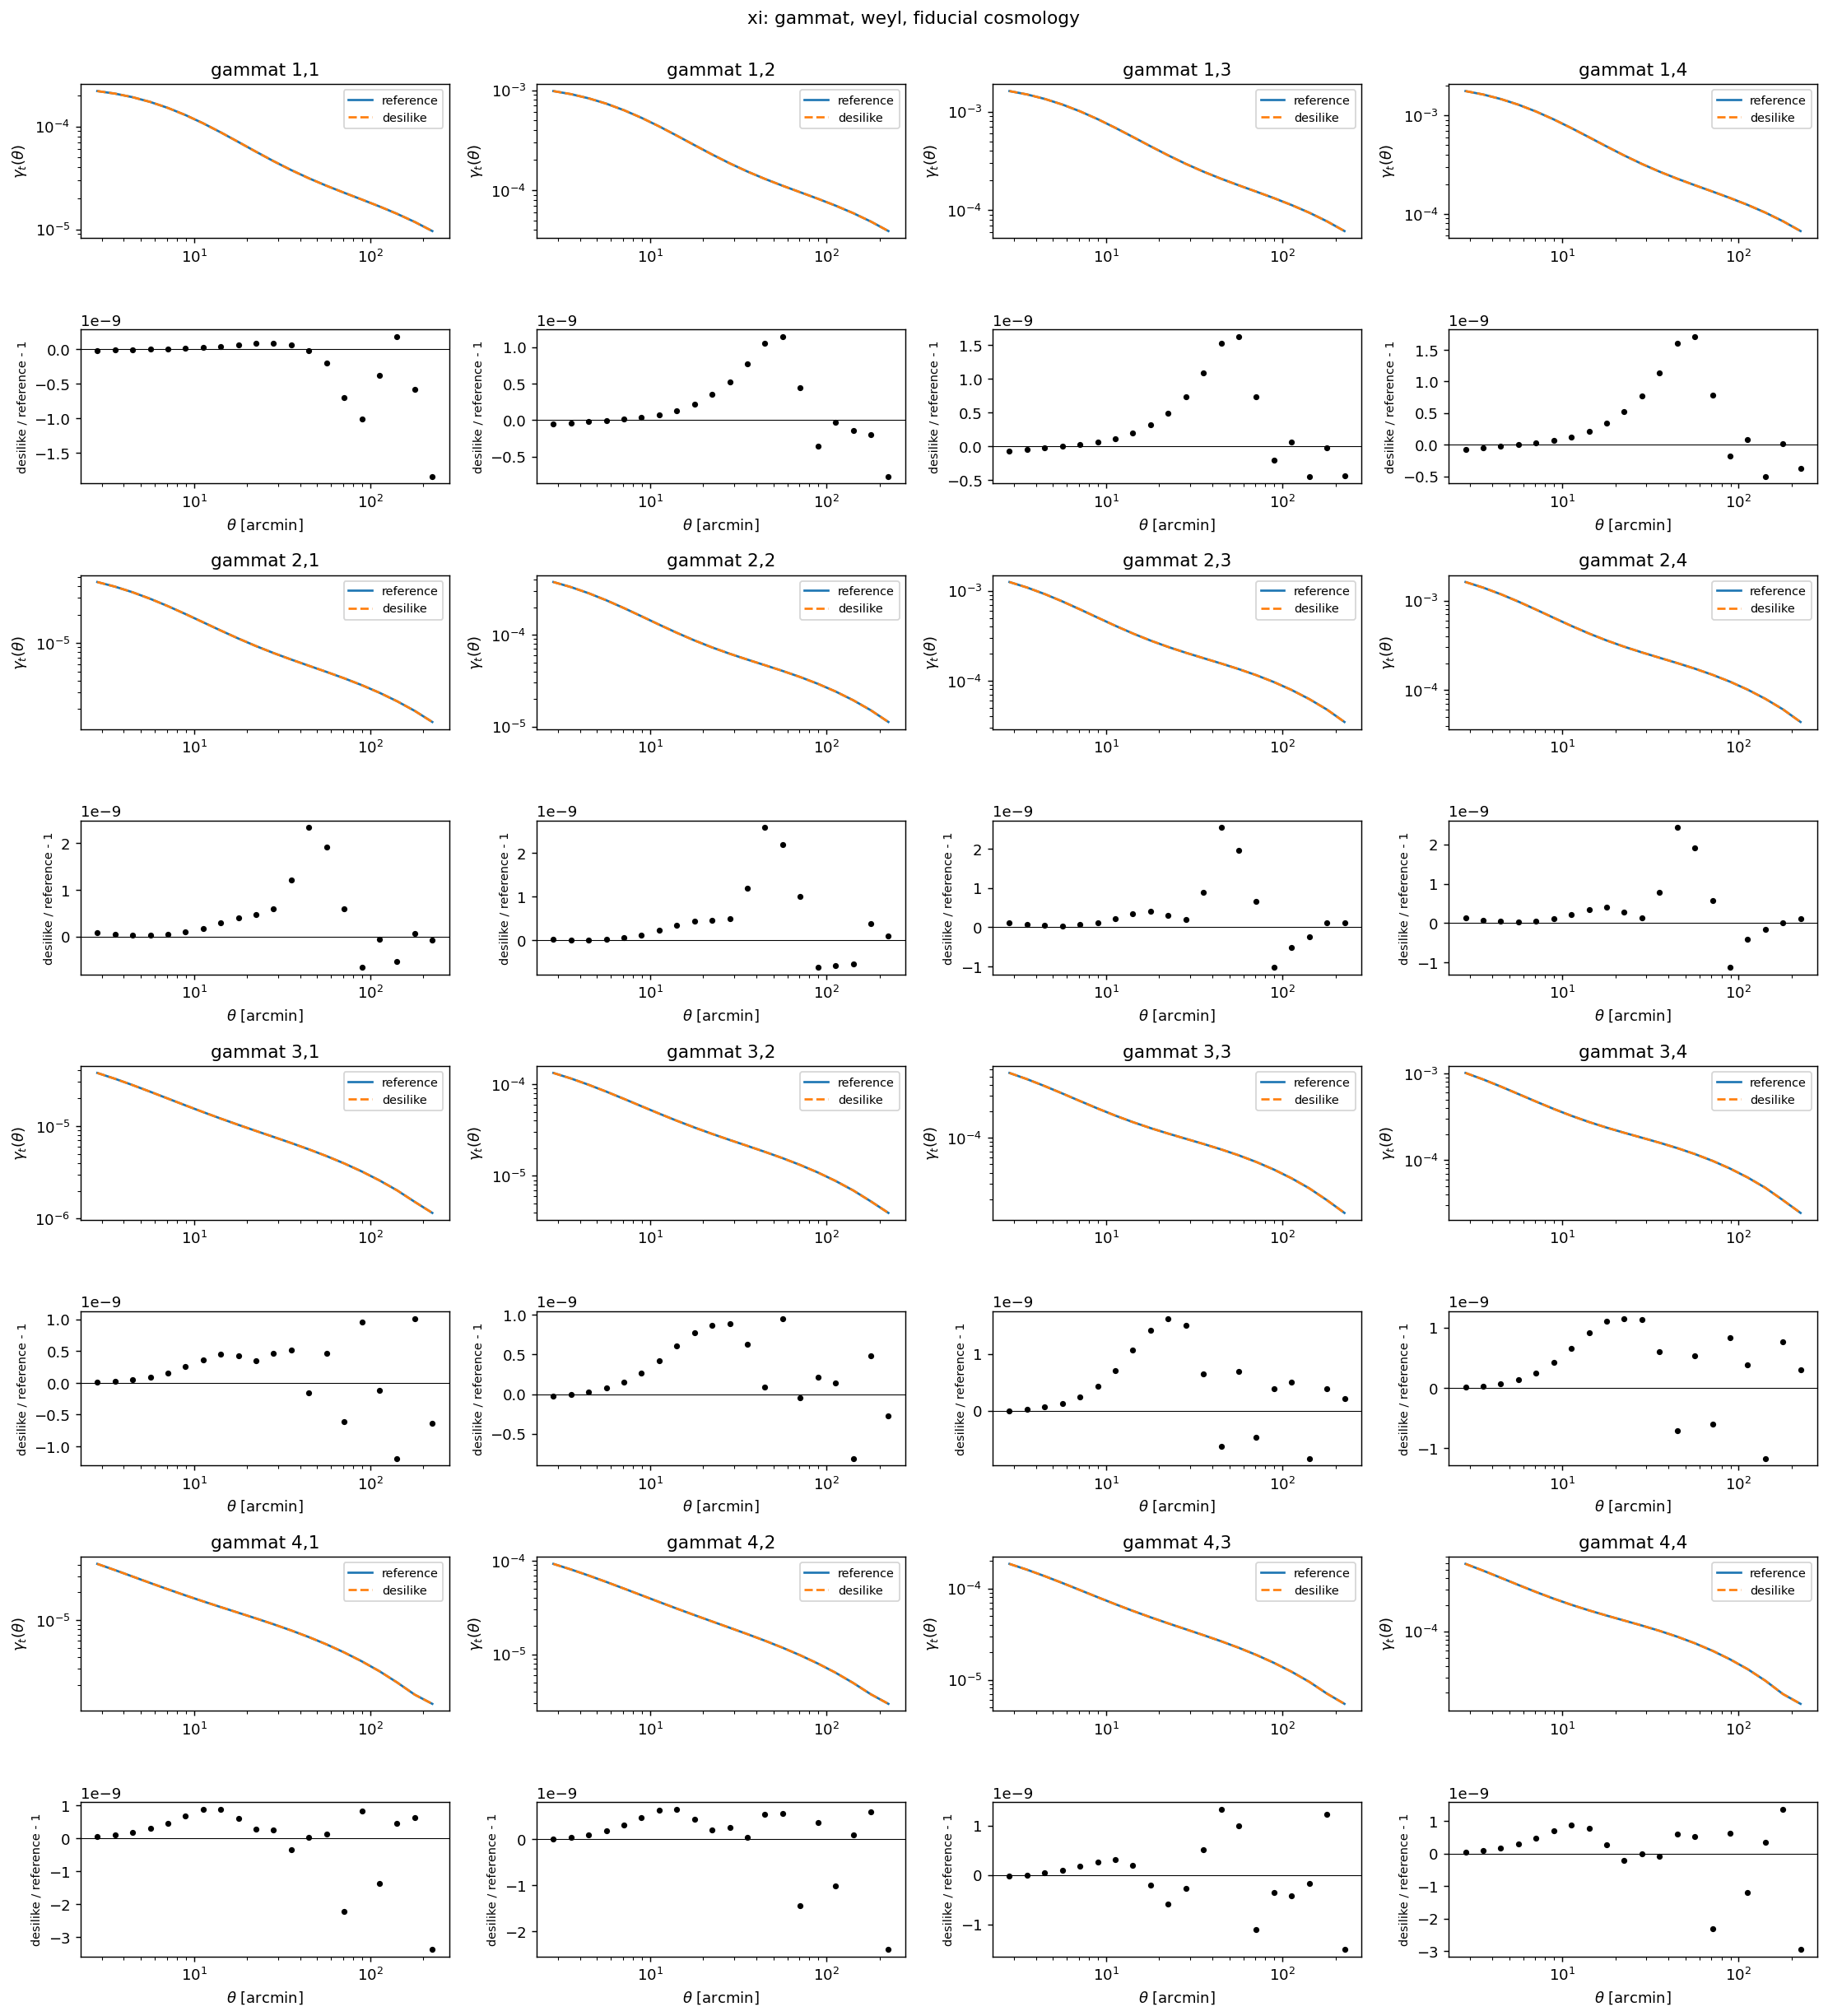

In [38]:
x = np.asarray(theta_bins)
first = fiducial["predictions"]["weyl"]["gammat"]
second = fiducial["references"]["weyl"]["corrs"][2]
pairs = PLOT_PAIRS["gammat"]
fig, axes = plt.subplots(8, 4, figsize=(17.2, 18.8), squeeze=False)
for ax in axes.flat:
    ax.set_visible(False)

for count, (i, j) in enumerate(pairs):
    row, col = (i, j)
    top, bottom = axes[2 * row, col], axes[2 * row + 1, col]
    top.set_visible(True)
    bottom.set_visible(True)
    a = np.asarray(first[i, j])
    b = np.asarray(second[i, j])
    mask = np.ones(x.size, dtype=bool)
    top.plot(x[mask], b[mask], label="reference")
    top.plot(x[mask], a[mask], "--", label="desilike")
    top.set_xscale("log")
    # Preserve negative values; use log-log axes when every value is positive.
    if np.any(a[mask] < 0) or np.any(b[mask] < 0):
        top.set_yscale("symlog", linthresh=max(np.max(np.abs(b)) * 1e-5, 1e-300))
    else:
        top.set_yscale("log")
    top.set_title(f"gammat {i+1},{j+1}")
    top.set_ylabel(r"$\gamma_t(\theta)$")
    top.legend(fontsize=8)

    valid = mask & (np.abs(b) > max(np.max(np.abs(b)) * 1e-12, 1e-300))
    delta = np.full_like(b, np.nan, dtype=float)
    np.divide(a - b, b, out=delta, where=valid)  # Do not plot ratios where the denominator crosses zero.
    axes[2 * row + 1, col].semilogx(x[valid], delta[valid], "ko", ms=3)
    bottom.axhline(0, color="black", lw=0.6)
    bottom.set_xlabel(r"$\theta$ [arcmin]")
    bottom.set_ylabel("desilike / reference - 1", fontsize=8)
    bottom.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

fig.suptitle("xi: gammat, weyl, fiducial cosmology", y=1.002)
fig.tight_layout()
fig.savefig(OUT / "xi_weyl_gammat.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)


### xip — xi — Weyl on:desilike / reference

/var/folders/f6/3xg83pv93rd82_jd1m8pv17r0000gn/T/ipykernel_16263/2580399263.py:41: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


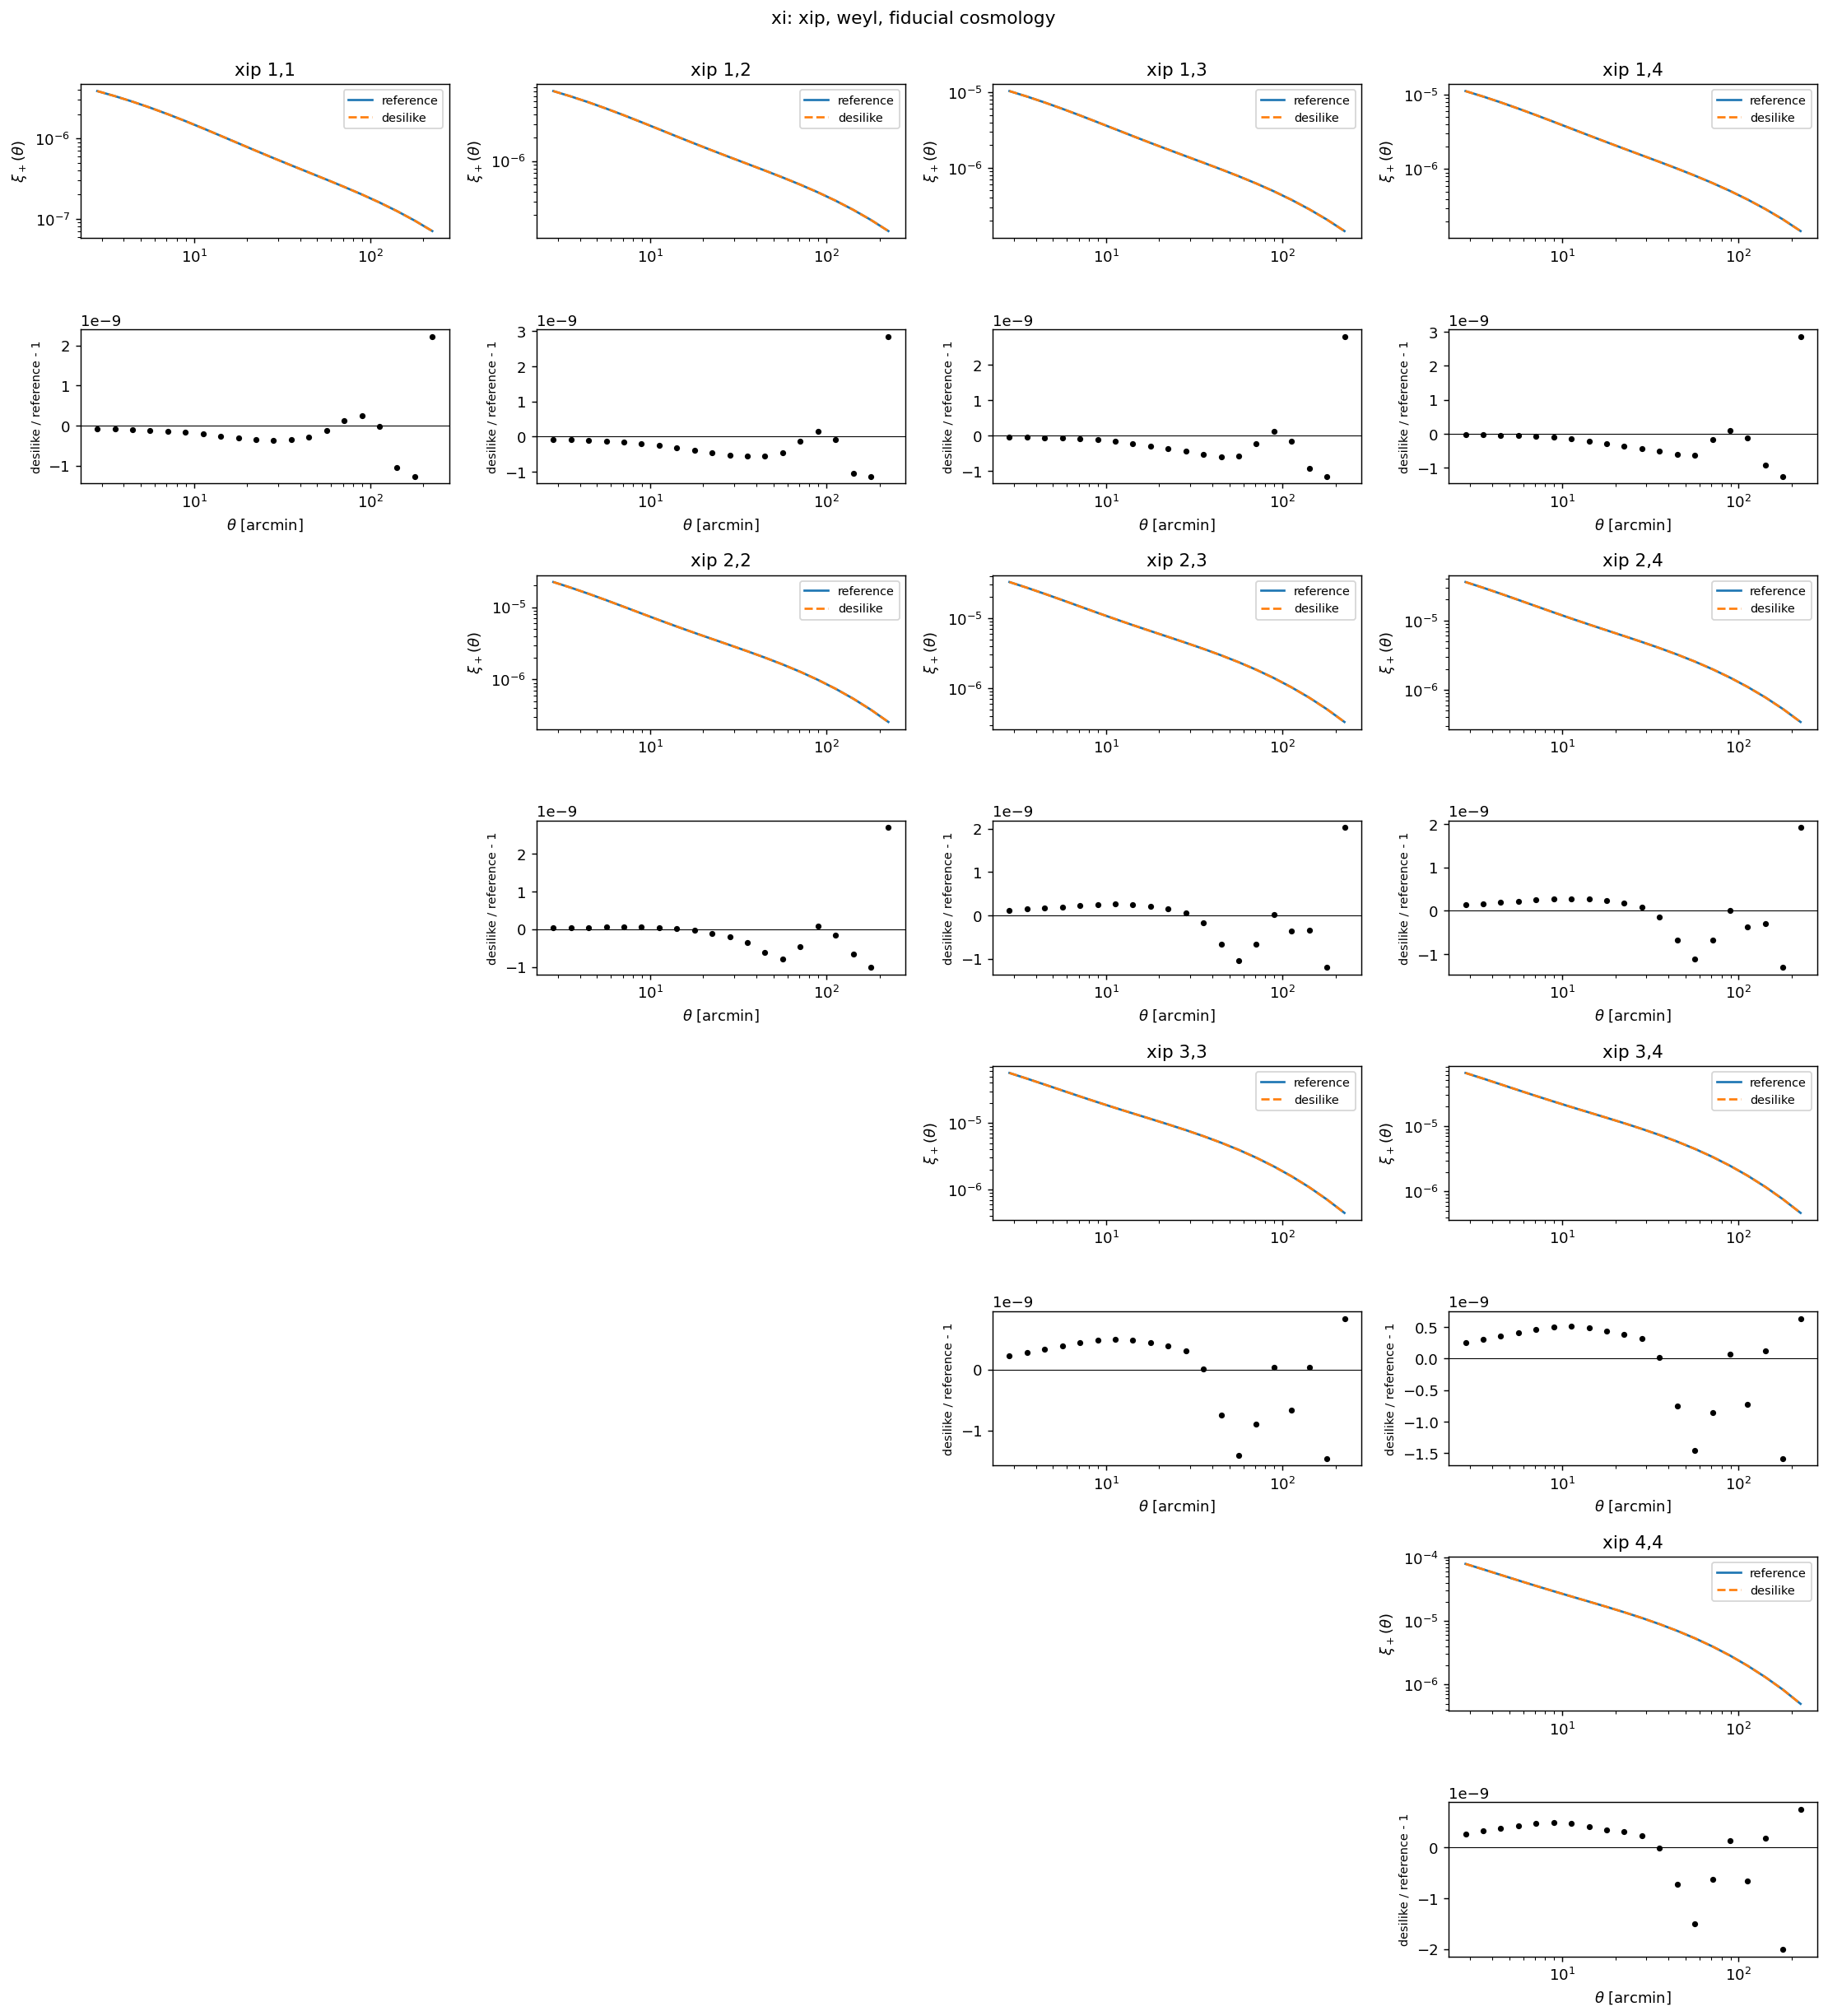

In [39]:
x = np.asarray(theta_bins)
first = fiducial["predictions"]["weyl"]["xip"]
second = fiducial["references"]["weyl"]["corrs"][0]
pairs = PLOT_PAIRS["xip"]
fig, axes = plt.subplots(8, 4, figsize=(17.2, 18.8), squeeze=False)
for ax in axes.flat:
    ax.set_visible(False)

for count, (i, j) in enumerate(pairs):
    row, col = (i, j)
    top, bottom = axes[2 * row, col], axes[2 * row + 1, col]
    top.set_visible(True)
    bottom.set_visible(True)
    a = np.asarray(first[i, j])
    b = np.asarray(second[i, j])
    mask = np.ones(x.size, dtype=bool)
    top.plot(x[mask], b[mask], label="reference")
    top.plot(x[mask], a[mask], "--", label="desilike")
    top.set_xscale("log")
    # Preserve negative values; use log-log axes when every value is positive.
    if np.any(a[mask] < 0) or np.any(b[mask] < 0):
        top.set_yscale("symlog", linthresh=max(np.max(np.abs(b)) * 1e-5, 1e-300))
    else:
        top.set_yscale("log")
    top.set_title(f"xip {i+1},{j+1}")
    top.set_ylabel(r"$\xi_+(\theta)$")
    top.legend(fontsize=8)

    valid = mask & (np.abs(b) > max(np.max(np.abs(b)) * 1e-12, 1e-300))
    delta = np.full_like(b, np.nan, dtype=float)
    np.divide(a - b, b, out=delta, where=valid)  # Do not plot ratios where the denominator crosses zero.
    axes[2 * row + 1, col].semilogx(x[valid], delta[valid], "ko", ms=3)
    bottom.axhline(0, color="black", lw=0.6)
    bottom.set_xlabel(r"$\theta$ [arcmin]")
    bottom.set_ylabel("desilike / reference - 1", fontsize=8)
    bottom.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

fig.suptitle("xi: xip, weyl, fiducial cosmology", y=1.002)
fig.tight_layout()
fig.savefig(OUT / "xi_weyl_xip.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)


### xim — xi — Weyl on:desilike / reference

/var/folders/f6/3xg83pv93rd82_jd1m8pv17r0000gn/T/ipykernel_16263/1872183672.py:41: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


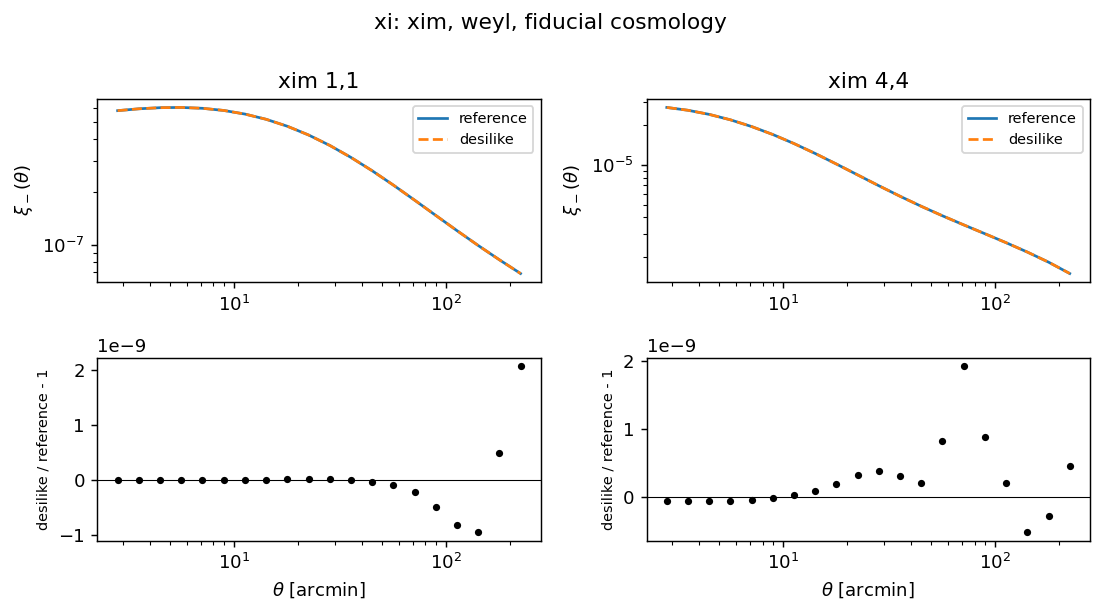

In [40]:
x = np.asarray(theta_bins)
first = fiducial["predictions"]["weyl"]["xim"]
second = fiducial["references"]["weyl"]["corrs"][1]
pairs = PLOT_PAIRS["xim"]
fig, axes = plt.subplots(2, 2, figsize=(8.6, 4.7), squeeze=False)
for ax in axes.flat:
    ax.set_visible(False)

for count, (i, j) in enumerate(pairs):
    row, col = (0, count)
    top, bottom = axes[2 * row, col], axes[2 * row + 1, col]
    top.set_visible(True)
    bottom.set_visible(True)
    a = np.asarray(first[i, j])
    b = np.asarray(second[i, j])
    mask = np.ones(x.size, dtype=bool)
    top.plot(x[mask], b[mask], label="reference")
    top.plot(x[mask], a[mask], "--", label="desilike")
    top.set_xscale("log")
    # Preserve negative values; use log-log axes when every value is positive.
    if np.any(a[mask] < 0) or np.any(b[mask] < 0):
        top.set_yscale("symlog", linthresh=max(np.max(np.abs(b)) * 1e-5, 1e-300))
    else:
        top.set_yscale("log")
    top.set_title(f"xim {i+1},{j+1}")
    top.set_ylabel(r"$\xi_-(\theta)$")
    top.legend(fontsize=8)

    valid = mask & (np.abs(b) > max(np.max(np.abs(b)) * 1e-12, 1e-300))
    delta = np.full_like(b, np.nan, dtype=float)
    np.divide(a - b, b, out=delta, where=valid)  # Do not plot ratios where the denominator crosses zero.
    axes[2 * row + 1, col].semilogx(x[valid], delta[valid], "ko", ms=3)
    bottom.axhline(0, color="black", lw=0.6)
    bottom.set_xlabel(r"$\theta$ [arcmin]")
    bottom.set_ylabel("desilike / reference - 1", fontsize=8)
    bottom.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

fig.suptitle("xi: xim, weyl, fiducial cosmology", y=1.002)
fig.tight_layout()
fig.savefig(OUT / "xi_weyl_xim.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)


## 6. Weyl on/off

Use the same bin-pair layout, with Weyl / density − 1 in the lower panels.

### wtheta — Cl — desilike: Weyl on/off

/var/folders/f6/3xg83pv93rd82_jd1m8pv17r0000gn/T/ipykernel_16263/235937490.py:41: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


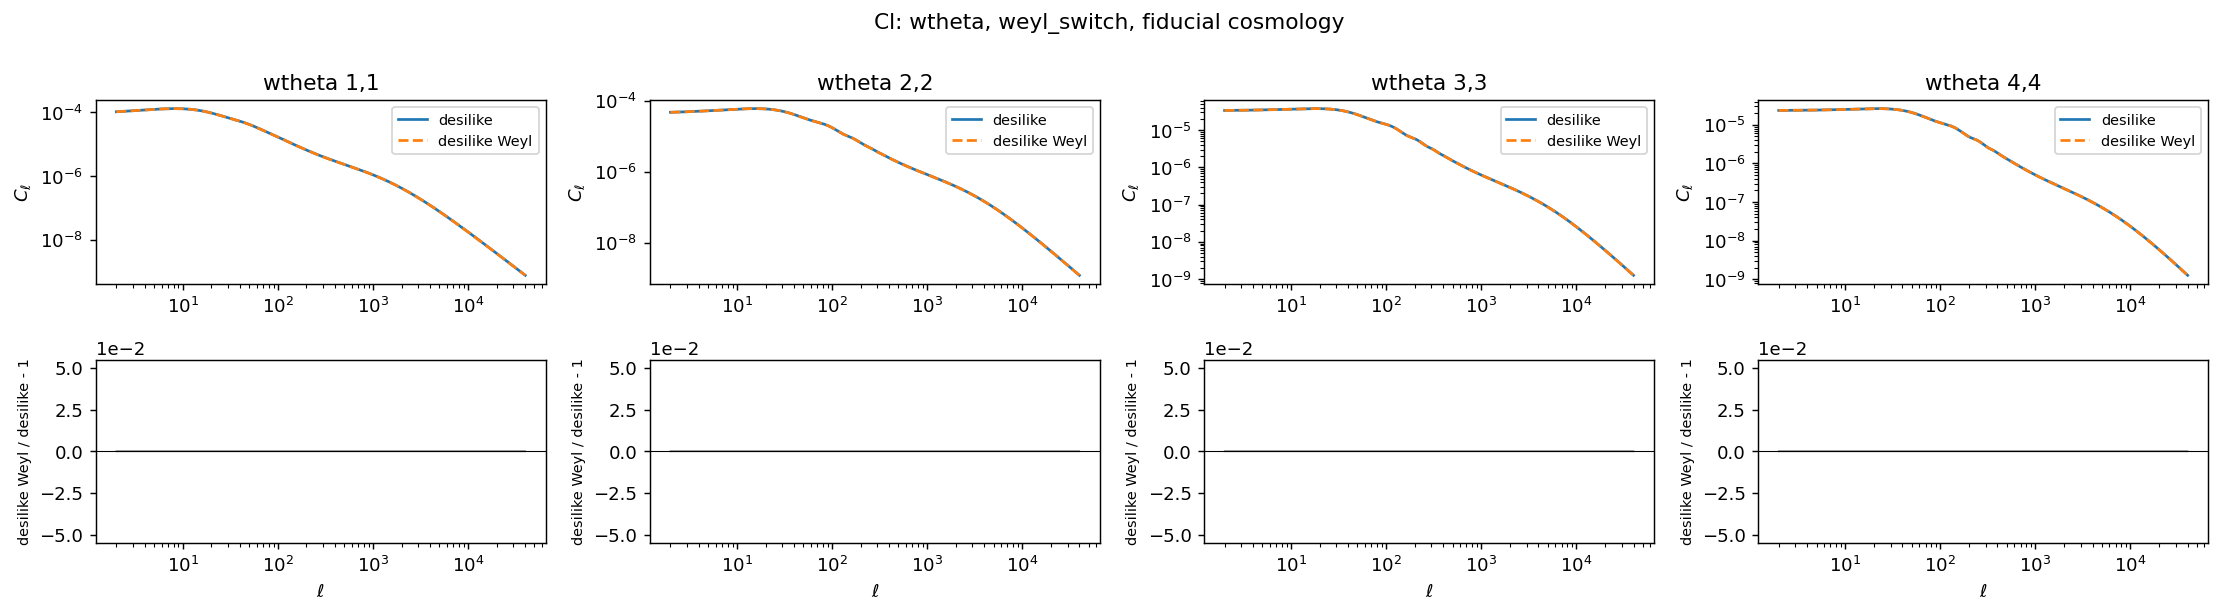

In [41]:
x = np.asarray(fiducial["predictions"]["density"]["ell"])
first = fiducial["predictions"]["weyl"]["cl_wtheta"]
second = fiducial["predictions"]["density"]["cl_wtheta"]
pairs = PLOT_PAIRS["wtheta"]
fig, axes = plt.subplots(2, 4, figsize=(17.2, 4.7), squeeze=False)
for ax in axes.flat:
    ax.set_visible(False)

for count, (i, j) in enumerate(pairs):
    row, col = (0, count)
    top, bottom = axes[2 * row, col], axes[2 * row + 1, col]
    top.set_visible(True)
    bottom.set_visible(True)
    a = np.asarray(first[i, j])
    b = np.asarray(second[i, j])
    mask = x >= 2
    top.plot(x[mask], b[mask], label="desilike")
    top.plot(x[mask], a[mask], "--", label="desilike Weyl")
    top.set_xscale("log")
    # Preserve negative values; use log-log axes when every value is positive.
    if np.any(a[mask] < 0) or np.any(b[mask] < 0):
        top.set_yscale("symlog", linthresh=max(np.max(np.abs(b)) * 1e-5, 1e-300))
    else:
        top.set_yscale("log")
    top.set_title(f"wtheta {i+1},{j+1}")
    top.set_ylabel(r"$C_\ell$")
    top.legend(fontsize=8)

    valid = mask & (np.abs(b) > max(np.max(np.abs(b)) * 1e-12, 1e-300))
    delta = np.full_like(b, np.nan, dtype=float)
    np.divide(a - b, b, out=delta, where=valid)  # Do not plot ratios where the denominator crosses zero.
    axes[2 * row + 1, col].semilogx(x[valid], delta[valid], color="black", lw=0.8)
    bottom.axhline(0, color="black", lw=0.6)
    bottom.set_xlabel(r"$\ell$")
    bottom.set_ylabel("desilike Weyl / desilike - 1", fontsize=8)
    bottom.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

fig.suptitle("Cl: wtheta, weyl_switch, fiducial cosmology", y=1.002)
fig.tight_layout()
fig.savefig(OUT / "Cl_weyl_switch_wtheta.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)


### gammat — Cl — desilike: Weyl on/off

/var/folders/f6/3xg83pv93rd82_jd1m8pv17r0000gn/T/ipykernel_16263/2487114955.py:41: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


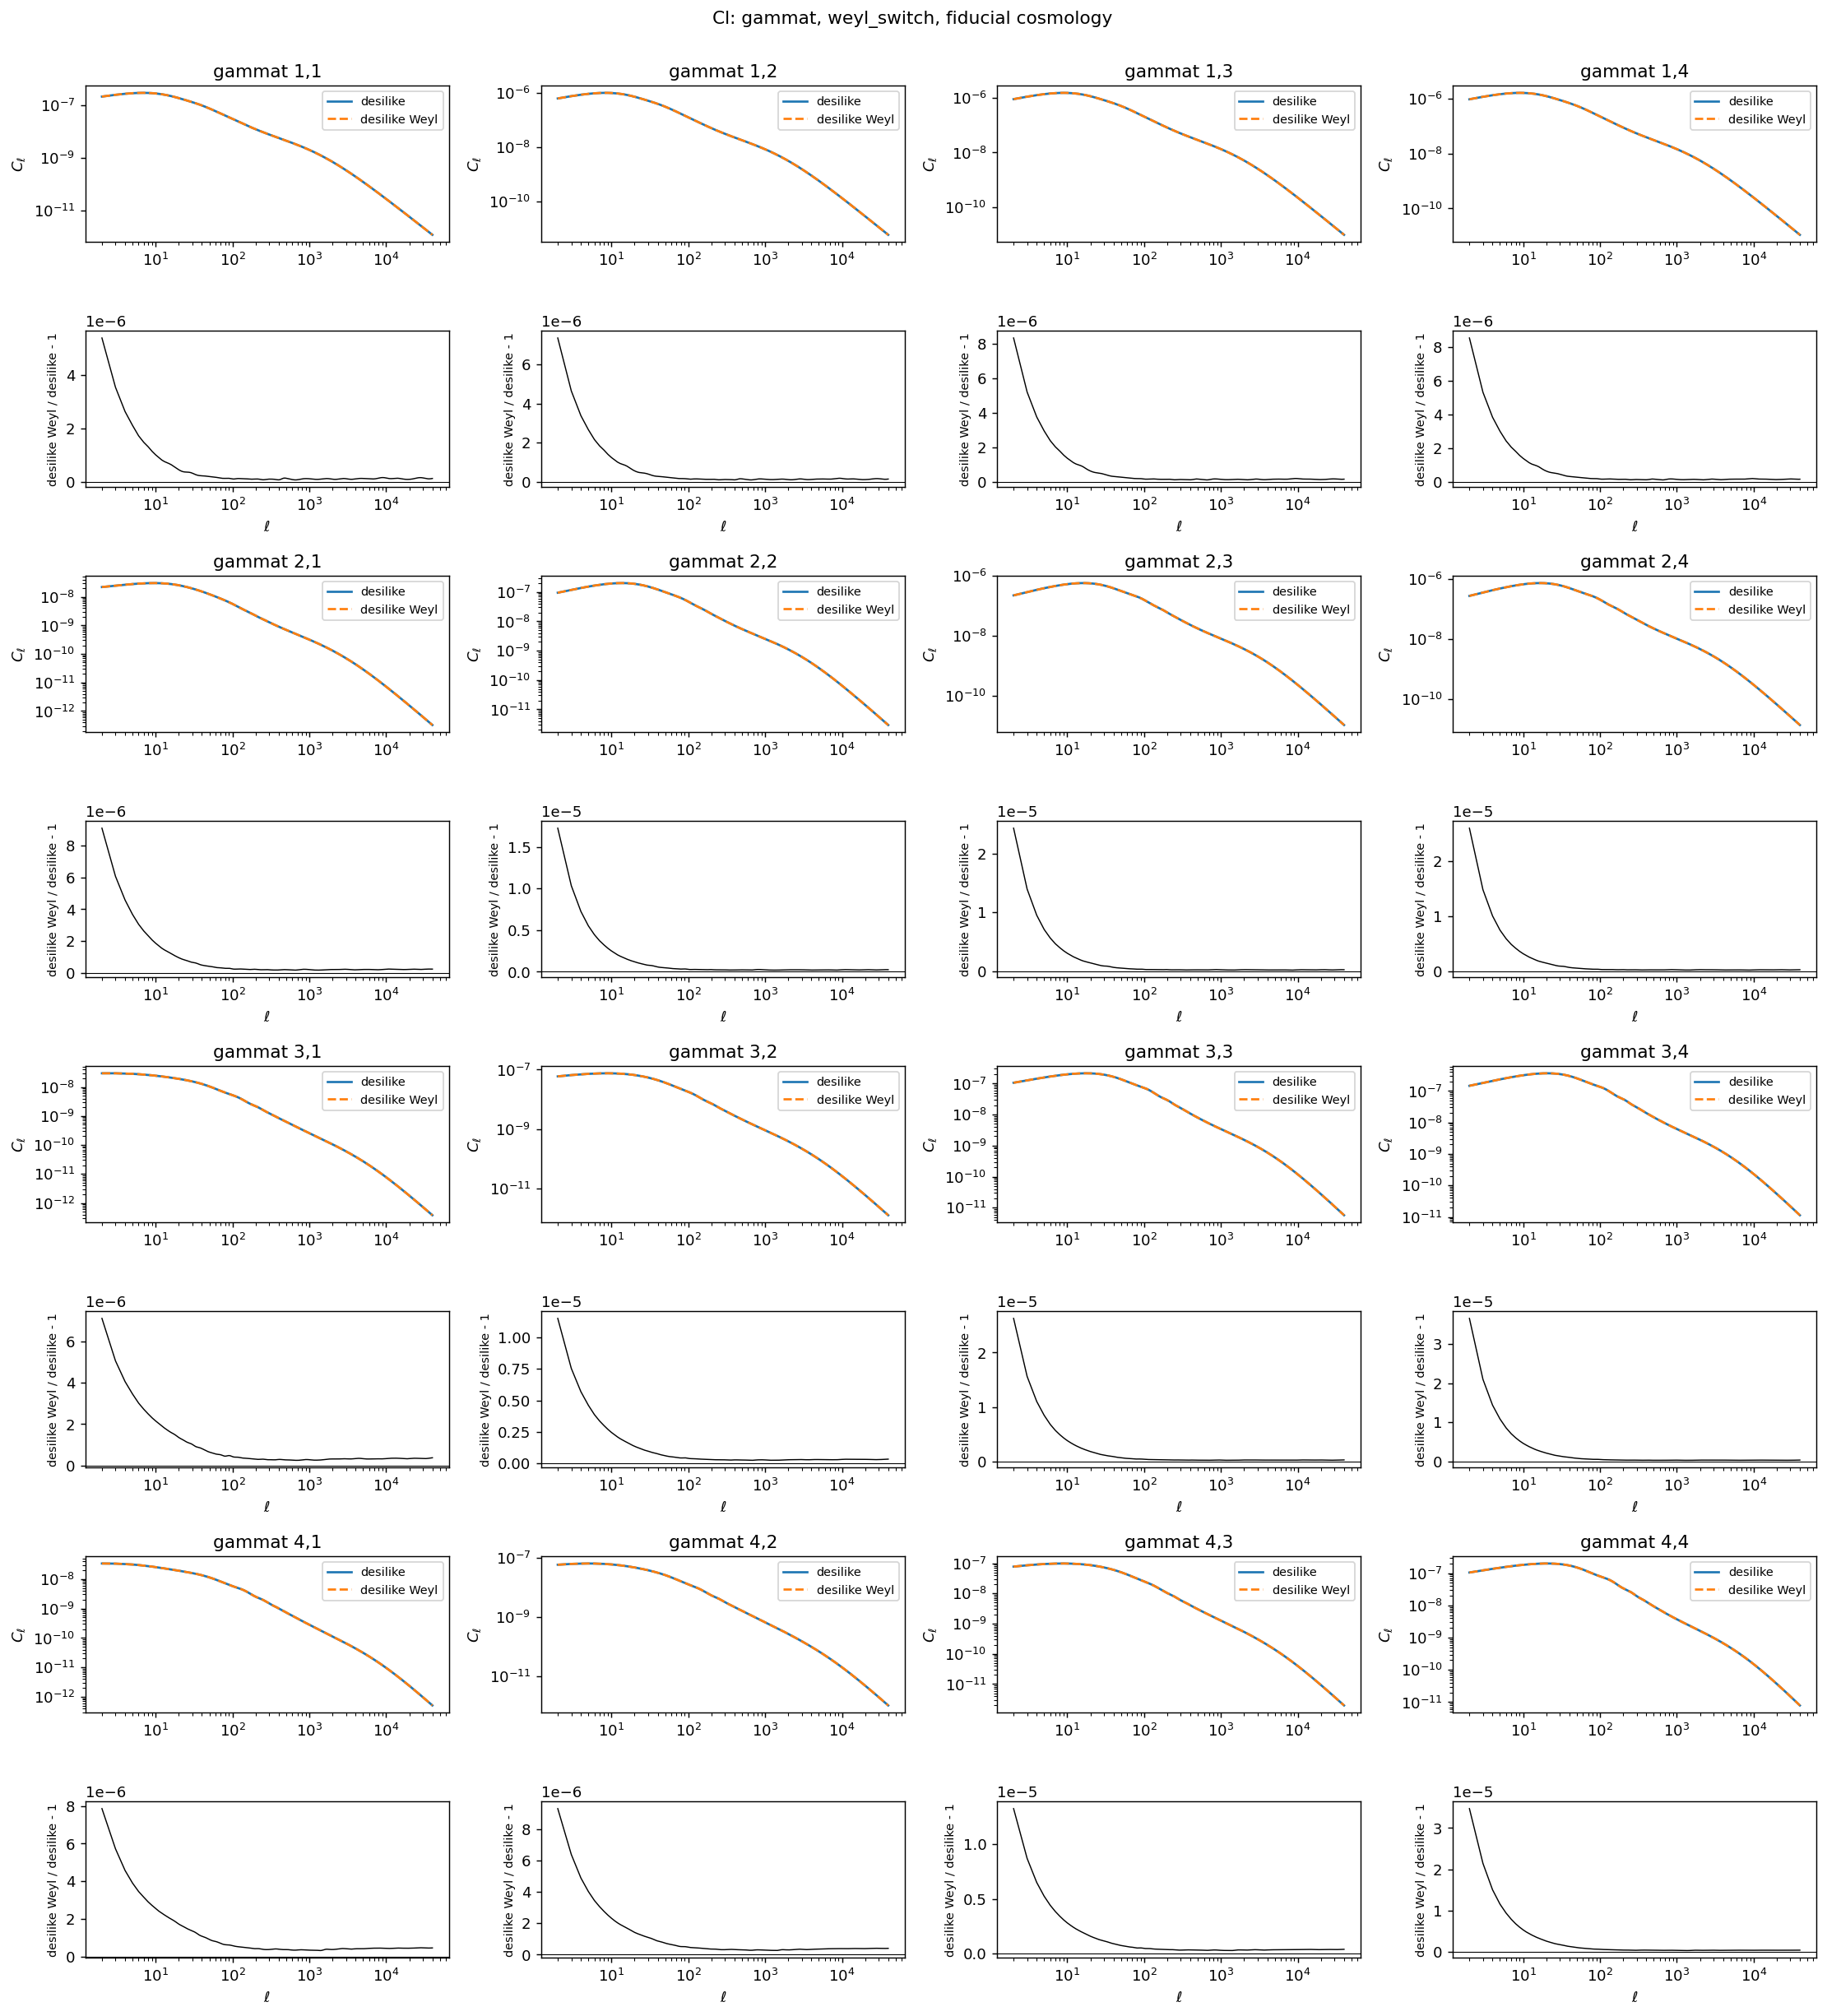

In [42]:
x = np.asarray(fiducial["predictions"]["density"]["ell"])
first = fiducial["predictions"]["weyl"]["cl_gammat"]
second = fiducial["predictions"]["density"]["cl_gammat"]
pairs = PLOT_PAIRS["gammat"]
fig, axes = plt.subplots(8, 4, figsize=(17.2, 18.8), squeeze=False)
for ax in axes.flat:
    ax.set_visible(False)

for count, (i, j) in enumerate(pairs):
    row, col = (i, j)
    top, bottom = axes[2 * row, col], axes[2 * row + 1, col]
    top.set_visible(True)
    bottom.set_visible(True)
    a = np.asarray(first[i, j])
    b = np.asarray(second[i, j])
    mask = x >= 2
    top.plot(x[mask], b[mask], label="desilike")
    top.plot(x[mask], a[mask], "--", label="desilike Weyl")
    top.set_xscale("log")
    # Preserve negative values; use log-log axes when every value is positive.
    if np.any(a[mask] < 0) or np.any(b[mask] < 0):
        top.set_yscale("symlog", linthresh=max(np.max(np.abs(b)) * 1e-5, 1e-300))
    else:
        top.set_yscale("log")
    top.set_title(f"gammat {i+1},{j+1}")
    top.set_ylabel(r"$C_\ell$")
    top.legend(fontsize=8)

    valid = mask & (np.abs(b) > max(np.max(np.abs(b)) * 1e-12, 1e-300))
    delta = np.full_like(b, np.nan, dtype=float)
    np.divide(a - b, b, out=delta, where=valid)  # Do not plot ratios where the denominator crosses zero.
    axes[2 * row + 1, col].semilogx(x[valid], delta[valid], color="black", lw=0.8)
    bottom.axhline(0, color="black", lw=0.6)
    bottom.set_xlabel(r"$\ell$")
    bottom.set_ylabel("desilike Weyl / desilike - 1", fontsize=8)
    bottom.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

fig.suptitle("Cl: gammat, weyl_switch, fiducial cosmology", y=1.002)
fig.tight_layout()
fig.savefig(OUT / "Cl_weyl_switch_gammat.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)


### xip — Cl — desilike: Weyl on/off

/var/folders/f6/3xg83pv93rd82_jd1m8pv17r0000gn/T/ipykernel_16263/2843480049.py:41: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


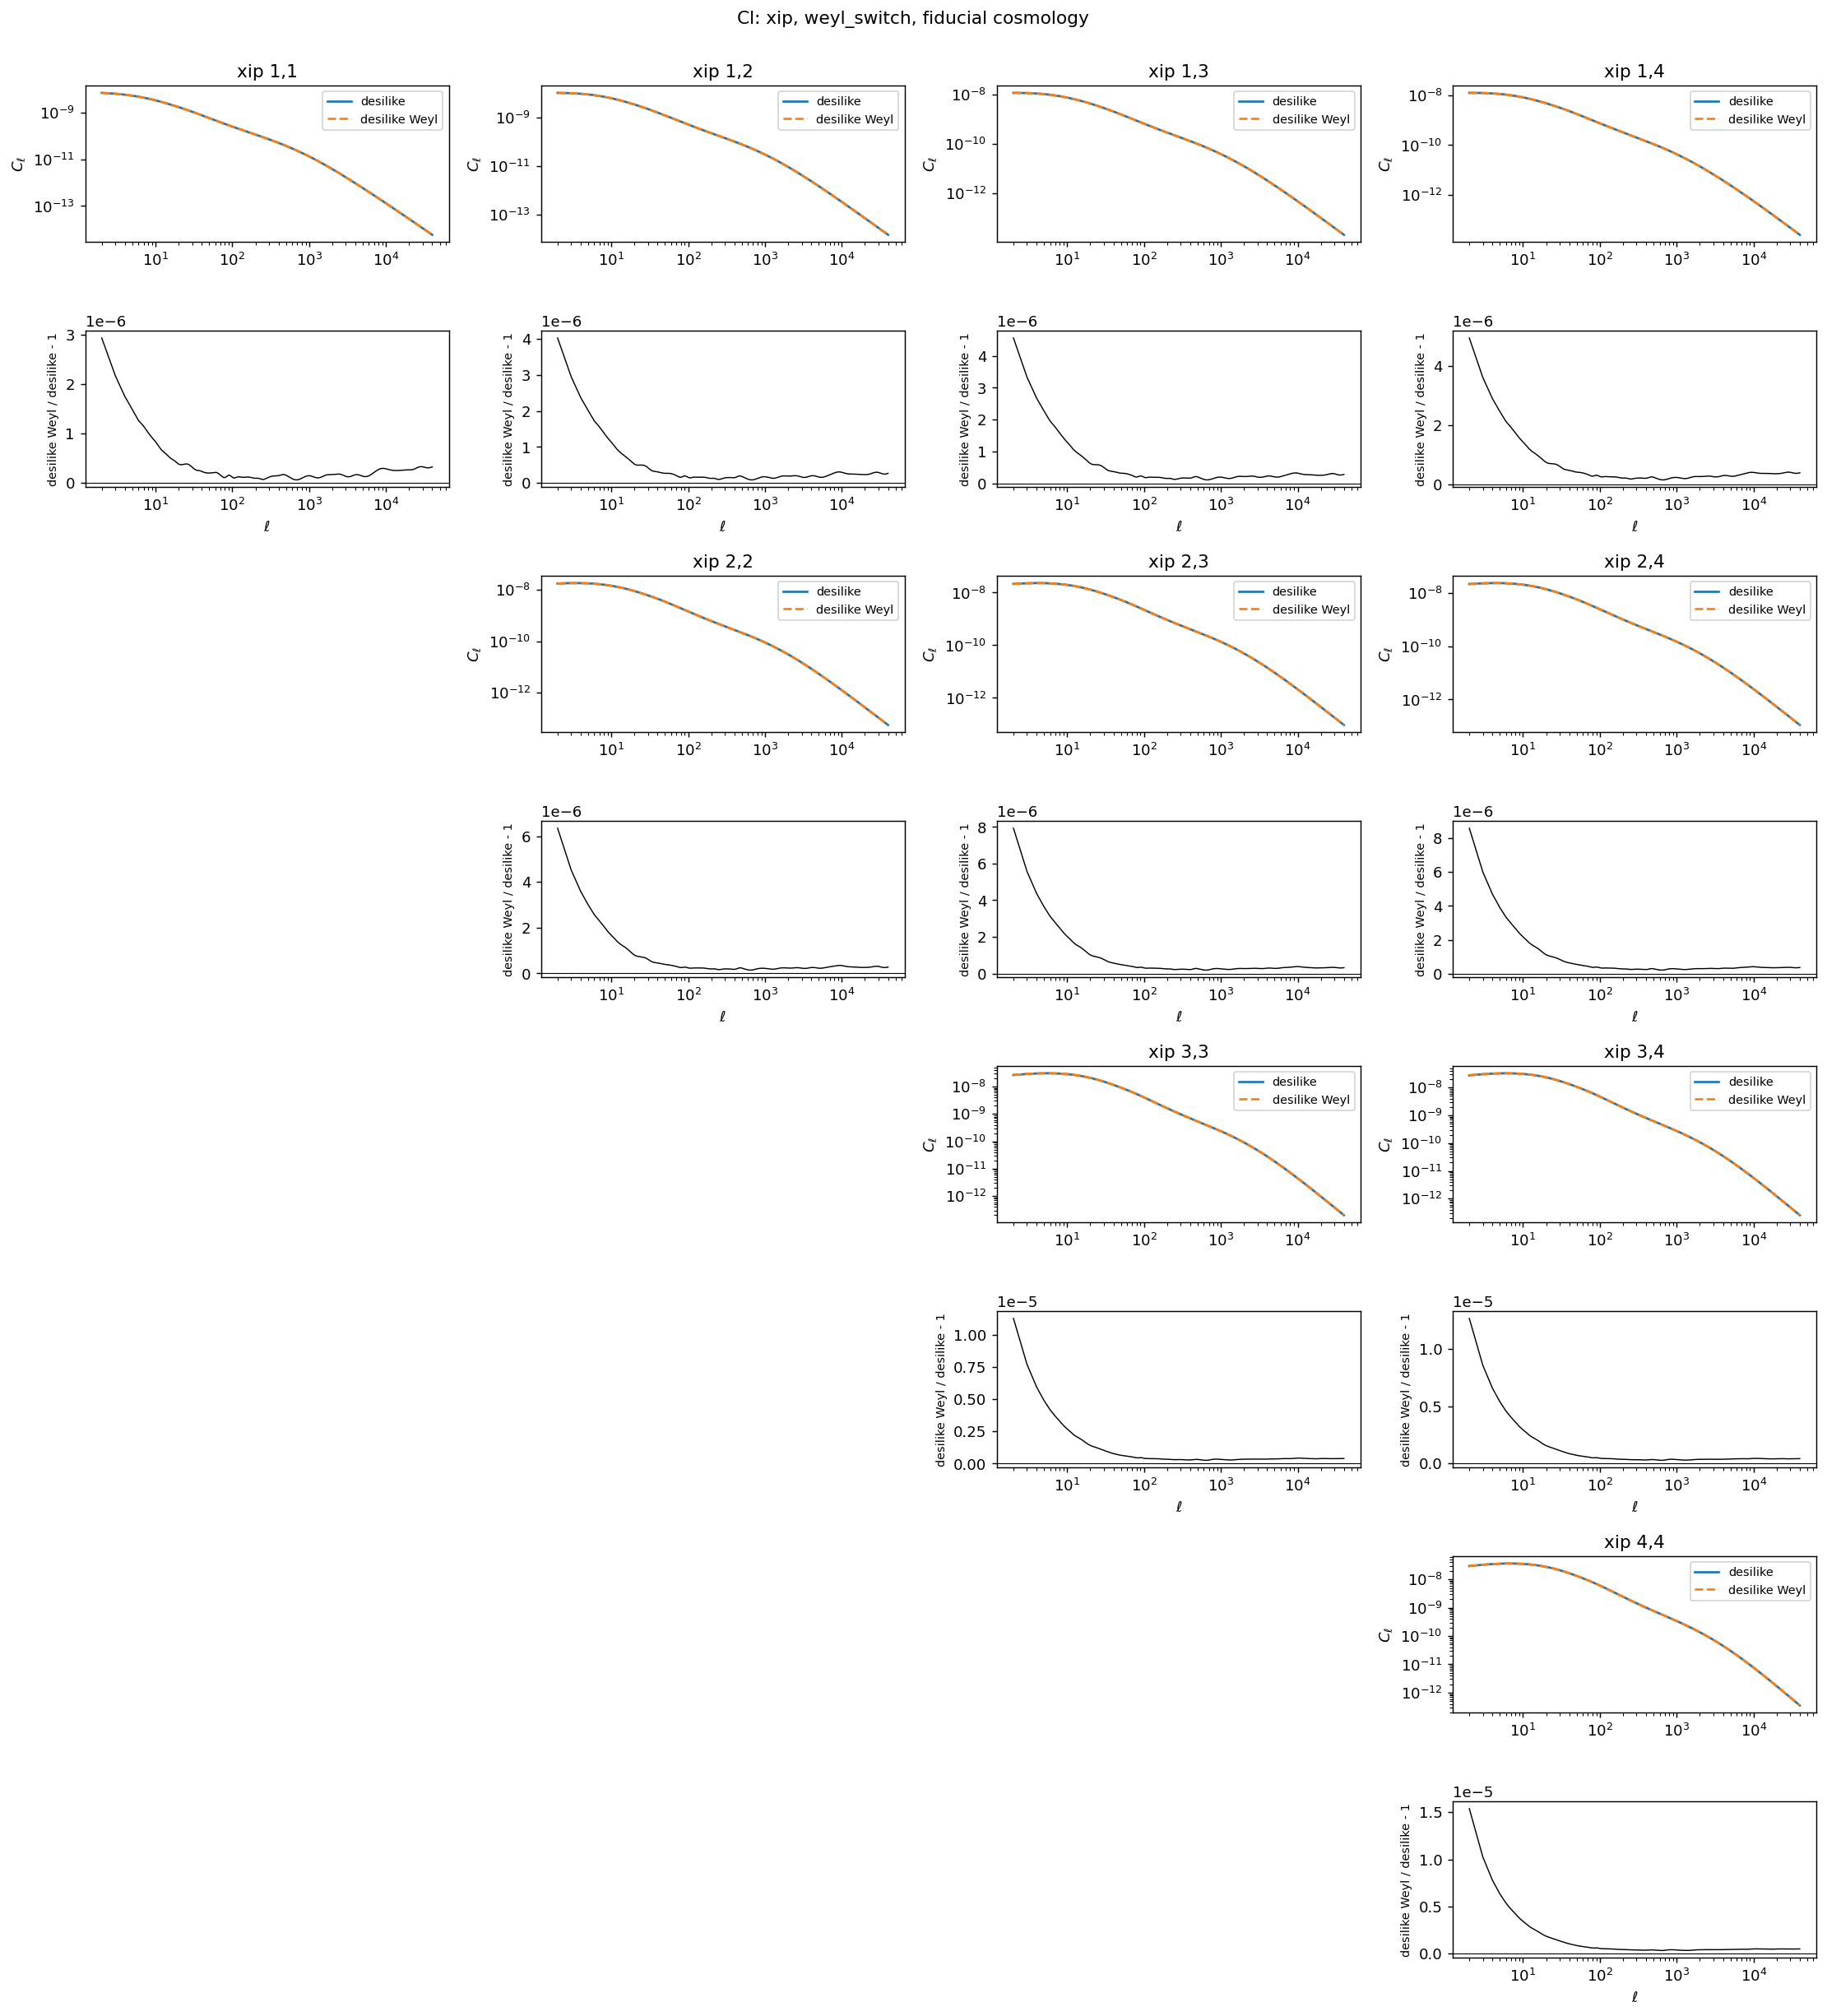

In [43]:
x = np.asarray(fiducial["predictions"]["density"]["ell"])
first = fiducial["predictions"]["weyl"]["cl_xip"]
second = fiducial["predictions"]["density"]["cl_xip"]
pairs = PLOT_PAIRS["xip"]
fig, axes = plt.subplots(8, 4, figsize=(17.2, 18.8), squeeze=False)
for ax in axes.flat:
    ax.set_visible(False)

for count, (i, j) in enumerate(pairs):
    row, col = (i, j)
    top, bottom = axes[2 * row, col], axes[2 * row + 1, col]
    top.set_visible(True)
    bottom.set_visible(True)
    a = np.asarray(first[i, j])
    b = np.asarray(second[i, j])
    mask = x >= 2
    top.plot(x[mask], b[mask], label="desilike")
    top.plot(x[mask], a[mask], "--", label="desilike Weyl")
    top.set_xscale("log")
    # Preserve negative values; use log-log axes when every value is positive.
    if np.any(a[mask] < 0) or np.any(b[mask] < 0):
        top.set_yscale("symlog", linthresh=max(np.max(np.abs(b)) * 1e-5, 1e-300))
    else:
        top.set_yscale("log")
    top.set_title(f"xip {i+1},{j+1}")
    top.set_ylabel(r"$C_\ell$")
    top.legend(fontsize=8)

    valid = mask & (np.abs(b) > max(np.max(np.abs(b)) * 1e-12, 1e-300))
    delta = np.full_like(b, np.nan, dtype=float)
    np.divide(a - b, b, out=delta, where=valid)  # Do not plot ratios where the denominator crosses zero.
    axes[2 * row + 1, col].semilogx(x[valid], delta[valid], color="black", lw=0.8)
    bottom.axhline(0, color="black", lw=0.6)
    bottom.set_xlabel(r"$\ell$")
    bottom.set_ylabel("desilike Weyl / desilike - 1", fontsize=8)
    bottom.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

fig.suptitle("Cl: xip, weyl_switch, fiducial cosmology", y=1.002)
fig.tight_layout()
fig.savefig(OUT / "Cl_weyl_switch_xip.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)


### xim — Cl — desilike: Weyl on/off

/var/folders/f6/3xg83pv93rd82_jd1m8pv17r0000gn/T/ipykernel_16263/1493289710.py:41: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


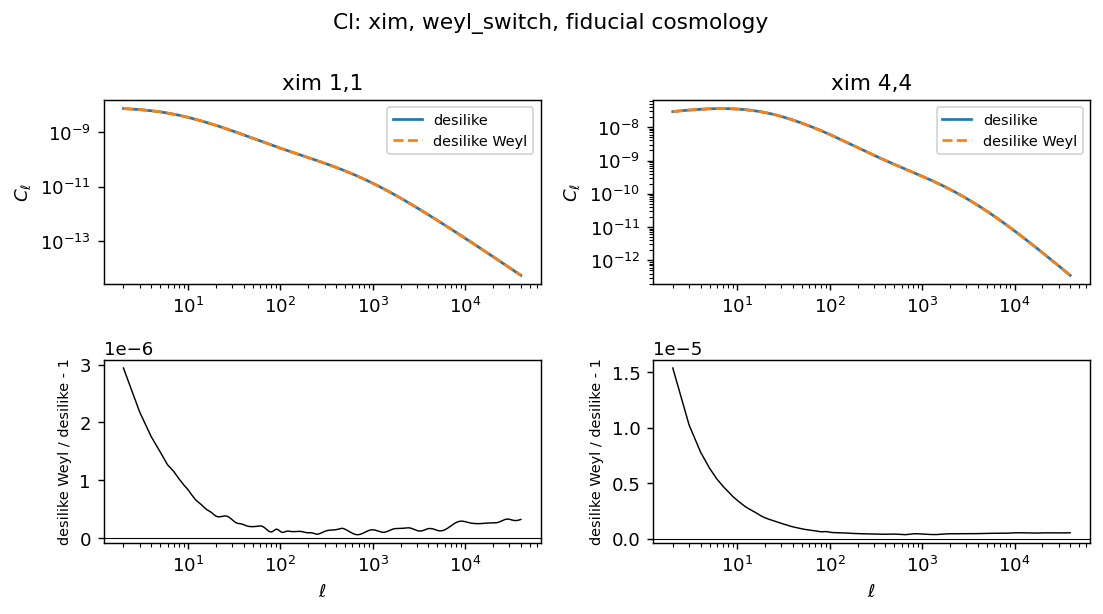

In [44]:
x = np.asarray(fiducial["predictions"]["density"]["ell"])
first = fiducial["predictions"]["weyl"]["cl_xim"]
second = fiducial["predictions"]["density"]["cl_xim"]
pairs = PLOT_PAIRS["xim"]
fig, axes = plt.subplots(2, 2, figsize=(8.6, 4.7), squeeze=False)
for ax in axes.flat:
    ax.set_visible(False)

for count, (i, j) in enumerate(pairs):
    row, col = (0, count)
    top, bottom = axes[2 * row, col], axes[2 * row + 1, col]
    top.set_visible(True)
    bottom.set_visible(True)
    a = np.asarray(first[i, j])
    b = np.asarray(second[i, j])
    mask = x >= 2
    top.plot(x[mask], b[mask], label="desilike")
    top.plot(x[mask], a[mask], "--", label="desilike Weyl")
    top.set_xscale("log")
    # Preserve negative values; use log-log axes when every value is positive.
    if np.any(a[mask] < 0) or np.any(b[mask] < 0):
        top.set_yscale("symlog", linthresh=max(np.max(np.abs(b)) * 1e-5, 1e-300))
    else:
        top.set_yscale("log")
    top.set_title(f"xim {i+1},{j+1}")
    top.set_ylabel(r"$C_\ell$")
    top.legend(fontsize=8)

    valid = mask & (np.abs(b) > max(np.max(np.abs(b)) * 1e-12, 1e-300))
    delta = np.full_like(b, np.nan, dtype=float)
    np.divide(a - b, b, out=delta, where=valid)  # Do not plot ratios where the denominator crosses zero.
    axes[2 * row + 1, col].semilogx(x[valid], delta[valid], color="black", lw=0.8)
    bottom.axhline(0, color="black", lw=0.6)
    bottom.set_xlabel(r"$\ell$")
    bottom.set_ylabel("desilike Weyl / desilike - 1", fontsize=8)
    bottom.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

fig.suptitle("Cl: xim, weyl_switch, fiducial cosmology", y=1.002)
fig.tight_layout()
fig.savefig(OUT / "Cl_weyl_switch_xim.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)


### wtheta — xi — desilike: Weyl on/off

/var/folders/f6/3xg83pv93rd82_jd1m8pv17r0000gn/T/ipykernel_16263/4042072219.py:41: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


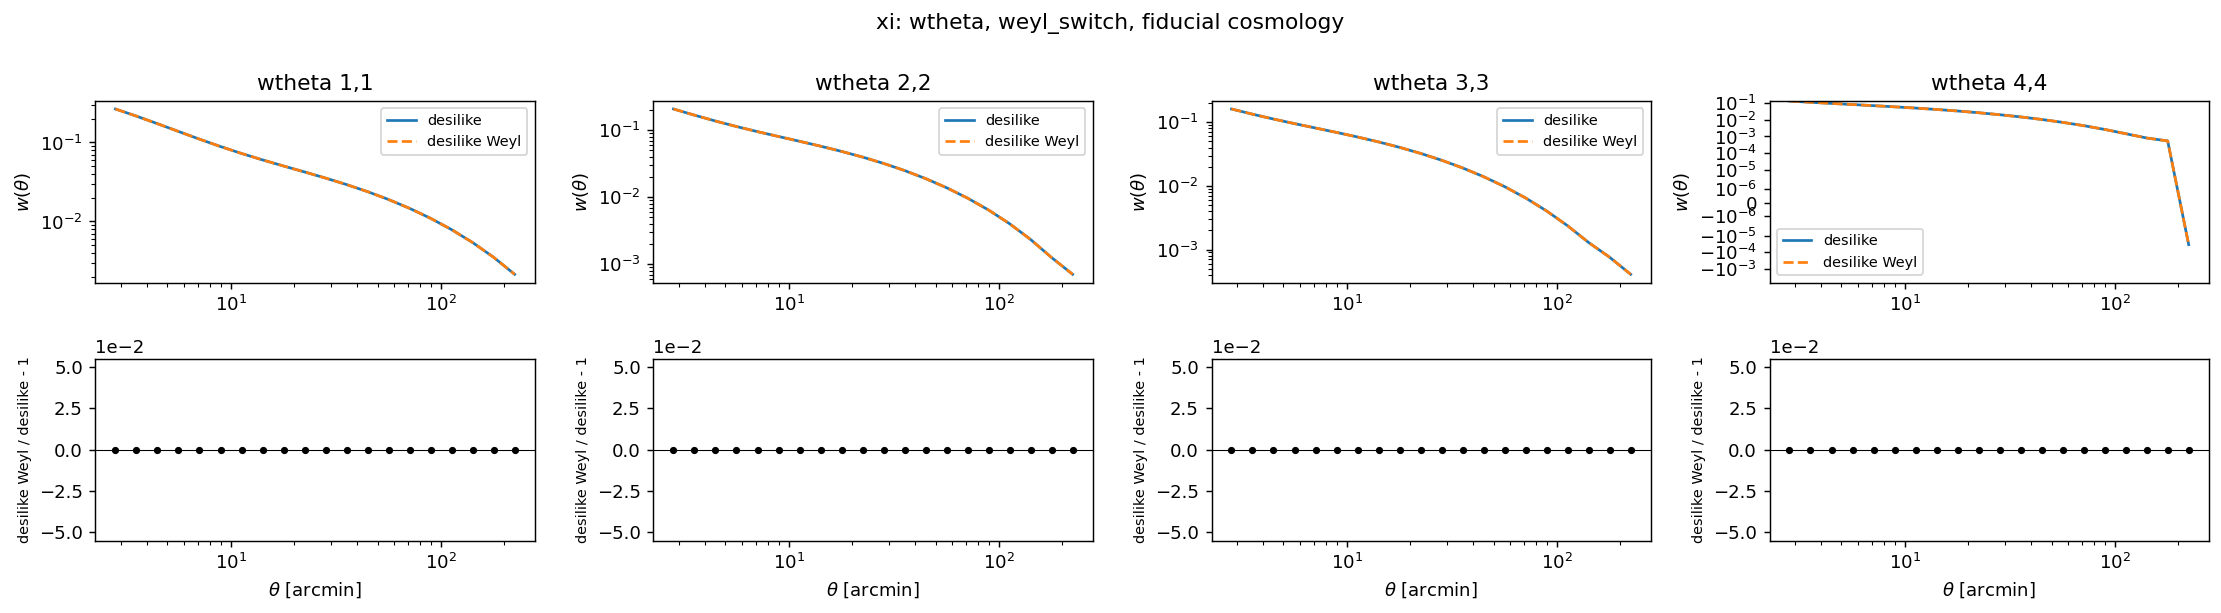

In [45]:
x = np.asarray(theta_bins)
first = fiducial["predictions"]["weyl"]["wtheta"]
second = fiducial["predictions"]["density"]["wtheta"]
pairs = PLOT_PAIRS["wtheta"]
fig, axes = plt.subplots(2, 4, figsize=(17.2, 4.7), squeeze=False)
for ax in axes.flat:
    ax.set_visible(False)

for count, (i, j) in enumerate(pairs):
    row, col = (0, count)
    top, bottom = axes[2 * row, col], axes[2 * row + 1, col]
    top.set_visible(True)
    bottom.set_visible(True)
    a = np.asarray(first[i, j])
    b = np.asarray(second[i, j])
    mask = np.ones(x.size, dtype=bool)
    top.plot(x[mask], b[mask], label="desilike")
    top.plot(x[mask], a[mask], "--", label="desilike Weyl")
    top.set_xscale("log")
    # Preserve negative values; use log-log axes when every value is positive.
    if np.any(a[mask] < 0) or np.any(b[mask] < 0):
        top.set_yscale("symlog", linthresh=max(np.max(np.abs(b)) * 1e-5, 1e-300))
    else:
        top.set_yscale("log")
    top.set_title(f"wtheta {i+1},{j+1}")
    top.set_ylabel(r"$w(\theta)$")
    top.legend(fontsize=8)

    valid = mask & (np.abs(b) > max(np.max(np.abs(b)) * 1e-12, 1e-300))
    delta = np.full_like(b, np.nan, dtype=float)
    np.divide(a - b, b, out=delta, where=valid)  # Do not plot ratios where the denominator crosses zero.
    axes[2 * row + 1, col].semilogx(x[valid], delta[valid], "ko", ms=3)
    bottom.axhline(0, color="black", lw=0.6)
    bottom.set_xlabel(r"$\theta$ [arcmin]")
    bottom.set_ylabel("desilike Weyl / desilike - 1", fontsize=8)
    bottom.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

fig.suptitle("xi: wtheta, weyl_switch, fiducial cosmology", y=1.002)
fig.tight_layout()
fig.savefig(OUT / "xi_weyl_switch_wtheta.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)


### gammat — xi — desilike: Weyl on/off

/var/folders/f6/3xg83pv93rd82_jd1m8pv17r0000gn/T/ipykernel_16263/438255239.py:41: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


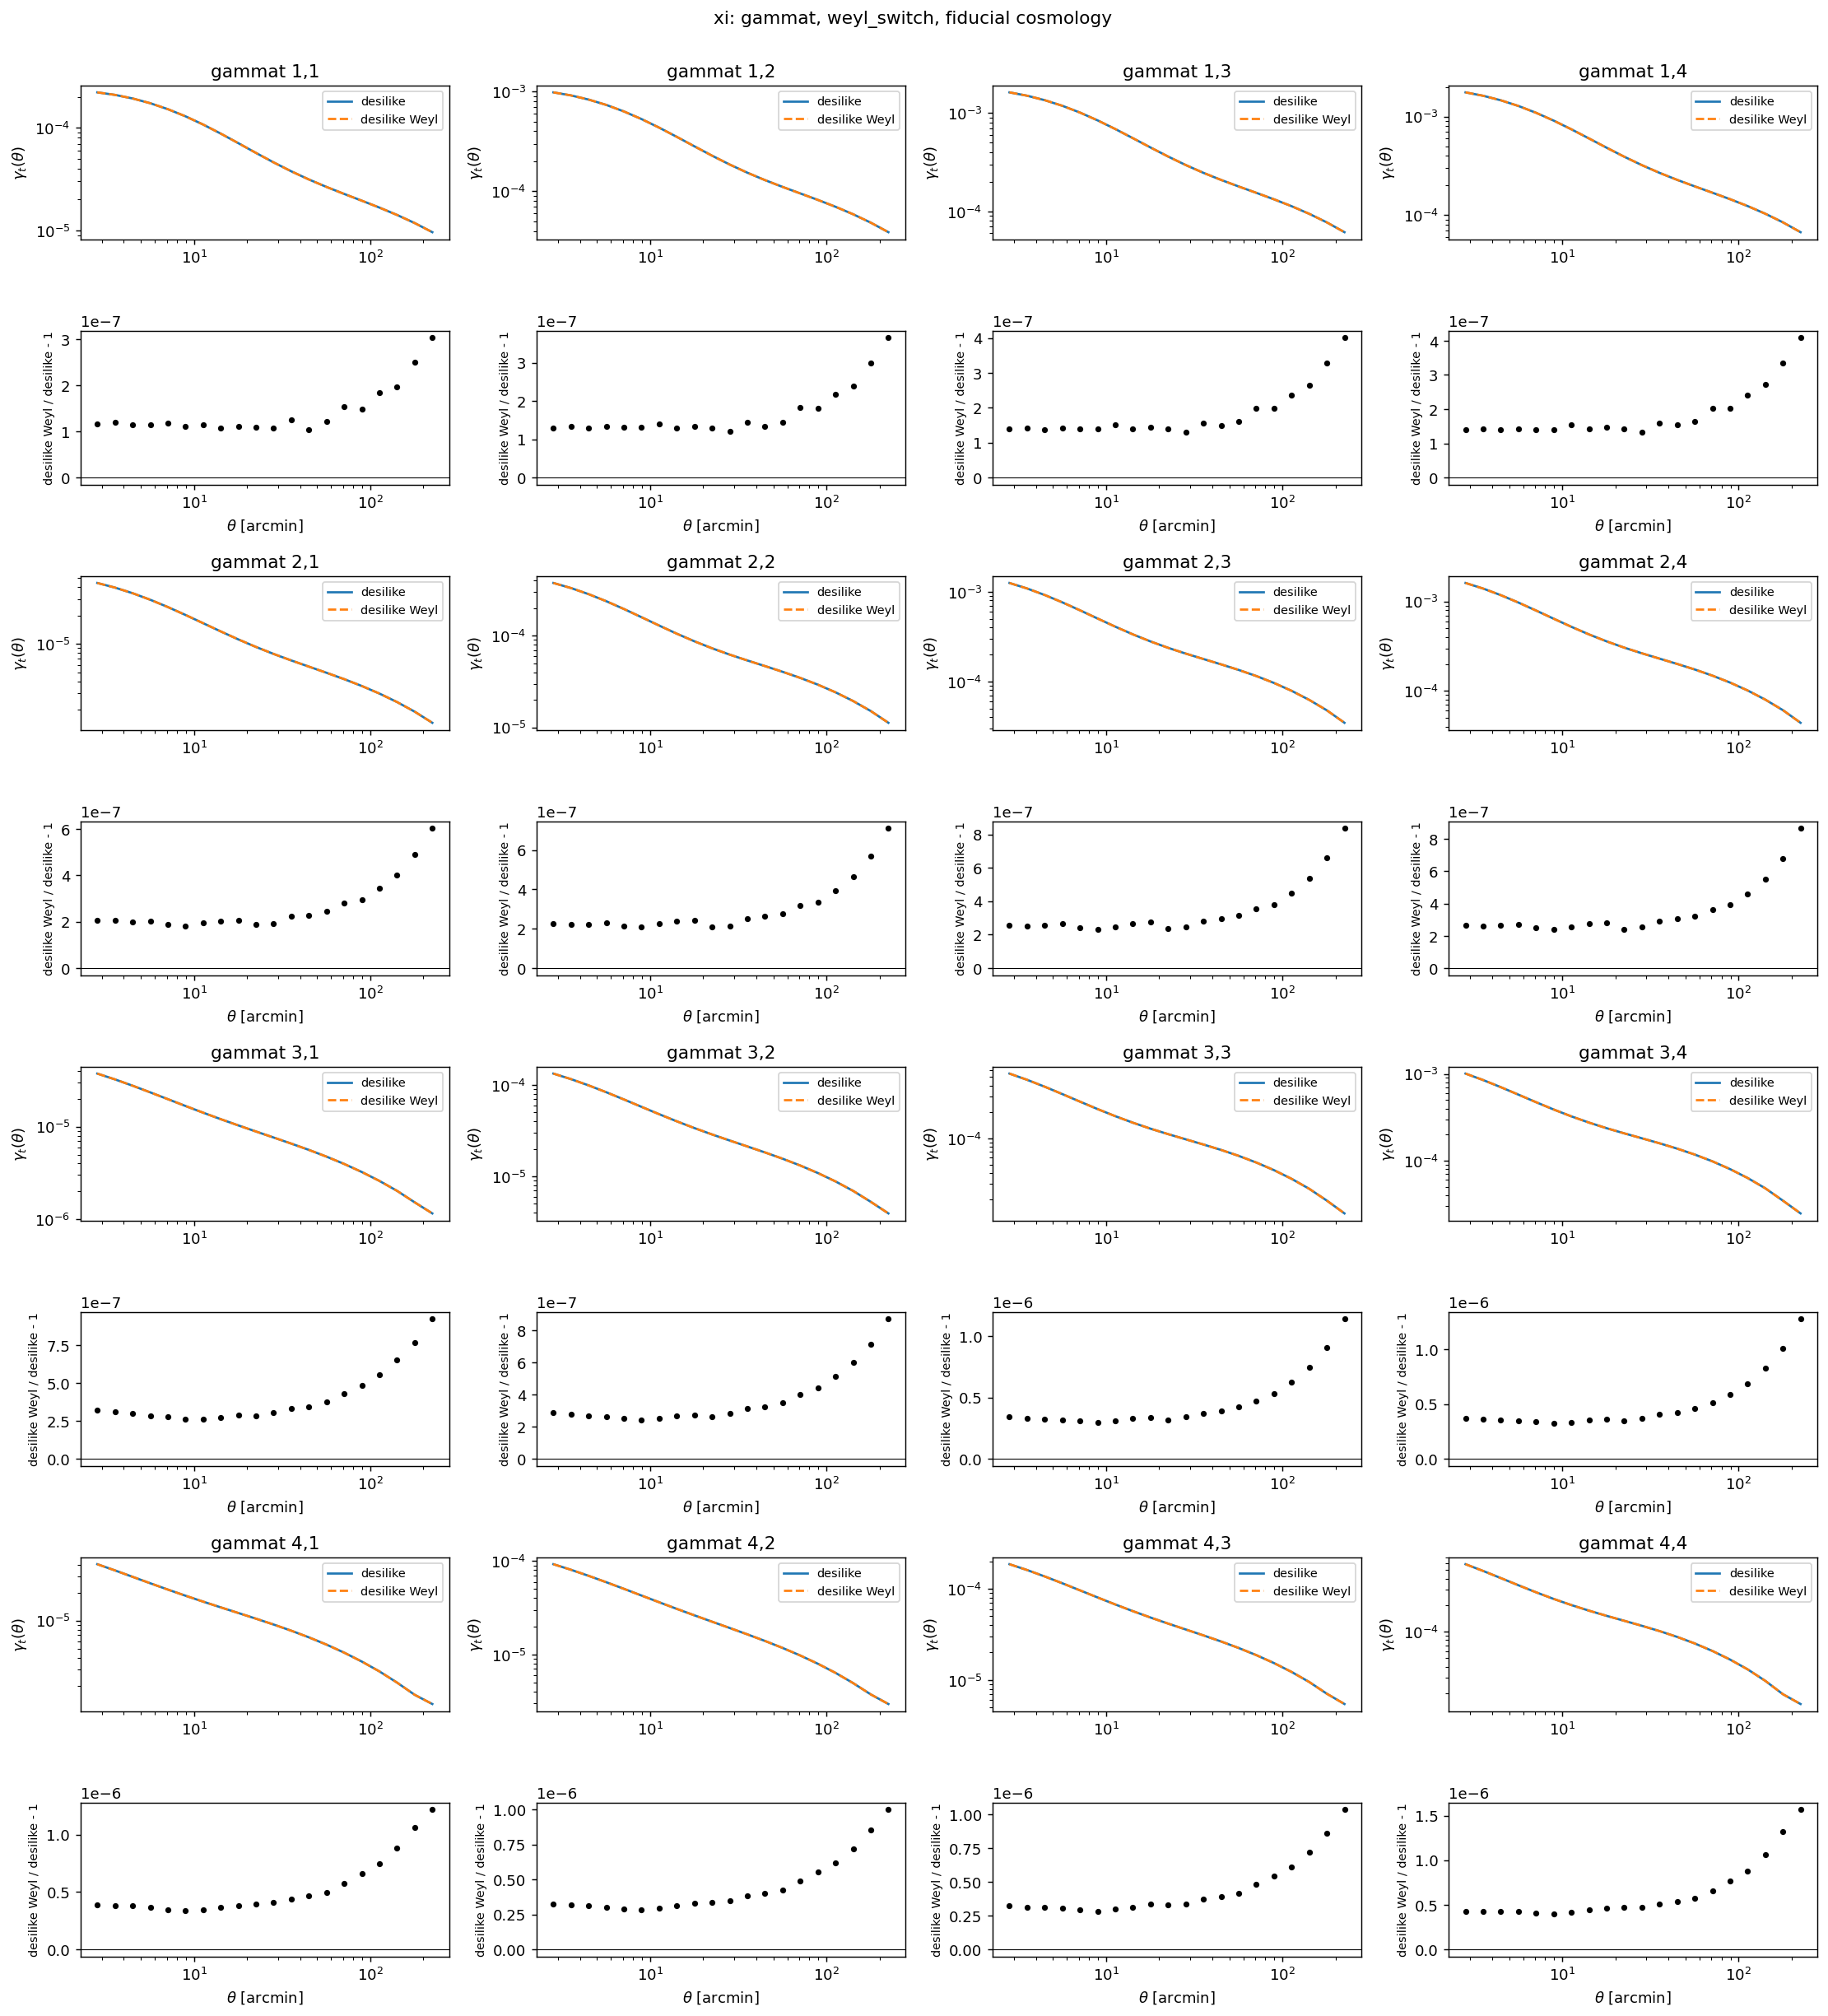

In [46]:
x = np.asarray(theta_bins)
first = fiducial["predictions"]["weyl"]["gammat"]
second = fiducial["predictions"]["density"]["gammat"]
pairs = PLOT_PAIRS["gammat"]
fig, axes = plt.subplots(8, 4, figsize=(17.2, 18.8), squeeze=False)
for ax in axes.flat:
    ax.set_visible(False)

for count, (i, j) in enumerate(pairs):
    row, col = (i, j)
    top, bottom = axes[2 * row, col], axes[2 * row + 1, col]
    top.set_visible(True)
    bottom.set_visible(True)
    a = np.asarray(first[i, j])
    b = np.asarray(second[i, j])
    mask = np.ones(x.size, dtype=bool)
    top.plot(x[mask], b[mask], label="desilike")
    top.plot(x[mask], a[mask], "--", label="desilike Weyl")
    top.set_xscale("log")
    # Preserve negative values; use log-log axes when every value is positive.
    if np.any(a[mask] < 0) or np.any(b[mask] < 0):
        top.set_yscale("symlog", linthresh=max(np.max(np.abs(b)) * 1e-5, 1e-300))
    else:
        top.set_yscale("log")
    top.set_title(f"gammat {i+1},{j+1}")
    top.set_ylabel(r"$\gamma_t(\theta)$")
    top.legend(fontsize=8)

    valid = mask & (np.abs(b) > max(np.max(np.abs(b)) * 1e-12, 1e-300))
    delta = np.full_like(b, np.nan, dtype=float)
    np.divide(a - b, b, out=delta, where=valid)  # Do not plot ratios where the denominator crosses zero.
    axes[2 * row + 1, col].semilogx(x[valid], delta[valid], "ko", ms=3)
    bottom.axhline(0, color="black", lw=0.6)
    bottom.set_xlabel(r"$\theta$ [arcmin]")
    bottom.set_ylabel("desilike Weyl / desilike - 1", fontsize=8)
    bottom.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

fig.suptitle("xi: gammat, weyl_switch, fiducial cosmology", y=1.002)
fig.tight_layout()
fig.savefig(OUT / "xi_weyl_switch_gammat.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)


### xip — xi — desilike: Weyl on/off

/var/folders/f6/3xg83pv93rd82_jd1m8pv17r0000gn/T/ipykernel_16263/3237010000.py:41: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


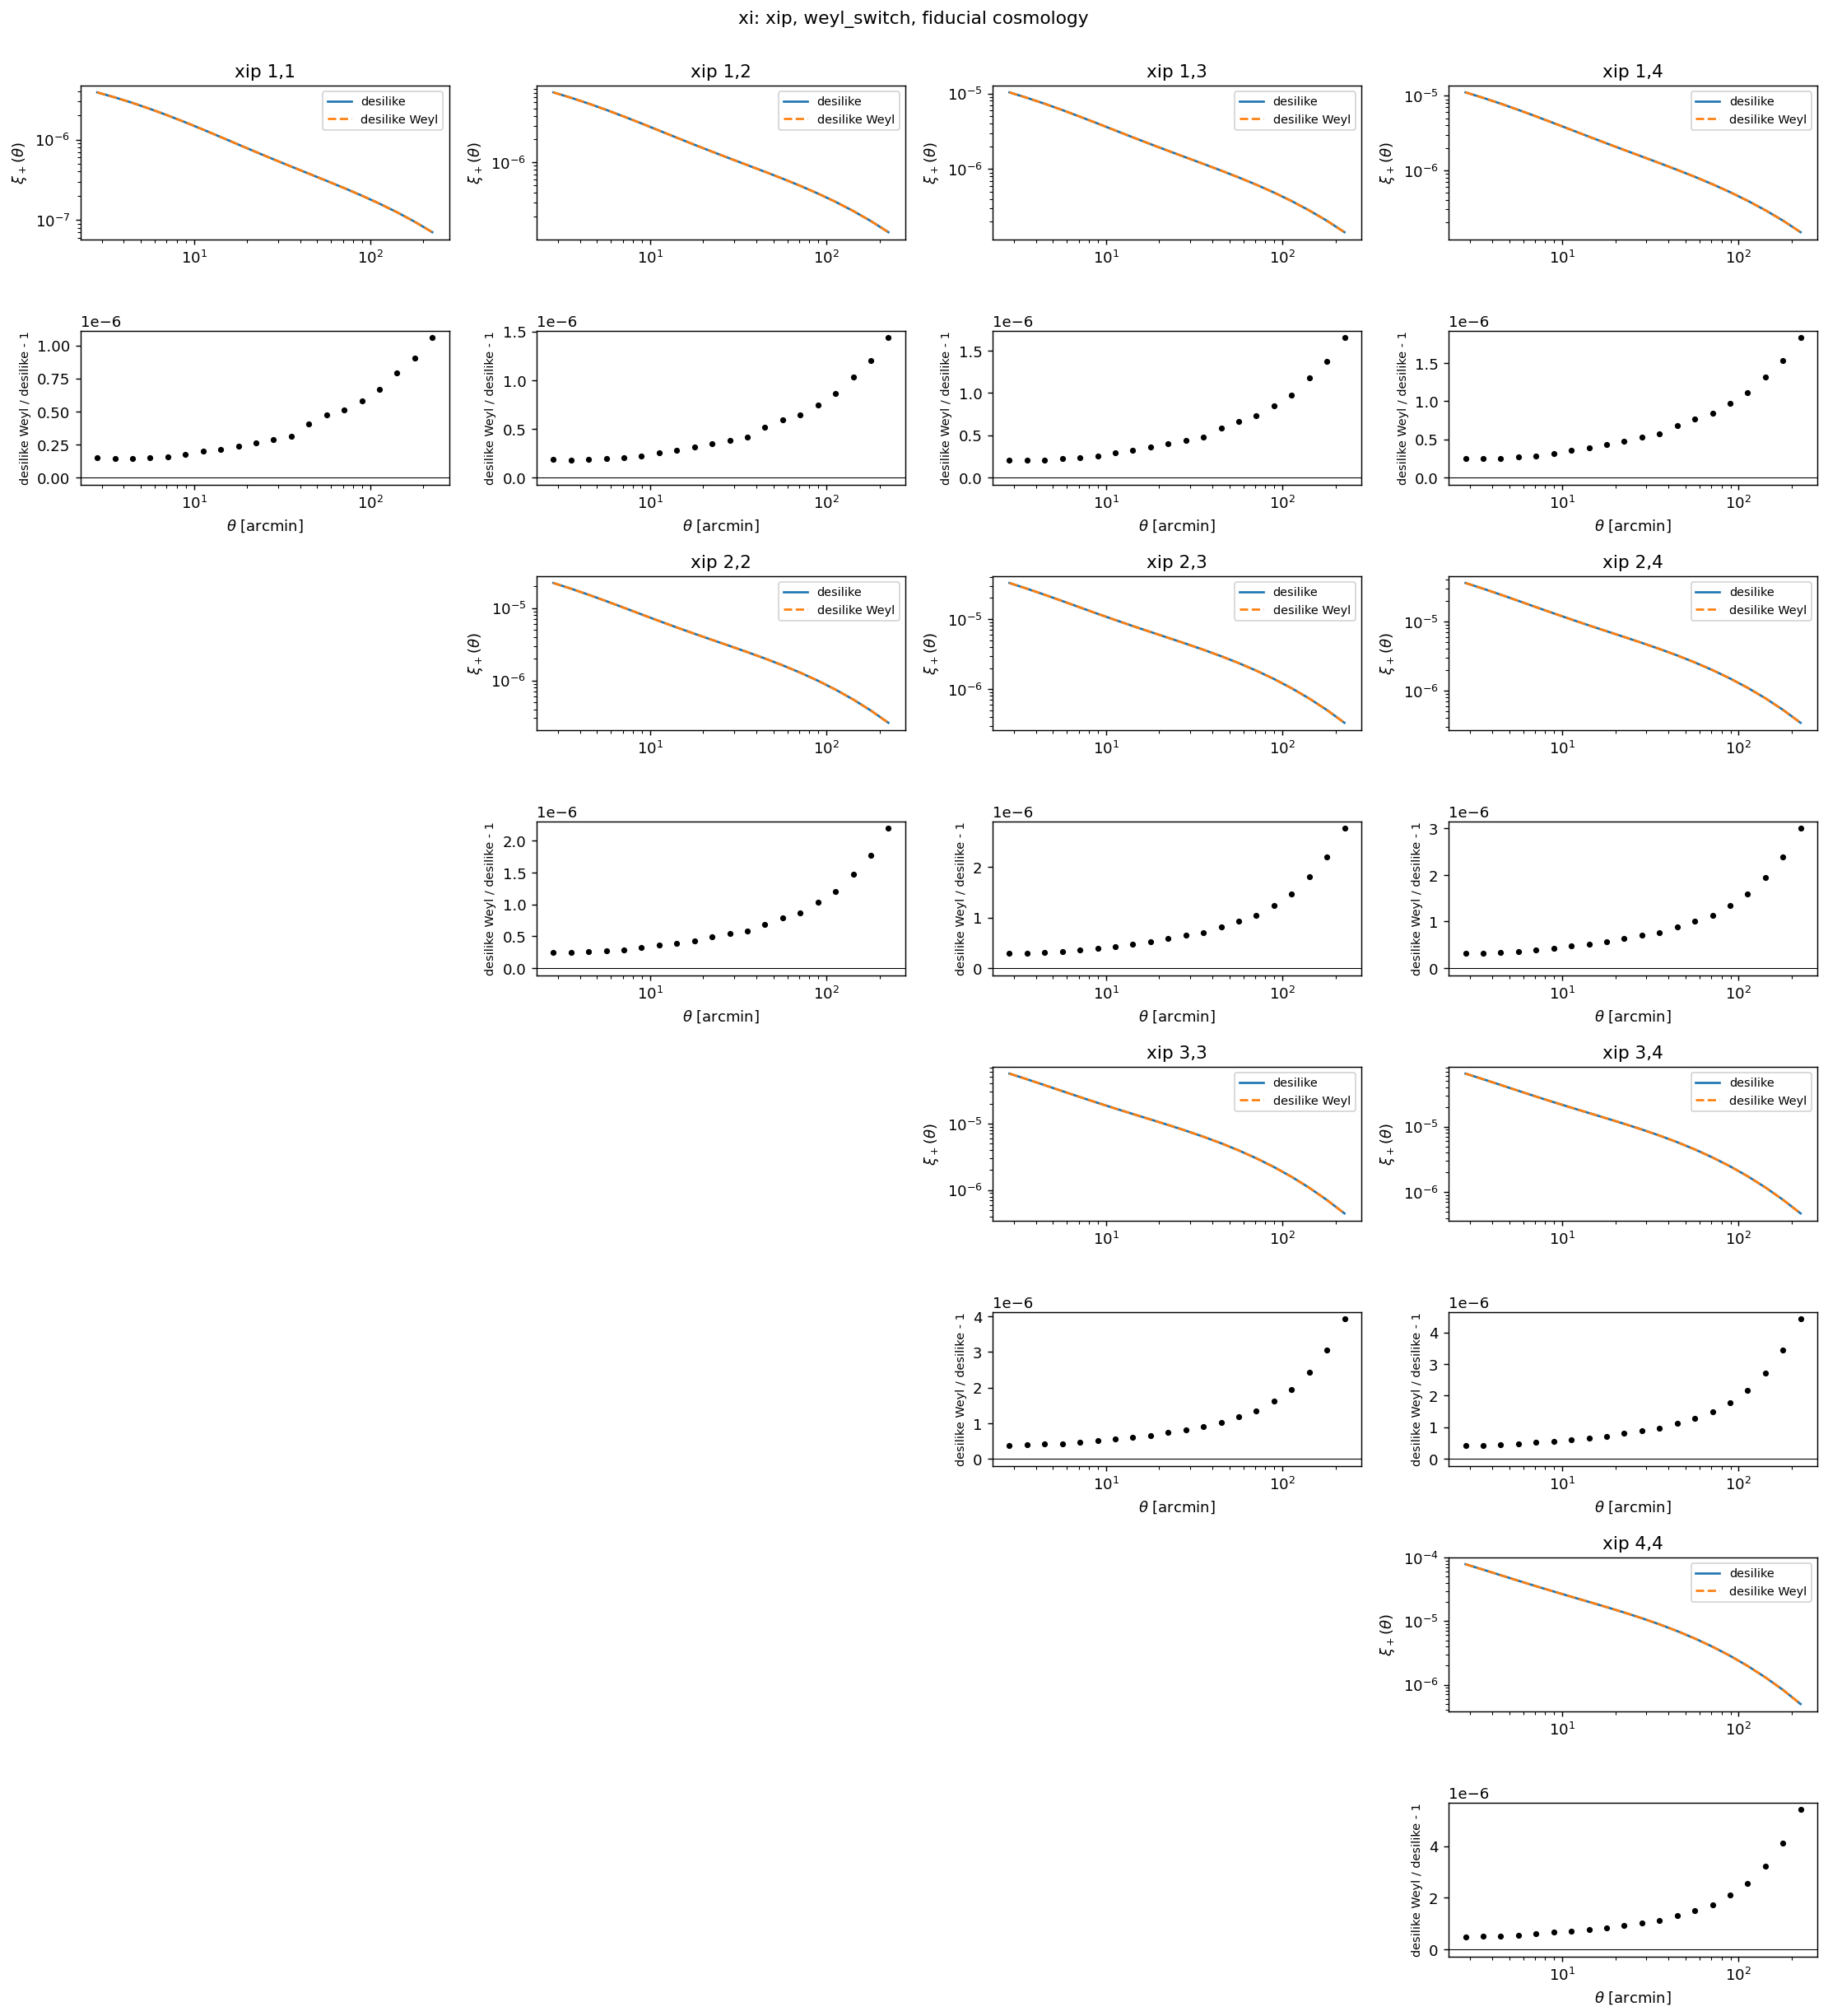

In [47]:
x = np.asarray(theta_bins)
first = fiducial["predictions"]["weyl"]["xip"]
second = fiducial["predictions"]["density"]["xip"]
pairs = PLOT_PAIRS["xip"]
fig, axes = plt.subplots(8, 4, figsize=(17.2, 18.8), squeeze=False)
for ax in axes.flat:
    ax.set_visible(False)

for count, (i, j) in enumerate(pairs):
    row, col = (i, j)
    top, bottom = axes[2 * row, col], axes[2 * row + 1, col]
    top.set_visible(True)
    bottom.set_visible(True)
    a = np.asarray(first[i, j])
    b = np.asarray(second[i, j])
    mask = np.ones(x.size, dtype=bool)
    top.plot(x[mask], b[mask], label="desilike")
    top.plot(x[mask], a[mask], "--", label="desilike Weyl")
    top.set_xscale("log")
    # Preserve negative values; use log-log axes when every value is positive.
    if np.any(a[mask] < 0) or np.any(b[mask] < 0):
        top.set_yscale("symlog", linthresh=max(np.max(np.abs(b)) * 1e-5, 1e-300))
    else:
        top.set_yscale("log")
    top.set_title(f"xip {i+1},{j+1}")
    top.set_ylabel(r"$\xi_+(\theta)$")
    top.legend(fontsize=8)

    valid = mask & (np.abs(b) > max(np.max(np.abs(b)) * 1e-12, 1e-300))
    delta = np.full_like(b, np.nan, dtype=float)
    np.divide(a - b, b, out=delta, where=valid)  # Do not plot ratios where the denominator crosses zero.
    axes[2 * row + 1, col].semilogx(x[valid], delta[valid], "ko", ms=3)
    bottom.axhline(0, color="black", lw=0.6)
    bottom.set_xlabel(r"$\theta$ [arcmin]")
    bottom.set_ylabel("desilike Weyl / desilike - 1", fontsize=8)
    bottom.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

fig.suptitle("xi: xip, weyl_switch, fiducial cosmology", y=1.002)
fig.tight_layout()
fig.savefig(OUT / "xi_weyl_switch_xip.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)


### xim — xi — desilike: Weyl on/off

/var/folders/f6/3xg83pv93rd82_jd1m8pv17r0000gn/T/ipykernel_16263/240152616.py:41: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


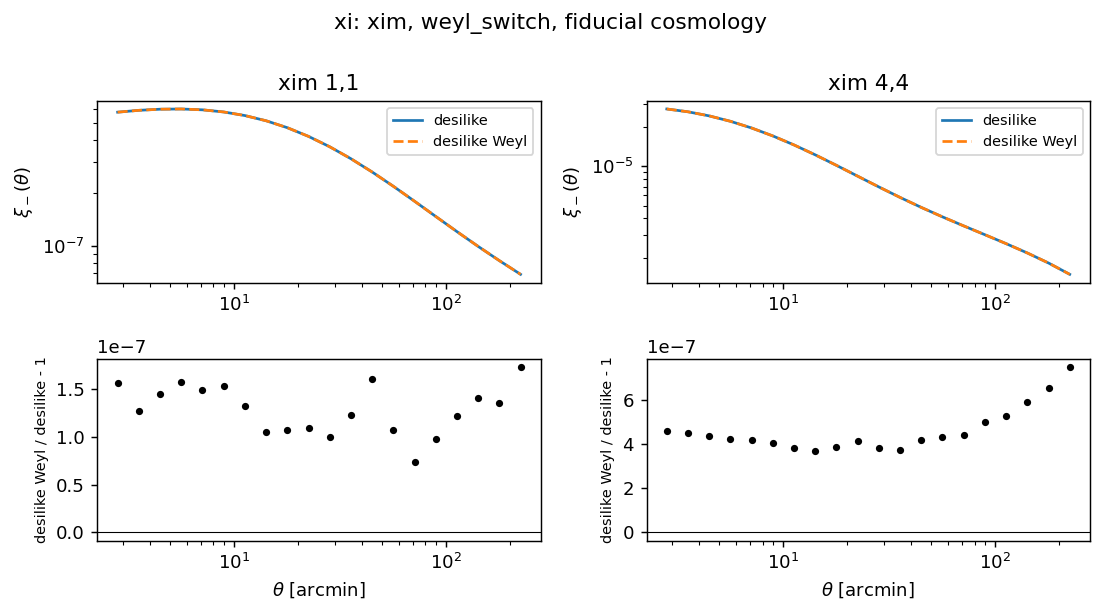

In [48]:
x = np.asarray(theta_bins)
first = fiducial["predictions"]["weyl"]["xim"]
second = fiducial["predictions"]["density"]["xim"]
pairs = PLOT_PAIRS["xim"]
fig, axes = plt.subplots(2, 2, figsize=(8.6, 4.7), squeeze=False)
for ax in axes.flat:
    ax.set_visible(False)

for count, (i, j) in enumerate(pairs):
    row, col = (0, count)
    top, bottom = axes[2 * row, col], axes[2 * row + 1, col]
    top.set_visible(True)
    bottom.set_visible(True)
    a = np.asarray(first[i, j])
    b = np.asarray(second[i, j])
    mask = np.ones(x.size, dtype=bool)
    top.plot(x[mask], b[mask], label="desilike")
    top.plot(x[mask], a[mask], "--", label="desilike Weyl")
    top.set_xscale("log")
    # Preserve negative values; use log-log axes when every value is positive.
    if np.any(a[mask] < 0) or np.any(b[mask] < 0):
        top.set_yscale("symlog", linthresh=max(np.max(np.abs(b)) * 1e-5, 1e-300))
    else:
        top.set_yscale("log")
    top.set_title(f"xim {i+1},{j+1}")
    top.set_ylabel(r"$\xi_-(\theta)$")
    top.legend(fontsize=8)

    valid = mask & (np.abs(b) > max(np.max(np.abs(b)) * 1e-12, 1e-300))
    delta = np.full_like(b, np.nan, dtype=float)
    np.divide(a - b, b, out=delta, where=valid)  # Do not plot ratios where the denominator crosses zero.
    axes[2 * row + 1, col].semilogx(x[valid], delta[valid], "ko", ms=3)
    bottom.axhline(0, color="black", lw=0.6)
    bottom.set_xlabel(r"$\theta$ [arcmin]")
    bottom.set_ylabel("desilike Weyl / desilike - 1", fontsize=8)
    bottom.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

fig.suptitle("xi: xim, weyl_switch, fiducial cosmology", y=1.002)
fig.tight_layout()
fig.savefig(OUT / "xi_weyl_switch_xim.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)


## 7. Fiducial likelihood

Display the 3×2pt and shear-ratio χ² separately. The 3×2pt term already includes point-mass marginalization.

,case,mode,chi2_des,chi2_ref,delta_chi2,des_3x2,ref_3x2,des_sr,ref_sr
0,fiducial,density,765.574133,765.574128,0.000005,526.897205,526.89720,238.676928,238.676928
1,fiducial,weyl,765.574206,765.574201,0.000005,526.897265,526.89726,238.676941,238.676941


,worst
model_delta_chi2,4.655336e-13
precision_relative_norm,1.807329e-14
sigma_crit_relative_norm,3.446221e-16


/var/folders/f6/3xg83pv93rd82_jd1m8pv17r0000gn/T/ipykernel_16263/1191706023.py:33: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


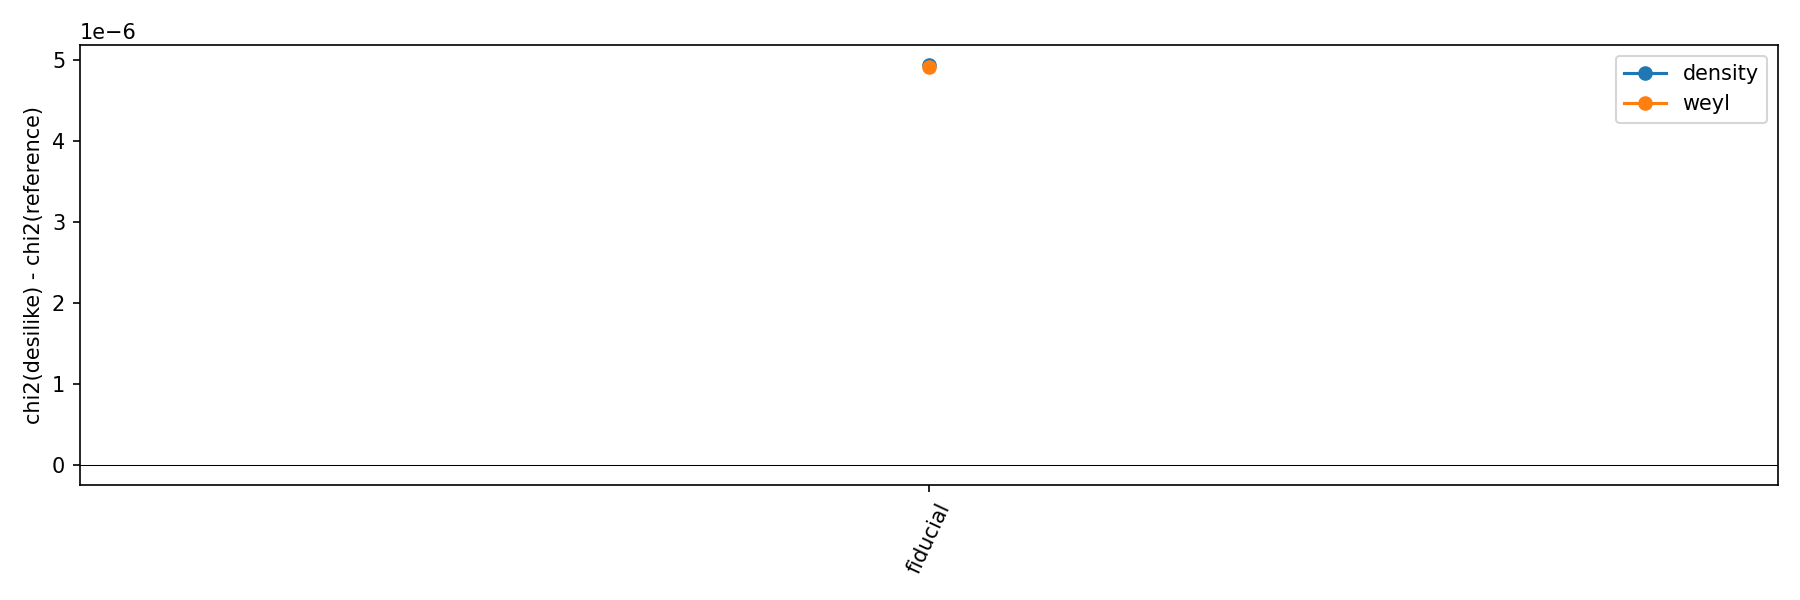

In [49]:
display(
    chi2_df[
        [
            "case",
            "mode",
            "chi2_des",
            "chi2_ref",
            "delta_chi2",
            "des_3x2",
            "ref_3x2",
            "des_sr",
            "ref_sr",
        ]
    ]
)
display(
    chi2_df[["model_delta_chi2", "precision_relative_norm", "sigma_crit_relative_norm"]]
    .max()
    .to_frame("worst")
)
assert np.isfinite(chi2_df.select_dtypes("number").to_numpy()).all()
assert chi2_df.delta_chi2.abs().max() < 1e-3
assert chi2_df.model_delta_chi2.max() < 1e-6
fig, ax = plt.subplots(figsize=(12, 4))
for mode, rows in chi2_df.groupby("mode"):
    ax.plot(rows.case, rows.delta_chi2, "o-", label=mode)
ax.axhline(0, color="k", lw=0.5)
ax.set_ylabel("chi2(desilike) - chi2(reference)")
ax.tick_params(axis="x", rotation=65)
ax.legend()
fig.tight_layout()
fig.savefig(OUT / "chi2_comparison.png", dpi=150)
plt.show()


## 8. Batch validation: 13 LCDM cosmologies

The preceding plots use the fiducial point. Repeat the calculation while varying each of the six LCDM parameters, retaining all error tables and assertions. `fiducial` still holds the fiducial result after the scan, so the plotting cells can be rerun directly.

In [50]:
power_rows, angular_rows, correlation_rows, chi2_rows, switch_rows = [], [], [], [], []
fiducial = {}
camb_template = None

start = time.monotonic()


In [51]:
for case, values in CASES:
    pair = WeylPair(make_cosmo(values))
    pipe = build(pair)
    predictions = jax.tree_util.tree_map(np.asarray, pair.result)  # build has evaluated the complete graph at the current parameters.
    if camb_template is None:
        camb_template = pair.cosmo._cosmo.engine._camb_params.copy()
    cp = camb_template.copy()
    cp.H0 = 100 * values["h"]
    cp.ombh2 = values["omega_b"]
    cp.omch2 = values["omega_cdm"]
    cp.InitPower.set_params(As=np.exp(values["logA"]) * 1e-10, ns=values["n_s"])
    cp.Reion.optical_depth = values["tau_reio"]
    cp.Transfer.kmax = 150 * values["h"]
    # YHe is a BBN-derived quantity and must follow omega_b, not remain at the template value.
    cp.YHe = camb.bbn.get_predictor().Y_He(
        values["omega_b"] * (camb.constants.COBE_CMBTemp / cp.TCMB) ** 3,
        FIXED["N_eff"] - camb.constants.default_nnu,
    )
    results = camb.get_results(cp)  # Independent calculation; do not reuse cosmoprimo CAMBdata.
    provider = CAMBProvider(results)
    kernels = pair.yes.theory.kernels
    iz = np.array([0, 1, 50, 100, 200, len(kernels.z_pk) - 1])
    redshifts = kernels.z_pk[iz]
    physical_k = np.geomspace(1e-4, 7999.0, 501)
    power_curves = {}
    for label, of, nl, camb_pair in [
        ("matter_linear", "delta_m", False, ("delta_tot", "delta_tot")),
        ("matter_nonlinear", "delta_m", True, ("delta_tot", "delta_tot")),
        ("weyl_linear", "phi_plus_psi", False, ("Weyl", "Weyl")),
        ("matter_weyl", ("delta_m", "phi_plus_psi"), False, ("delta_tot", "Weyl")),
    ]:
        table = kernels.spectrum(of, nl)[iz]
        power = (
            np.asarray(
                jnp.exp(
                    spline(jnp.log(physical_k / values["h"]), jnp.log(kernels.k), jnp.log(table).T)
                )
            ).T
            / values["h"] ** 3
        )
        if label == "weyl_linear":
            power = power * physical_k**4 / 4
        if label == "matter_weyl":
            power = -power * physical_k**2 / 2
        target = provider.pk[nl, camb_pair].P(redshifts, physical_k)
        for region, mask in [("sampled", physical_k <= 100), ("extrapolated", physical_k > 100)]:
            power_rows.append(
                dict(
                    case=case,
                    spectrum=label,
                    region=region,
                    **relative_metrics(power[:, mask], target[:, mask]),
                )
            )
        power_curves[label] = (power, target)
    references = {}
    for mode, ref in [("density", ref_no), ("weyl", ref_yes)]:
        target = evaluate_reference(ref, provider, NUISANCE)
        references[mode] = target
        aa, xx, cc = compare_predictions(case, mode, predictions[mode], ref, target)
        angular_rows.extend(aa)
        correlation_rows.extend(xx)
        chi2_rows.append(cc)
    for index, name in enumerate(TYPES):
        pairs = ref_no.bin_pairs[index]
        for space, key in [("Cl", "cl_" + name), ("xi", name)]:
            no = np.array([predictions["density"][key][i, j] for i, j in pairs])
            yes = np.array([predictions["weyl"][key][i, j] for i, j in pairs])
            if space == "Cl":
                rn = np.array(
                    [references["density"]["cls"][name][int(i), int(j)] for i, j in pairs]
                )
                ry = np.array([references["weyl"]["cls"][name][int(i), int(j)] for i, j in pairs])
            else:
                rn = np.array([references["density"]["corrs"][index][i, j] for i, j in pairs])
                ry = np.array([references["weyl"]["corrs"][index][i, j] for i, j in pairs])
            switch_rows.append(
                dict(
                    case=case,
                    space=space,
                    observable=name,
                    des_switch=relative_metrics(yes, no)["max_scaled"],
                    ref_switch=relative_metrics(ry, rn)["max_scaled"],
                    switch_residual=float(
                        np.max(np.abs((yes - no) - (ry - rn))) / np.max(np.abs(rn))
                    ),
                )
            )
    if case == "fiducial":
        fiducial = dict(
            predictions=predictions,
            references=references,
            power=power_curves,
            k=physical_k,
            z=redshifts,
        )
    for name, rows in [
        ("power", power_rows),
        ("angular", angular_rows),
        ("correlation", correlation_rows),
        ("chi2", chi2_rows),
        ("weyl_switch", switch_rows),
    ]:
        pd.DataFrame(rows).to_csv(OUT / f"{name}.csv", index=False)
    (OUT / "progress.json").write_text(
        json.dumps(
            dict(
                case=case,
                completed=len(chi2_rows) // 2,
                total=len(CASES),
                seconds=time.monotonic() - start,
            )
        )
    )
    print(case, "max |Δχ²| =", max(abs(x["delta_chi2"]) for x in chi2_rows[-2:]), flush=True)
    del pair, pipe, predictions, references, results, provider, kernels
    gc.collect()


fiducial max |Δχ²| = 4.93442917104403e-06


h_low max |Δχ²| = 3.6581402582669398e-06


h_high max |Δχ²| = 1.7149000086646993e-06


omega_b_low max |Δχ²| = 1.36523215132911e-06


omega_b_high max |Δχ²| = 7.634053076799319e-06


...

logA_high max |Δχ²| = 6.552666832249088e-06


n_s_low max |Δχ²| = 4.777841922987136e-06


n_s_high max |Δχ²| = 5.109832272864878e-06


tau_reio_low max |Δχ²| = 4.656417445403349e-06


tau_reio_high max |Δχ²| = 4.722823746305949e-06


In [52]:
power_df = pd.DataFrame(power_rows)
angular_df = pd.DataFrame(angular_rows)
correlation_df = pd.DataFrame(correlation_rows)
chi2_df = pd.DataFrame(chi2_rows)
switch_df = pd.DataFrame(switch_rows)
display(
    power_df.groupby(["spectrum", "region"])[["max_scaled", "rms_scaled", "max_relative"]].max()
)
assert power_df.finite.all()
assert power_df.max_scaled.max() < 5e-5


max_scaled    rms_scaled  max_relative
spectrum         region                                                
matter_linear    extrapolated  1.823977e-09  1.927771e-09  5.874966e-08
                 sampled       1.054593e-08  2.328875e-09  1.543219e-07
matter_nonlinear extrapolated  2.178448e-10  1.752168e-10  1.661052e-08
                 sampled       1.056425e-08  2.303380e-09  1.475719e-07
matter_weyl      extrapolated  2.273615e-09  1.982001e-09  2.445149e-08
                 sampled       2.942252e-08  3.851338e-09  1.540164e-07
weyl_linear      extrapolated  1.547826e-10  6.433669e-11  1.966037e-08
                 sampled       9.192366e-08  9.709381e-09  1.541494e-07

In [53]:
display(
    angular_df.groupby(["mode", "observable"])[["max_scaled", "rms_scaled", "max_relative"]].max()
)
assert angular_df.finite.all() and angular_df.max_scaled.max() < 1e-5


max_scaled    rms_scaled  max_relative
mode    observable                                          
density gammat      3.228561e-08  6.653249e-09  3.288793e-08
        wtheta      3.686446e-09  1.132462e-09  2.091304e-08
        xim         1.772442e-08  4.018645e-09  1.913980e-08
        xip         1.772442e-08  4.018645e-09  1.913980e-08
weyl    gammat      1.579123e-08  3.553513e-09  2.306562e-08
        wtheta      3.686446e-09  1.132462e-09  2.091304e-08
        xim         6.423846e-09  1.636302e-09  1.436996e-08
        xip         6.423846e-09  1.636302e-09  1.436996e-08

In [54]:
display(
    correlation_df.groupby(["mode", "observable"])[
        ["max_scaled", "rms_scaled", "max_relative"]
    ].max()
)
assert correlation_df.finite.all() and correlation_df.max_scaled.max() < 1e-5


max_scaled    rms_scaled  max_relative
mode    observable                                          
density gammat      6.782296e-10  6.260672e-10  6.049522e-09
        wtheta      1.155908e-09  1.294756e-09  2.480562e-06
        xim         5.377462e-10  4.807325e-10  5.478195e-09
        xip         8.775540e-10  1.091403e-09  4.570978e-09
weyl    gammat      6.455805e-10  6.198396e-10  5.904314e-09
        wtheta      1.155908e-09  1.294756e-09  2.480562e-06
        xim         5.026044e-10  4.650711e-10  5.386514e-09
        xip         8.610512e-10  1.054517e-09  4.277907e-09

In [55]:
display(
    switch_df.groupby(["space", "observable"])[
        ["des_switch", "ref_switch", "switch_residual"]
    ].max()
)
assert switch_df.switch_residual.max() < 1e-5


des_switch    ref_switch  switch_residual
space observable                                             
Cl    gammat      1.632095e-05  1.632095e-05     1.649436e-08
      wtheta      0.000000e+00  5.731818e-17     5.731818e-17
      xim         4.373518e-05  4.373518e-05     1.759564e-08
      xip         4.373518e-05  4.373518e-05     1.759564e-08
xi    gammat      2.454684e-07  2.454677e-07     1.031196e-10
      wtheta      0.000000e+00  1.061445e-16     1.061445e-16
      xim         4.827981e-07  4.827999e-07     8.790827e-11
      xip         5.227164e-07  5.227329e-07     7.315051e-11

,case,mode,chi2_des,chi2_ref,delta_chi2,des_3x2,ref_3x2,des_sr,ref_sr
0,fiducial,density,765.574133,765.574128,4.934429e-06,526.897205,526.897200,238.676928,238.676928
1,fiducial,weyl,765.574206,765.574201,4.912724e-06,526.897265,526.897260,238.676941,238.676941
2,h_low,density,735.510649,735.510653,-3.658140e-06,482.547563,482.547567,252.963086,252.963086
3,h_low,weyl,735.510838,735.510841,-3.635950e-06,482.547739,482.547743,252.963098,252.963098
4,h_high,density,833.074770,833.074768,1.714900e-06,607.046460,607.046458,226.028310,226.028310
5,h_high,weyl,833.074747,833.074745,1.685709e-06,607.046424,607.046422,226.028323,226.028323
6,omega_b_low,density,778.289426,778.289425,1.364234e-06,540.126585,540.126584,238.162841,238.162841
7,omega_b_low,weyl,778.289500,778.289498,1.365232e-06,540.126647,540.126645,238.162853,238.162853
8,omega_b_high,density,752.271004,752.270997,7.634053e-06,512.952432,512.952424,239.318572,239.318572
9,omega_b_high,weyl,752.271080,752.271073,7.630329e-06,512.952496,512.952488,239.318584,239.318584


,worst
model_delta_chi2,1.141608e-12
precision_relative_norm,1.807329e-14
sigma_crit_relative_norm,3.446221e-16


/var/folders/f6/3xg83pv93rd82_jd1m8pv17r0000gn/T/ipykernel_16263/1191706023.py:33: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


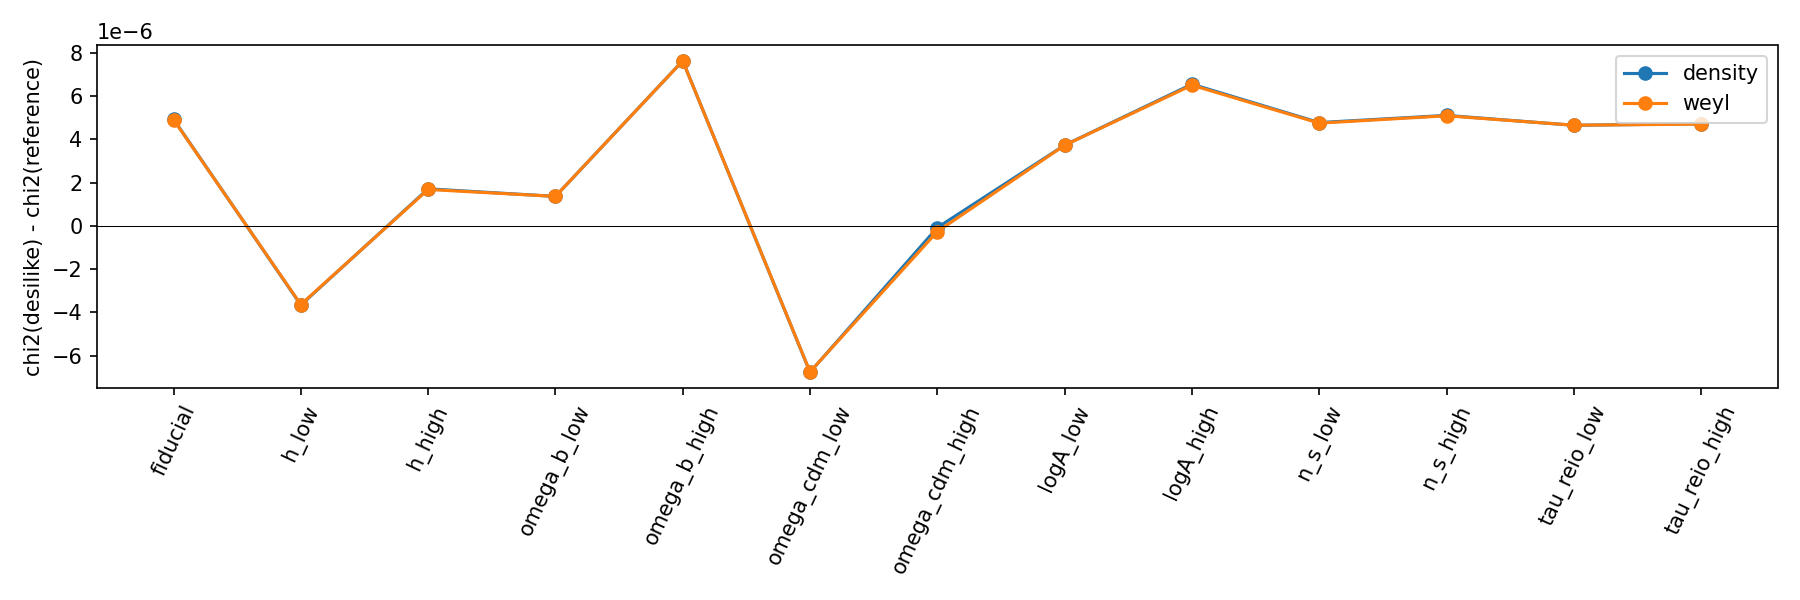

In [56]:
display(
    chi2_df[
        [
            "case",
            "mode",
            "chi2_des",
            "chi2_ref",
            "delta_chi2",
            "des_3x2",
            "ref_3x2",
            "des_sr",
            "ref_sr",
        ]
    ]
)
display(
    chi2_df[["model_delta_chi2", "precision_relative_norm", "sigma_crit_relative_norm"]]
    .max()
    .to_frame("worst")
)
assert np.isfinite(chi2_df.select_dtypes("number").to_numpy()).all()
assert chi2_df.delta_chi2.abs().max() < 1e-3
assert chi2_df.model_delta_chi2.max() < 1e-6
fig, ax = plt.subplots(figsize=(12, 4))
for mode, rows in chi2_df.groupby("mode"):
    ax.plot(rows.case, rows.delta_chi2, "o-", label=mode)
ax.axhline(0, color="k", lw=0.5)
ax.set_ylabel("chi2(desilike) - chi2(reference)")
ax.tick_params(axis="x", rotation=65)
ax.legend()
fig.tight_layout()
fig.savefig(OUT / "chi2_comparison.png", dpi=150)
plt.show()


## 9. Three execution paths: accuracy and likelihood timing

Compare **original DES (NumPy/SciPy)**, **desilike JAX eager (without JIT)**, and **desilike JAX JIT**.
Non-Limber calculations in desilike also use native JAX; there is no NumPy backend. JAX eager still uses JAX.
The original DES algorithm is retained with optional numba disabled. It is an independent reference, not a selectable desilike backend.

First compare Cℓ, correlation functions, and χ² at the fiducial point; then time calls returning only the likelihood. Section 8 already compares the complete JAX theory against independent CAMB/original DES predictions for 13 LCDM cosmologies.
Separate first-call costs from warmed-up execution. For changing-input scenarios, update parameters and wait for the result before stopping the timer. The repeated-input cache scenario is reported separately.

File loading and one-time fixed-matrix preparation retain NumPy/SciPy. Parameter-dependent weak-lensing theory and likelihood calculations use JAX; CAMB is an external solver. Clear compilation caches from the preceding checks first.

In [57]:
jax.clear_caches()
gc.collect()

15

In [58]:
validation_pair = WeylPair(make_cosmo(BASE))

validation_pipe = build(validation_pair)

validation_eager = jax.tree_util.tree_map(np.asarray, validation_pair.result)

benchmark_camb_template = validation_pair.cosmo._cosmo.engine._camb_params.copy()

BENCH_PARAMS = {**BASE, **NUISANCE}

validation_jit = jax.jit(validation_pipe)

validation_compiled = jax.tree_util.tree_map(np.asarray, validation_jit(BENCH_PARAMS))


#### Matching settings for independent CAMB

In [59]:
def benchmark_provider(values):
    cp = benchmark_camb_template.copy()
    cp.H0 = 100 * values["h"]
    cp.ombh2 = values["omega_b"]
    cp.omch2 = values["omega_cdm"]
    cp.InitPower.set_params(As=np.exp(values["logA"]) * 1e-10, ns=values["n_s"])
    cp.Reion.optical_depth = values["tau_reio"]
    cp.Transfer.kmax = 150 * values["h"]
    cp.YHe = camb.bbn.get_predictor().Y_He(
        values["omega_b"] * (camb.constants.COBE_CMBTemp / cp.TCMB) ** 3,
        FIXED["N_eff"] - camb.constants.default_nnu,
    )
    return CAMBProvider(camb.get_results(cp))


In [60]:
validation_provider = benchmark_provider(BASE)

backend_accuracy_rows = []
backend_chi2_rows = []

for mode, reference in [("density", ref_no), ("weyl", ref_yes)]:
    target = evaluate_reference(reference, validation_provider, NUISANCE)
    for backend, prediction in [
        ("JAX eager", validation_eager[mode]),
        ("JAX JIT", validation_compiled[mode]),
    ]:
        backend_chi2_rows.append(
            dict(
                mode=mode,
                backend=backend,
                chi2=float(prediction["chi2"]),
                numpy_chi2=target["chi2"],
                delta_chi2=float(prediction["chi2"]) - target["chi2"],
            )
        )
        for index, name in enumerate(TYPES):
            pairs = reference.bin_pairs[index]
            for space, key in [("Cl", "cl_" + name), ("xi", name)]:
                actual = np.array([prediction[key][i, j] for i, j in pairs])
                expected = np.array(
                    [
                        (
                            target["cls"][name][int(i), int(j)]
                            if space == "Cl"
                            else target["corrs"][index][i, j]
                        )
                        for i, j in pairs
                    ]
                )
                backend_accuracy_rows.append(
                    dict(
                        mode=mode,
                        comparison=backend + " vs NumPy",
                        space=space,
                        observable=name,
                        **relative_metrics(actual, expected)
                    )
                )
    for index, name in enumerate(TYPES):
        pairs = reference.bin_pairs[index]
        for space, key in [("Cl", "cl_" + name), ("xi", name)]:
            a = np.array([validation_compiled[mode][key][i, j] for i, j in pairs])
            b = np.array([validation_eager[mode][key][i, j] for i, j in pairs])
            backend_accuracy_rows.append(
                dict(
                    mode=mode,
                    comparison="JAX JIT vs eager",
                    space=space,
                    observable=name,
                    **relative_metrics(a, b)
                )
            )

backend_accuracy = pd.DataFrame(backend_accuracy_rows)

backend_chi2 = pd.DataFrame(backend_chi2_rows)

display(
    backend_accuracy.groupby(["comparison", "space"])[
        ["max_scaled", "rms_scaled", "max_relative"]
    ].max()
)

display(backend_chi2)

assert backend_accuracy.finite.all() and backend_accuracy.max_scaled.max() < 1e-5

assert backend_chi2.delta_chi2.abs().max() < 1e-3

backend_accuracy.to_csv(OUT / "jax_backend_accuracy.csv", index=False)

backend_chi2.to_csv(OUT / "jax_backend_chi2.csv", index=False)

del (
    validation_pair,
    validation_pipe,
    validation_jit,
    validation_compiled,
    validation_eager,
    validation_provider,
)

gc.collect()


max_scaled    rms_scaled  max_relative
comparison         space                                          
JAX JIT vs NumPy   Cl     3.223836e-08  6.560541e-09  3.270554e-08
                   xi     3.502166e-10  5.132650e-10  1.911389e-06
JAX JIT vs eager   Cl     5.040533e-15  6.671717e-15  4.657569e-14
                   xi     2.614991e-15  2.583536e-15  4.147009e-12
JAX eager vs NumPy Cl     3.223836e-08  6.560541e-09  3.270555e-08
                   xi     3.502147e-10  5.132659e-10  1.911385e-06

,mode,backend,chi2,numpy_chi2,delta_chi2
0,density,JAX eager,765.574133,765.574128,0.000005
1,density,JAX JIT,765.574133,765.574128,0.000005
2,weyl,JAX eager,765.574206,765.574201,0.000005
3,weyl,JAX JIT,765.574206,765.574201,0.000005


1363

#### Original NumPy/SciPy execution path

In [61]:
class NumpyBenchmark:
    def __init__(self, weyl):
        self.reference = make_reference(weyl)
        self.cosmo_key = None

    def __call__(self, values):
        key = tuple(values[name] for name in BASE)
        if key != self.cosmo_key:
            self.reference.provider = benchmark_provider(values)
            self.cosmo_key = key
        return self.reference.logp(**{name: values[name] for name in NUISANCE})


#### Time calls and wait for completion

In [62]:
def timed_scalar(function, values):
    start = time.perf_counter()
    result = float(function(values))  # blocks until JAX device computation is complete
    return time.perf_counter() - start, result


#### Prepare one desilike likelihood

In [63]:
def make_benchmark_loglike(weyl):
    like = BaseDESY3Likelihood(
        theory=DESWeakLensing3x2pt(cosmo=make_cosmo(BASE), Weyl=weyl), use_sr=True
    )
    pipe = build(like)
    float(like.logpdf)
    return pipe


### Configure timing scenarios and repeat counts

In [64]:
SCENARIOS = [
    ("change_shear_m1", "DES_m1", 0.002, 7),
    ("change_IA_amplitude", "DES_AIA1", 0.02, 7),
    ("change_cosmology_h", "h", 0.0005, 5),
    ("same_input_cache", None, 0.0, 7),
]
benchmark_rows = []
preparation_rows = []


### Run benchmarks: record compilation and steady execution separately

In [65]:
for mode, weyl in [("density", False), ("weyl", True)]:
    functions = {}
    start = time.perf_counter()
    native = NumpyBenchmark(weyl)
    setup = time.perf_counter() - start
    first, _ = timed_scalar(native, BENCH_PARAMS)
    preparation_rows.append(
        dict(mode=mode, backend="NumPy/SciPy", setup_s=setup, first_call_s=first)
    )
    functions["NumPy/SciPy"] = native
    for backend in ("JAX eager", "JAX JIT"):
        start = time.perf_counter()
        pipe = make_benchmark_loglike(weyl)
        setup = time.perf_counter() - start
        function = jax.jit(pipe) if backend == "JAX JIT" else pipe
        first, _ = timed_scalar(function, BENCH_PARAMS)
        preparation_rows.append(dict(mode=mode, backend=backend, setup_s=setup, first_call_s=first))
        functions[backend] = function
    for scenario, parameter, step, repetitions in SCENARIOS:
        # Identical warm-up and varying input sequence for all three backends.
        for function in functions.values():
            timed_scalar(function, BENCH_PARAMS)
        for sample in range(repetitions):
            values = BENCH_PARAMS.copy()
            if parameter is not None:
                values[parameter] += step * (sample // 2 + 1) * (1 if sample % 2 == 0 else -1)
            order = list(functions)
            order = order[sample % 3 :] + order[: sample % 3]  # rotate order to reduce timing bias
            for backend in order:
                elapsed, result = timed_scalar(functions[backend], values)
                benchmark_rows.append(
                    dict(
                        mode=mode,
                        scenario=scenario,
                        backend=backend,
                        sample=sample,
                        seconds=elapsed,
                        loglike=result,
                        h=values["h"],
                        DES_m1=values["DES_m1"],
                        DES_AIA1=values["DES_AIA1"],
                    )
                )
        print(mode, scenario, "complete", flush=True)
    del functions, native, pipe, function
    gc.collect()


density change_shear_m1 complete


density change_IA_amplitude complete


density change_cosmology_h complete


density same_input_cache complete


weyl change_shear_m1 complete


weyl change_IA_amplitude complete


weyl change_cosmology_h complete


weyl same_input_cache complete


### Summarize timings and check χ² at every timed point

In [66]:
benchmark_raw = pd.DataFrame(benchmark_rows)
benchmark_preparation = pd.DataFrame(preparation_rows)
benchmark_timing = (
    benchmark_raw.groupby(["mode", "scenario", "backend"])
    .seconds.agg(
        median_s="median",
        q25_s=lambda x: x.quantile(0.25),
        q75_s=lambda x: x.quantile(0.75),
        samples="size",
    )
    .reset_index()
)
benchmark_speed = benchmark_timing.pivot(
    index=["mode", "scenario"], columns="backend", values="median_s"
).reset_index()
benchmark_speed["NumPy_over_JIT"] = benchmark_speed["NumPy/SciPy"] / benchmark_speed["JAX JIT"]
benchmark_speed["eager_over_JIT"] = benchmark_speed["JAX eager"] / benchmark_speed["JAX JIT"]
# Check every timed output, including changing nuisance/cosmological parameters.
benchmark_values = benchmark_raw.pivot(
    index=["mode", "scenario", "sample"], columns="backend", values="loglike"
)
benchmark_values["JIT_minus_NumPy_chi2"] = -2 * (
    benchmark_values["JAX JIT"] - benchmark_values["NumPy/SciPy"]
)
benchmark_values["eager_minus_NumPy_chi2"] = -2 * (
    benchmark_values["JAX eager"] - benchmark_values["NumPy/SciPy"]
)
assert np.isfinite(benchmark_raw[["seconds", "loglike"]].to_numpy()).all()
assert benchmark_values[["JIT_minus_NumPy_chi2", "eager_minus_NumPy_chi2"]].abs().max().max() < 1e-3
benchmark_raw.to_csv(OUT / "jax_benchmark_raw.csv", index=False)
benchmark_preparation.to_csv(OUT / "jax_benchmark_preparation.csv", index=False)
benchmark_timing.to_csv(OUT / "jax_benchmark_timing.csv", index=False)
benchmark_speed.to_csv(OUT / "jax_benchmark_speedup.csv", index=False)
benchmark_values.to_csv(OUT / "jax_benchmark_accuracy.csv")
print(
    "Setup includes build-time cosmology/theory evaluation for desilike; compare setup + first call for preparation."
)
display(benchmark_preparation)
display(benchmark_timing)
print("Speedup > 1 means JIT is faster; same_input_cache is cache overhead, not new-point speed.")
display(benchmark_speed)


Setup includes build-time cosmology/theory evaluation for desilike; compare setup + first call for preparation.


,mode,backend,setup_s,first_call_s
0,density,NumPy/SciPy,0.158854,1.343705
1,density,JAX eager,3.609664,3.271802
2,density,JAX JIT,3.561464,7.045698
3,weyl,NumPy/SciPy,0.162164,1.385062
4,weyl,JAX eager,3.791214,3.220037
5,weyl,JAX JIT,3.809886,7.536192


,mode,scenario,backend,median_s,q25_s,q75_s,samples
0,density,change_IA_amplitude,JAX JIT,0.067996,0.066028,0.083179,7
1,density,change_IA_amplitude,JAX eager,0.576856,0.557643,0.583390,7
2,density,change_IA_amplitude,NumPy/SciPy,0.142476,0.141561,0.148744,7
3,density,change_cosmology_h,JAX JIT,2.461876,2.454285,2.465575,5
4,density,change_cosmology_h,JAX eager,2.955816,2.919851,2.965738,5
5,density,change_cosmology_h,NumPy/SciPy,1.322131,1.294543,1.337513,5
6,density,change_shear_m1,JAX JIT,0.091486,0.077035,0.093533,7
7,density,change_shear_m1,JAX eager,0.102490,0.101334,0.103264,7
8,density,change_shear_m1,NumPy/SciPy,0.150099,0.148701,0.150334,7
9,density,same_input_cache,JAX JIT,0.090057,0.087371,0.093118,7


Speedup > 1 means JIT is faster; same_input_cache is cache overhead, not new-point speed.


backend,mode,scenario,JAX JIT,JAX eager,NumPy/SciPy,NumPy_over_JIT,eager_over_JIT
0,density,change_IA_amplitude,0.067996,0.576856,0.142476,2.095350,8.483614
1,density,change_cosmology_h,2.461876,2.955816,1.322131,0.537042,1.200636
2,density,change_shear_m1,0.091486,0.102490,0.150099,1.640676,1.120279
3,density,same_input_cache,0.090057,0.006101,0.154225,1.712527,0.067747
4,weyl,change_IA_amplitude,0.072948,0.667323,0.181169,2.483529,9.147896
5,weyl,change_cosmology_h,2.515445,3.112414,1.363175,0.541922,1.237321
6,weyl,change_shear_m1,0.116522,0.107815,0.194620,1.670237,0.925272
7,weyl,same_input_cache,0.103408,0.009380,0.195773,1.893210,0.090707


Measured on: macOS-15.8.1-arm64-arm-64bit CPU: arm devices: [CpuDevice(id=0)]
Thread limits: {'OMP_NUM_THREADS': '4', 'OPENBLAS_NUM_THREADS': '4', 'MKL_NUM_THREADS': '4'}
Versions: {'jax': '0.6.2', 'jaxlib': '0.6.2', 'interpax': '0.3.15', 'equinox': '0.13.8', 'numpy': '1.26.4', 'scipy': '1.14.0', 'camb': '1.5.8'}


/var/folders/f6/3xg83pv93rd82_jd1m8pv17r0000gn/T/ipykernel_16263/1305879731.py:30: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


3824

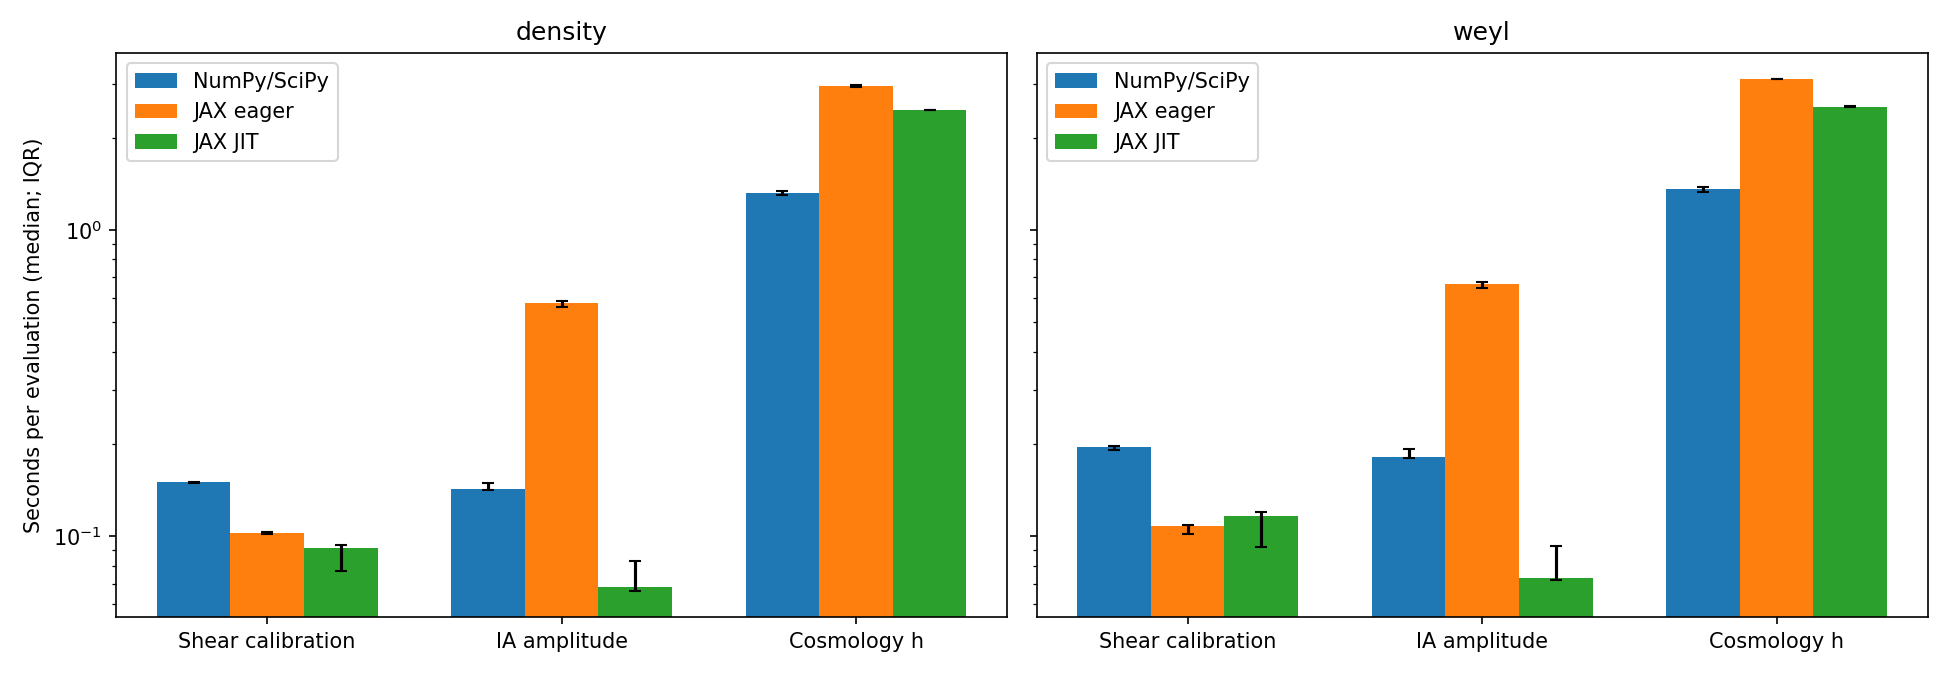

In [67]:
# Plot the three genuinely changing-input scenarios; exclude the cache-only case.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
scenario_names = [row[0] for row in SCENARIOS if row[1] is not None]
for ax, mode in zip(axes, ["density", "weyl"]):
    positions = np.arange(len(scenario_names))
    for offset, backend in zip([-0.25, 0, 0.25], ["NumPy/SciPy", "JAX eager", "JAX JIT"]):
        rows = (
            benchmark_timing[
                (benchmark_timing["mode"] == mode) & (benchmark_timing.backend == backend)
            ]
            .set_index("scenario")
            .loc[scenario_names]
        )
        ax.bar(positions + offset, rows.median_s, 0.25, label=backend)
        ax.errorbar(
            positions + offset,
            rows.median_s,
            yerr=np.stack([rows.median_s - rows.q25_s, rows.q75_s - rows.median_s]),
            fmt="none",
            ecolor="black",
            capsize=3,
        )
    ax.set_xticks(positions, ["Shear calibration", "IA amplitude", "Cosmology h"])
    ax.set_yscale("log")
    ax.set_title(mode)
    ax.legend()
axes[0].set_ylabel("Seconds per evaluation (median; IQR)")
fig.tight_layout()
fig.savefig(OUT / "jax_benchmark.png", dpi=150)
plt.show()
print("Measured on:", platform.platform(), "CPU:", platform.processor(), "devices:", jax.devices())
print(
    "Thread limits:",
    {
        name: os.environ.get(name)
        for name in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS")
    },
)
print("Versions:", VERSIONS)
benchmark_summary = dict(
    versions=VERSIONS,
    platform=platform.platform(),
    devices=[str(x) for x in jax.devices()],
    preparation=benchmark_preparation.to_dict("records"),
    speed=benchmark_speed.to_dict("records"),
    max_abs_timed_delta_chi2=float(
        benchmark_values[["JIT_minus_NumPy_chi2", "eager_minus_NumPy_chi2"]].abs().max().max()
    ),
    max_JIT_vs_eager_scaled=float(
        backend_accuracy[backend_accuracy.comparison == "JAX JIT vs eager"].max_scaled.max()
    ),
    interpretation="Warm timings exclude compilation. CAMB is cached only when cosmology is unchanged. NumPy/JIT speed includes graph caching and implementation differences; eager/JIT compares the same desilike implementation. Same-input rows measure cache overhead, not independent evaluation speed.",
)
(OUT / "jax_benchmark_summary.json").write_text(json.dumps(benchmark_summary, indent=2))


### Reading the timing tables

`NumPy_over_JIT > 1` means JIT is faster than the original implementation; `eager_over_JIT` compares the two desilike execution modes. `same_input_cache` measures repeated-input behavior, not new-point speed. The first call includes compilation and external-node preparation; it is not a cold start in a fresh process. Use the measured values below.

## 10. Total time for all observables plus the likelihood

A single call returns 20 angular points for every bin pair used in ξ₊, ξ₋, γₜ, and w, together with the log-likelihood. It includes redshift kernels, Limber/non-Limber angular power spectra, correlation transforms, point-mass marginalization, and the 3×2pt and shear-ratio likelihoods. File loading, static-matrix preparation, and first compilation are reported separately. Timing waits until every output has been transferred to NumPy.

**Fixed CAMB:** jointly change DzL1, DzS1, b1, AIA1, and m1 to recompute weak-lensing theory and non-Limber predictions. **Including CAMB:** change h and recompute CAMB, theory, and likelihood. Each path uses an independent instance and the same input sequence. After warm-up, repeat five times and rotate execution order. Measure one complete call, rather than adding separately timed theory and likelihood calls.

In [68]:
TOTAL_PAIRS = [
    sorted({(int(i), int(j)) for typ, i, j, _ in ref_no.used_items if typ == index})
    for index in range(len(TYPES))
]

TOTAL_PARAMS = {**BASE, **NUISANCE}

_total_seed = make_cosmo(BASE)

_total_seed_pipe = build(
    BaseDESY3Likelihood(theory=DESWeakLensing3x2pt(cosmo=_total_seed, Weyl=True), use_sr=True)
)

total_camb_template = _total_seed._cosmo.engine._camb_params.copy()


#### Independent CAMB provider for complete calls

In [69]:
def total_provider(values):
    cp = total_camb_template.copy()
    cp.H0 = 100 * values["h"]
    cp.ombh2 = values["omega_b"]
    cp.omch2 = values["omega_cdm"]
    cp.InitPower.set_params(As=np.exp(values["logA"]) * 1e-10, ns=values["n_s"])
    cp.Reion.optical_depth = values["tau_reio"]
    cp.Transfer.kmax = 150 * values["h"]
    cp.YHe = camb.bbn.get_predictor().Y_He(
        values["omega_b"] * (camb.constants.COBE_CMBTemp / cp.TCMB) ** 3,
        FIXED["N_eff"] - camb.constants.default_nnu,
    )
    return CAMBProvider(camb.get_results(cp))


#### NumPy: return observables and likelihood together

In [70]:
class NumpyTotal:
    def __init__(self, weyl):
        self.ref = make_reference(weyl)
        self.cosmo_key = None
        original = self.ref.get_theory

        def capture(*args, **kwargs):
            result = original(*args, **kwargs)
            self.correlations = result
            return result

        self.ref.get_theory = capture  # one ordinary wrapper, no tracing or duplicate calculation

    def __call__(self, values):
        key = tuple(values[name] for name in BASE)
        if key != self.cosmo_key:
            self.ref.provider = total_provider(values)
            self.cosmo_key = key
        loglike = self.ref.logp(**{name: values[name] for name in NUISANCE})
        return dict(
            loglike=loglike,
            observables=np.concatenate(
                [
                    self.correlations[index][i, j]
                    for index, pairs in enumerate(TOTAL_PAIRS)
                    for i, j in pairs
                ]
            ),
        )


#### JAX: return observables and likelihood together

In [71]:
def total_jax_pipe(weyl):
    like = BaseDESY3Likelihood(
        theory=DESWeakLensing3x2pt(cosmo=make_cosmo(BASE), Weyl=weyl), use_sr=True
    )

    def output():
        return dict(
            loglike=like.logpdf,
            observables=jnp.concatenate(
                [
                    getattr(like.theory, name)[i, j]
                    for name, pairs in zip(TYPES, TOTAL_PAIRS)
                    for i, j in pairs
                ]
            ),
        )

    pipe = build(like, output=output)
    jax.tree_util.tree_map(np.asarray, output())
    return pipe


#### Stop timing after every output array is ready

In [72]:
def total_timed(function, values):
    start = time.perf_counter()
    result = jax.tree_util.tree_map(
        np.asarray, function(values)
    )  # wait for ALL outputs, including transfer
    return time.perf_counter() - start, result


In [73]:
total_rows = []
total_checks = []
total_preparation = []


### Measure fixed CAMB and recomputed CAMB

In [74]:
for mode, weyl in [("density", False), ("weyl", True)]:
    runners = {}
    for backend in ("NumPy/SciPy", "JAX eager", "JAX JIT"):
        start = time.perf_counter()
        runner = NumpyTotal(weyl) if backend == "NumPy/SciPy" else total_jax_pipe(weyl)
        if backend == "JAX JIT":
            runner = jax.jit(runner)
        setup = time.perf_counter() - start
        first, _ = total_timed(runner, TOTAL_PARAMS)
        total_preparation.append(
            dict(
                mode=mode,
                backend=backend,
                setup_s=setup,
                first_call_s=first,
                preparation_total_s=setup + first,
            )
        )
        runners[backend] = runner
    for scenario in ("fixed_CAMB_full_WL", "CAMB_plus_full_WL"):
        for runner in runners.values():
            total_timed(runner, TOTAL_PARAMS)
        for sample in range(5):
            values = TOTAL_PARAMS.copy()
            offset = (sample // 2 + 1) * (1 if sample % 2 == 0 else -1)
            if scenario == "fixed_CAMB_full_WL":
                for name, step in [
                    ("DES_DzL1", 0.001),
                    ("DES_DzS1", 0.001),
                    ("DES_b1", 0.01),
                    ("DES_AIA1", 0.02),
                    ("DES_m1", 0.002),
                ]:
                    values[name] += offset * step
            else:
                values["h"] += offset * 0.0005
            order = list(runners)
            order = order[sample % 3 :] + order[: sample % 3]
            predictions = {}
            for backend in order:
                elapsed, result = total_timed(runners[backend], values)
                predictions[backend] = result
                total_rows.append(
                    dict(
                        mode=mode,
                        scenario=scenario,
                        sample=sample,
                        backend=backend,
                        seconds=elapsed,
                        loglike=float(result["loglike"]),
                        n_observable_values=result["observables"].size,
                    )
                )
            target = predictions["NumPy/SciPy"]
            for backend in ("JAX eager", "JAX JIT"):
                actual = predictions[backend]
                total_checks.append(
                    dict(
                        mode=mode,
                        scenario=scenario,
                        sample=sample,
                        backend=backend,
                        delta_chi2=-2 * float(actual["loglike"] - target["loglike"]),
                        **relative_metrics(actual["observables"], target["observables"])
                    )
                )
        print(mode, scenario, "complete", flush=True)
    # Save progress after each Weyl mode.
    pd.DataFrame(total_rows).to_csv(OUT / "jax_total_raw.csv", index=False)
    del runners, runner, predictions
    gc.collect()


density fixed_CAMB_full_WL complete


density CAMB_plus_full_WL complete


weyl fixed_CAMB_full_WL complete


weyl CAMB_plus_full_WL complete


### Total timings and numerical consistency

In [75]:
total_raw = pd.DataFrame(total_rows)
total_accuracy = pd.DataFrame(total_checks)
total_setup = pd.DataFrame(total_preparation)
total_timing = (
    total_raw.groupby(["mode", "scenario", "backend"])
    .seconds.agg(
        median_s="median",
        q25_s=lambda x: x.quantile(0.25),
        q75_s=lambda x: x.quantile(0.75),
        samples="size",
    )
    .reset_index()
)
total_speed = total_timing.pivot(
    index=["mode", "scenario"], columns="backend", values="median_s"
).reset_index()
total_speed["NumPy_over_JIT"] = total_speed["NumPy/SciPy"] / total_speed["JAX JIT"]
total_speed["eager_over_JIT"] = total_speed["JAX eager"] / total_speed["JAX JIT"]
assert total_accuracy.finite.all() and total_accuracy.max_scaled.max() < 1e-5
assert total_accuracy.delta_chi2.abs().max() < 1e-3
assert total_raw.n_observable_values.nunique() == 1
print("Returned correlation values per complete call:", total_raw.n_observable_values.iloc[0])
display(total_speed)
display(total_timing)
display(total_setup)
print("Maximum |delta chi2|:", total_accuracy.delta_chi2.abs().max())
for name, df in [
    ("timing", total_timing),
    ("speedup", total_speed),
    ("preparation", total_setup),
    ("accuracy", total_accuracy),
]:
    df.to_csv(OUT / f"jax_total_{name}.csv", index=False)
(OUT / "jax_total_summary.json").write_text(
    json.dumps(
        dict(
            versions=VERSIONS,
            speed=total_speed.to_dict("records"),
            preparation=total_setup.to_dict("records"),
            n_observable_values=int(total_raw.n_observable_values.iloc[0]),
            max_abs_delta_chi2=float(total_accuracy.delta_chi2.abs().max()),
            max_observable_scaled=float(total_accuracy.max_scaled.max()),
        ),
        indent=2,
    )
)


Returned correlation values per complete call: 640


backend,mode,scenario,JAX JIT,JAX eager,NumPy/SciPy,NumPy_over_JIT,eager_over_JIT
0,density,CAMB_plus_full_WL,2.488712,3.002874,1.327113,0.533253,1.206598
1,density,fixed_CAMB_full_WL,0.065041,0.605239,0.143351,2.204013,9.305547
2,weyl,CAMB_plus_full_WL,2.532723,3.140824,1.368516,0.540334,1.240098
3,weyl,fixed_CAMB_full_WL,0.073362,0.685139,0.185238,2.524988,9.339177


,mode,scenario,backend,median_s,q25_s,q75_s,samples
0,density,CAMB_plus_full_WL,JAX JIT,2.488712,2.488554,2.493117,5
1,density,CAMB_plus_full_WL,JAX eager,3.002874,2.975956,3.003329,5
2,density,CAMB_plus_full_WL,NumPy/SciPy,1.327113,1.302696,1.331837,5
3,density,fixed_CAMB_full_WL,JAX JIT,0.065041,0.063745,0.066252,5
4,density,fixed_CAMB_full_WL,JAX eager,0.605239,0.583146,0.608633,5
5,density,fixed_CAMB_full_WL,NumPy/SciPy,0.143351,0.143311,0.148214,5
6,weyl,CAMB_plus_full_WL,JAX JIT,2.532723,2.532708,2.562839,5
7,weyl,CAMB_plus_full_WL,JAX eager,3.140824,3.135065,3.144052,5
8,weyl,CAMB_plus_full_WL,NumPy/SciPy,1.368516,1.332530,1.370235,5
9,weyl,fixed_CAMB_full_WL,JAX JIT,0.073362,0.073110,0.073936,5


,mode,backend,setup_s,first_call_s,preparation_total_s
0,density,NumPy/SciPy,0.165229,1.470482,1.635711
1,density,JAX eager,3.883338,3.014180,6.897518
2,density,JAX JIT,3.664022,7.195970,10.859993
3,weyl,NumPy/SciPy,0.159250,1.510962,1.670212
4,weyl,JAX eager,4.014310,3.165161,7.179471
5,weyl,JAX JIT,3.957479,7.593216,11.550695


Maximum |delta chi2|: 8.713474471733207e-06


2617

### Interpreting the two total-time scenarios

- **Fixed CAMB:** keep cosmology unchanged; update several nuisance parameters and recompute weak-lensing theory, non-Limber predictions, and likelihood.
- **Recomputed CAMB:** update h and evaluate everything from CAMB to observables and likelihood. This better represents the cost of a new cosmological sampling point.

The default complete call returns 640 correlation-function values and the log-likelihood. Use the freshly computed timing tables; no old timings are hard-coded into the prose. CSV files, figures, and JSON summaries are saved to `OUT`.